In [94]:
from google.colab import files

# This will prompt you to select a file from your computer
uploaded = files.upload()

Saving shopping_users.csv to shopping_users (1).csv


In [ ]:
from google.colab import files

# This will prompt you to select a file from your computer
uploaded = files.upload()

Saving shopping_products.csv to shopping_products.csv
Saving shopping_users.csv to shopping_users.csv


# 🛒 Shopping Purchase Prediction AI — Google Colab

## 1. PROJECT OBJECTIVE

Build a machine-learning system that learns individual users' shopping behavior and predicts their **next shopping action**.

The model should answer:

> **What is this user likely to purchase next, from which shopping app, which category/brand/product, for approximately how much, and after how many days?**

Example:

```text
User ID: USER_02341

Historical behavior:
Amazon → Electronics → Wireless Earbuds
Amazon → Electronics → USB Cable
Flipkart → Electronics → Keyboard
Amazon → Electronics → Wireless Earbuds

Prediction:

Next App              → Amazon
Next Category         → Electronics
Next Product          → Wireless Earbuds
Next Brand            → TechNova
Expected Amount       → ₹2,499
Expected Time         → 8 days
```

This is **not a conventional product recommendation system**.

The primary objective is **personalized behavioral forecasting**.

---

# 2. DATASET

The synthetic dataset contains:

```text
Users:       6,000
Products:    3,000
Events:      60,000+
Purchases:   8,000+
Apps:        10
```

All data is synthetic.

The dataset contains:

```text
search
view
wishlist
add_to_cart
purchase
cancel
return
```

events.

---

# 3. DATA FILES

The notebook will use:

```text
shopping_events.csv
shopping_users.csv
shopping_products.csv
```

### shopping_events.csv

Important columns:

```text
event_id
user_id
timestamp
app
action
product_id
product_name
category
subcategory
brand
price
quantity
discount
final_amount
device
day_of_week
hour
is_weekend
days_since_previous_event
days_since_previous_purchase
```

### shopping_users.csv

Contains:

```text
user_id
persona
age_group
income_level
preferred_app
preferred_category
preferred_brand
price_sensitivity
```

### shopping_products.csv

Contains:

```text
product_id
product_name
category
subcategory
brand
base_price
```

---

# 4. MACHINE LEARNING PROBLEM

Convert the event history into supervised learning samples.

For each user, use their **past behavior** to predict their **next purchase**.

Conceptually:

```text
PAST
─────────────────────────────────

User
 ↓
Search history
 ↓
Viewed products
 ↓
Cart history
 ↓
Purchase history
 ↓
App preference
 ↓
Category preference
 ↓
Brand preference
 ↓
Spending behavior
 ↓
Time patterns

─────────────────────────────────
             ↓
          ML MODEL
             ↓
─────────────────────────────────

FUTURE

Next App
Next Product
Next Category
Next Brand
Purchase Amount
Days Until Purchase
```

---

# 5. IMPORTANT — PREVENT DATA LEAKAGE

This is critical.

At prediction time `T`, the model must only see information available **before T**.

For example:

```text
Prediction timestamp:
2026-05-01
```

The model may use:

```text
events before 2026-05-01
purchases before 2026-05-01
spending before 2026-05-01
app preferences before 2026-05-01
category preferences before 2026-05-01
```

It must NOT use:

```text
future purchase
future product
future amount
future app
future category
future timestamp
```

The future purchase becomes the **target/label**.

---

# 6. CREATE SUPERVISED LEARNING DATA

Generate:

```text
shopping_features.csv
```

Each row represents one prediction point.

Input features should include:

### User features

```text
user_id
persona
age_group
income_level
price_sensitivity
```

### Behavioral features

```text
purchases_history
purchases_last_30_days
purchases_last_90_days
days_since_last_purchase
average_purchase_interval
median_purchase_interval
average_spend
median_spend
total_spend_30_days
total_spend_90_days
```

### Preference features

```text
preferred_app_history
preferred_category_history
preferred_brand_history
app_purchase_frequency
category_purchase_frequency
brand_purchase_frequency
discount_purcha_
```


In [ ]:
import pandas as pd
pd.options.display.float_format = '{:,.2f}'.format
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from IPython.display import Image
import warnings
warnings.filterwarnings("ignore")

colors = ["#89CFF0", "#FF69B4", "#FFD700", "#7B68EE", "#FF4500",
          "#9370DB", "#32CD32", "#8A2BE2", "#FF6347", "#20B2AA",
          "#FF69B4", "#00CED1", "#FF7F50", "#7FFF00", "#DA70D6"]

In [ ]:
df = pd.read_csv("shopping_events.csv")
df.head(30)

,event_id,user_id,timestamp,app,action,product_id,product_name,category,subcategory,brand,price,quantity,discount,final_amount,device,day_of_week,hour,is_weekend,days_since_previous_event,days_since_previous_purchase
0,EVT_0001692,USER_00001,2025-04-03 18:22:00,Nykaa,view,PROD_00894,Pro Bracelet,Jewelry,Rings,GlowPure,"1,380.15",1,0.15,"1,173.13",Android,Thursday,18,False,-1.00,-1.00
1,EVT_0044807,USER_00001,2025-05-17 09:17:00,Nykaa,view,PROD_01896,Ultra Exam Guide,Books,Comics,RoadPro,"1,877.79",1,0.05,"1,783.90",iOS,Saturday,9,True,43.62,-1.00
2,EVT_0056296,USER_00001,2025-08-10 17:48:00,Nykaa,wishlist,PROD_01818,Smart Moisturizer,Beauty,Fragrance,RoadPro,"2,305.94",1,0.40,"1,383.56",Web,Sunday,17,True,85.35,-1.00
3,EVT_0049235,USER_00001,2025-09-08 15:33:00,Flipkart,view,PROD_01905,Pro Puzzle Set,Toys,Educational,StyleNest,802.09,1,0.05,761.99,Android,Monday,15,False,28.91,-1.00
4,EVT_0012247,USER_00001,2025-09-15 18:03:00,Nykaa,purchase,PROD_01568,Premium Mixer Grinder,Home & Kitchen,Kitchen,RoadPro,618.96,1,0.30,433.27,Android,Monday,18,False,7.10,-1.00
5,EVT_0053678,USER_00001,2025-10-13 16:40:00,Nykaa,view,PROD_02145,Premium Storage Container,Home & Kitchen,Kitchen,RoadPro,"1,565.32",1,0.15,"1,330.52",Android,Monday,16,False,27.94,27.94
6,EVT_0038446,USER_00001,2025-11-19 19:27:00,Flipkart,purchase,PROD_00677,Ultra Board Game,Toys,Board Games,RoadPro,"1,395.01",1,0.00,"1,395.01",Android,Wednesday,19,False,37.12,65.06
7,EVT_0050266,USER_00001,2026-02-09 20:52:00,Nykaa,search,PROD_02718,Ultra Board Game,Toys,Board Games,SmartNest,"3,951.15",1,0.00,"3,951.15",Web,Monday,20,False,82.06,82.06
8,EVT_0031998,USER_00001,2026-02-11 12:53:00,Nykaa,search,PROD_00917,Ultra Puzzle Set,Toys,Puzzles,Luma,188.65,1,0.05,179.22,Tablet,Wednesday,12,False,1.67,83.73
9,EVT_0059803,USER_00001,2026-02-15 09:06:00,Nykaa,wishlist,PROD_00795,Premium Remote Car,Toys,Dolls,RoadPro,"2,025.10",1,0.10,"1,822.59",Android,Sunday,9,True,3.84,87.57


In [ ]:
df1 = pd.read_csv("shopping_products.csv")
df2 = pd.read_csv("shopping_users.csv")

df1.head(30)

,product_id,product_name,category,subcategory,brand,base_price
0,PROD_00001,Pro Casual Shirt,Fashion,Bags,RoadPro,"1,461.38"
1,PROD_00002,Pro Coffee Pack,Grocery,Snacks,SmartNest,"2,672.44"
2,PROD_00003,Essential Storage Container,Home & Kitchen,Storage,DailyMart,"1,354.43"
3,PROD_00004,Ultra Yoga Mat,Sports,Fitness,NextGear,"1,473.61"
4,PROD_00005,Smart Car Phone Holder,Automotive,Bike Accessories,GlowPure,502.13
5,PROD_00006,Smart Running Shoes,Fashion,Men Clothing,GameForge,"2,071.74"
6,PROD_00007,Essential Exam Guide,Books,Non-Fiction,Luma,924.53
7,PROD_00008,Ultra Cotton T-Shirt,Fashion,Bags,PureLiving,250.00
8,PROD_00009,Classic Exam Guide,Books,Comics,TechNova,"2,308.88"
9,PROD_00010,Premium Bedsheet,Home & Kitchen,Storage,GameForge,"3,040.22"


In [ ]:
df2.head()

,user_id,persona,age_group,income_level,preferred_app,preferred_category,preferred_brand,price_sensitivity
0,USER_00001,premium_shopper,25-34,lower_middle,Nykaa,Toys,RoadPro,low
1,USER_00002,frequent_online_shopper,25-34,upper_middle,Meesho,Jewelry,PureLiving,medium
2,USER_00003,gamer,18-24,high,Amazon,Toys,UrbanEdge,medium
3,USER_00004,home_shopper,55+,lower_middle,Flipkart,Sports,StyleNest,medium
4,USER_00005,home_shopper,18-24,upper_middle,Nykaa,Books,TechNova,medium


In [ ]:
df.shape

(60000, 20)

In [ ]:
df.columns

Index(['event_id', 'user_id', 'timestamp', 'app', 'action', 'product_id',
       'product_name', 'category', 'subcategory', 'brand', 'price', 'quantity',
       'discount', 'final_amount', 'device', 'day_of_week', 'hour',
       'is_weekend', 'days_since_previous_event',
       'days_since_previous_purchase'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   event_id                      60000 non-null  object 
 1   user_id                       60000 non-null  object 
 2   timestamp                     60000 non-null  object 
 3   app                           60000 non-null  object 
 4   action                        60000 non-null  object 
 5   product_id                    60000 non-null  object 
 6   product_name                  60000 non-null  object 
 7   category                      60000 non-null  object 
 8   subcategory                   60000 non-null  object 
 9   brand                         60000 non-null  object 
 10  price                         60000 non-null  float64
 11  quantity                      60000 non-null  int64  
 12  discount                      60000 non-null  float64
 13  f

In [ ]:
df.describe()

,price,quantity,discount,final_amount,hour,days_since_previous_event,days_since_previous_purchase
count,"60,000.00","60,000.00","60,000.00","60,000.00","60,000.00","60,000.00","60,000.00"
mean,"1,628.64",1.12,0.10,"1,641.72",15.48,48.43,49.03
std,"1,818.05",0.51,0.12,"2,176.13",5.08,52.87,162.82
min,70.84,1.00,0.00,45.36,0.00,-1.00,-604.91
25%,581.15,1.00,0.00,533.45,11.00,9.97,-1.00
50%,"1,083.84",1.00,0.05,"1,018.99",17.00,32.01,-1.00
75%,"2,044.96",1.00,0.15,"1,968.09",19.00,69.70,112.93
max,"33,126.39",4.00,0.50,"119,845.48",23.00,555.05,605.50


In [ ]:
df.isnull().sum()

,0
event_id,0
user_id,0
timestamp,0
app,0
action,0
product_id,0
product_name,0
category,0
subcategory,0
brand,0


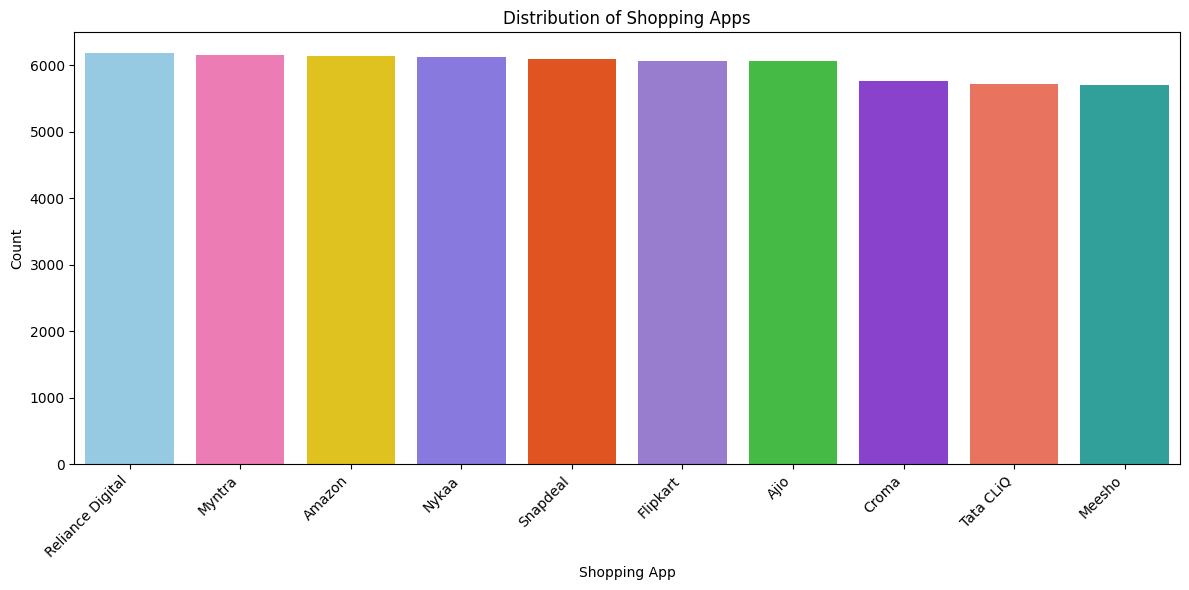

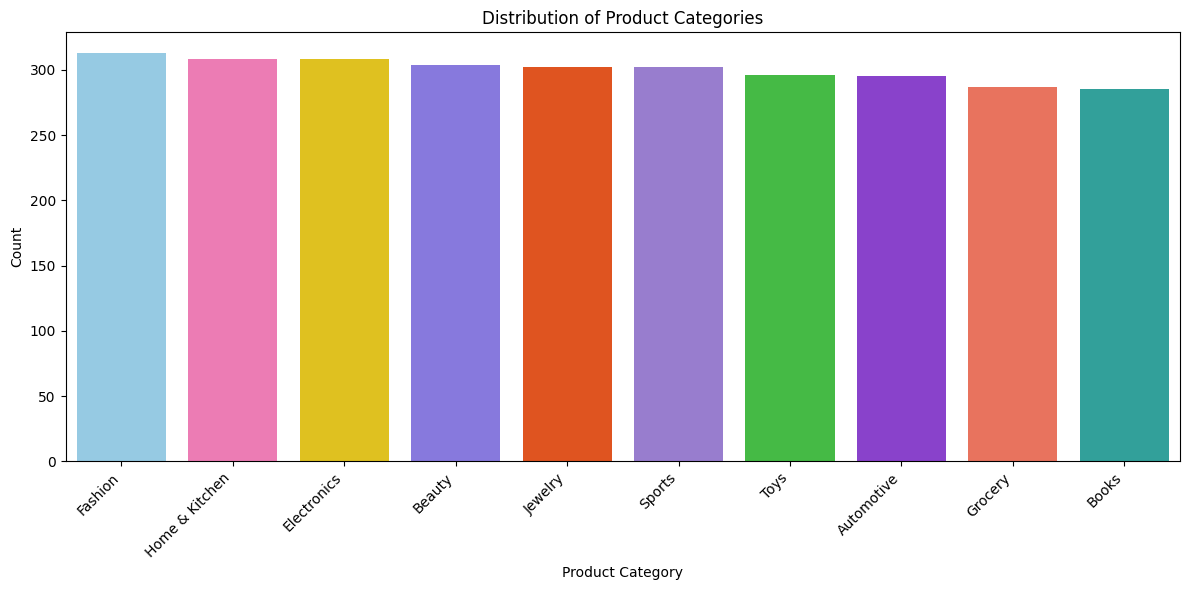

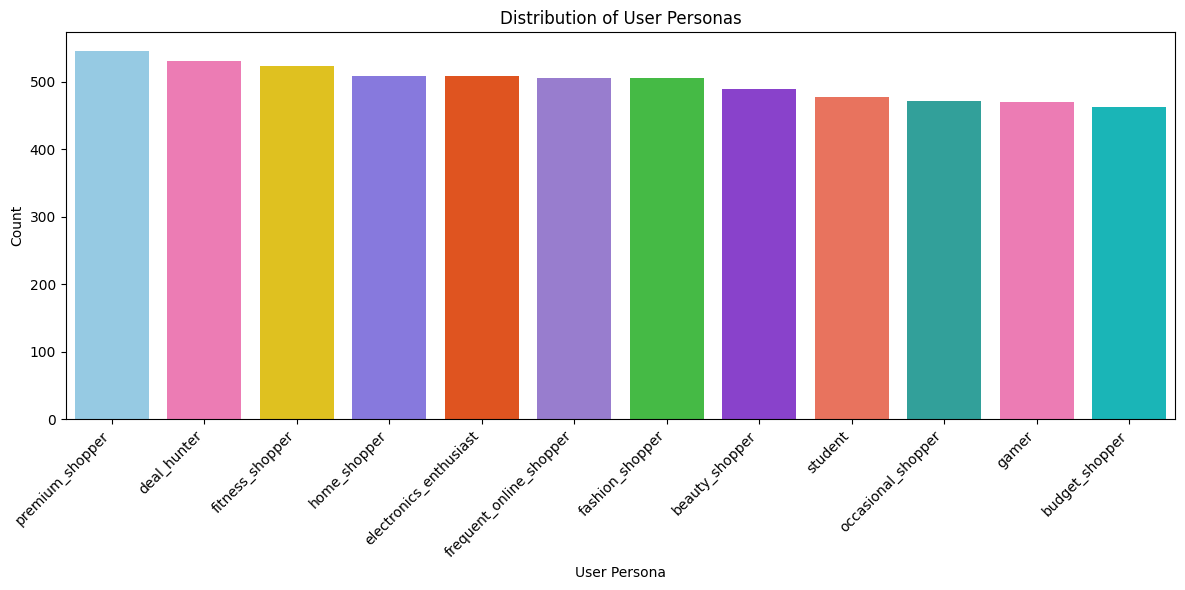

In [ ]:
def create_bar_chart(data, column, title, xlabel, ylabel):
    plt.figure(figsize=(12, 6))
    sns.countplot(data=data, x=column, palette=colors, order=data[column].value_counts().index)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Bar chart for df (shopping_events.csv) - 'app' column
create_bar_chart(df, 'app', 'Distribution of Shopping Apps', 'Shopping App', 'Count')

# Bar chart for df1 (shopping_products.csv) - 'category' column
create_bar_chart(df1, 'category', 'Distribution of Product Categories', 'Product Category', 'Count')

# Bar chart for df2 (shopping_users.csv) - 'persona' column
create_bar_chart(df2, 'persona', 'Distribution of User Personas', 'User Persona', 'Count')

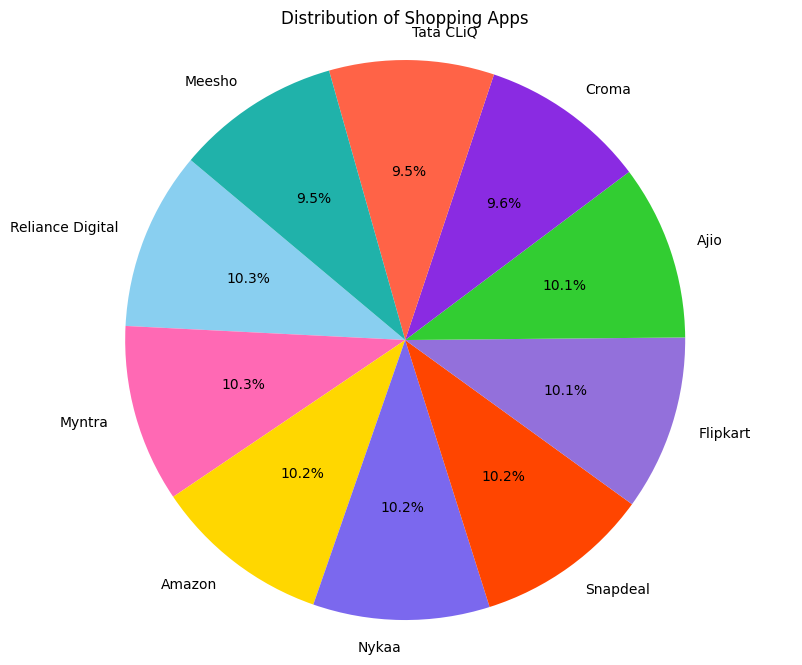

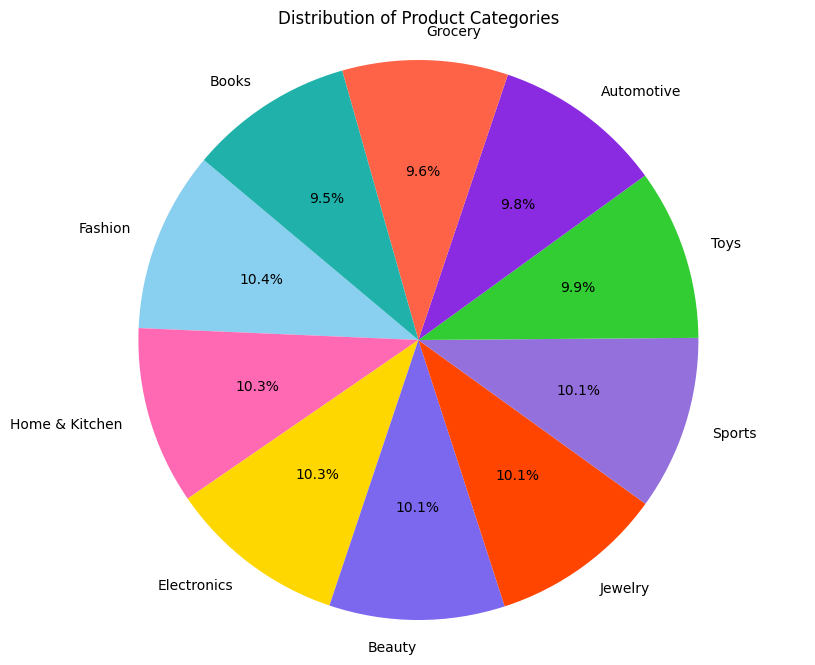

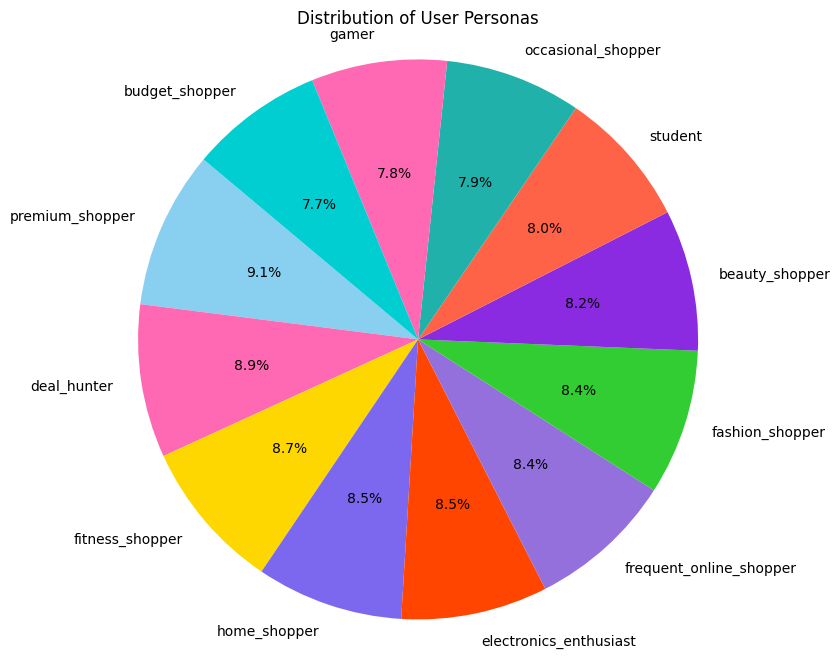

In [ ]:
def create_pie_chart(data, column, title):
    plt.figure(figsize=(10, 8))
    counts = data[column].value_counts()
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, colors=colors)
    plt.title(title)
    plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.show()

# Pie chart for df (shopping_events.csv) - 'app' column
create_pie_chart(df, 'app', 'Distribution of Shopping Apps')

# Pie chart for df1 (shopping_products.csv) - 'category' column
create_pie_chart(df1, 'category', 'Distribution of Product Categories')

# Pie chart for df2 (shopping_users.csv) - 'persona' column
create_pie_chart(df2, 'persona', 'Distribution of User Personas')

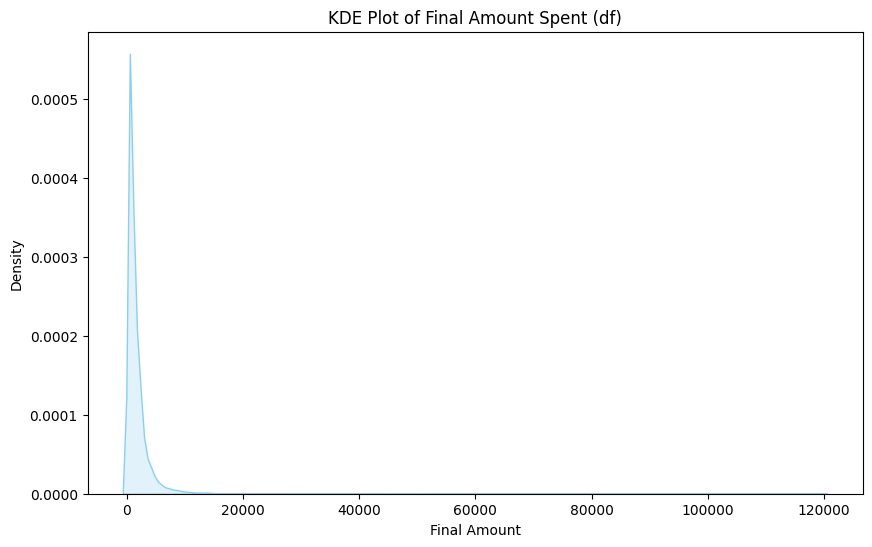

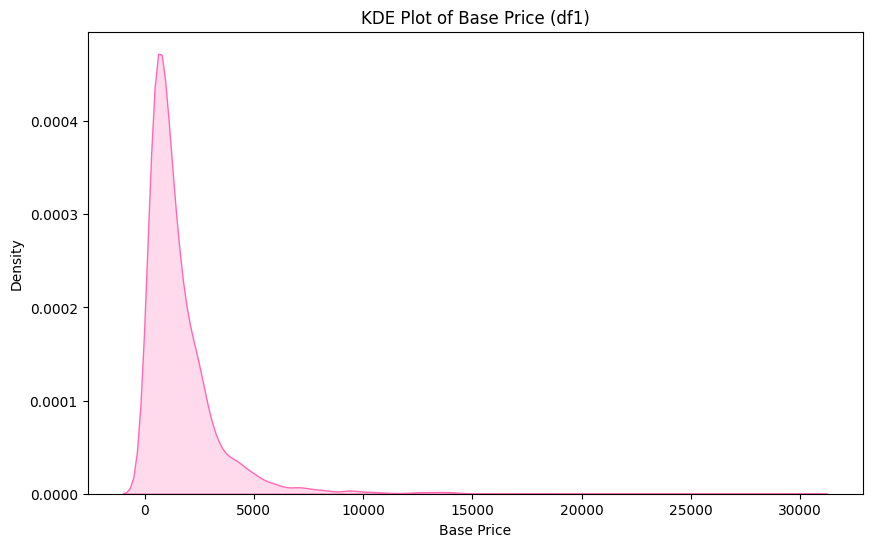

In [ ]:
# KDE plot for df (shopping_events.csv) - 'final_amount' column
plt.figure(figsize=(10, 6))
sns.kdeplot(df['final_amount'], fill=True, color=colors[0])
plt.title('KDE Plot of Final Amount Spent (df)')
plt.xlabel('Final Amount')
plt.ylabel('Density')
plt.show()

# KDE plot for df1 (shopping_products.csv) - 'base_price' column
plt.figure(figsize=(10, 6))
sns.kdeplot(df1['base_price'], fill=True, color=colors[1])
plt.title('KDE Plot of Base Price (df1)')
plt.xlabel('Base Price')
plt.ylabel('Density')
plt.show()



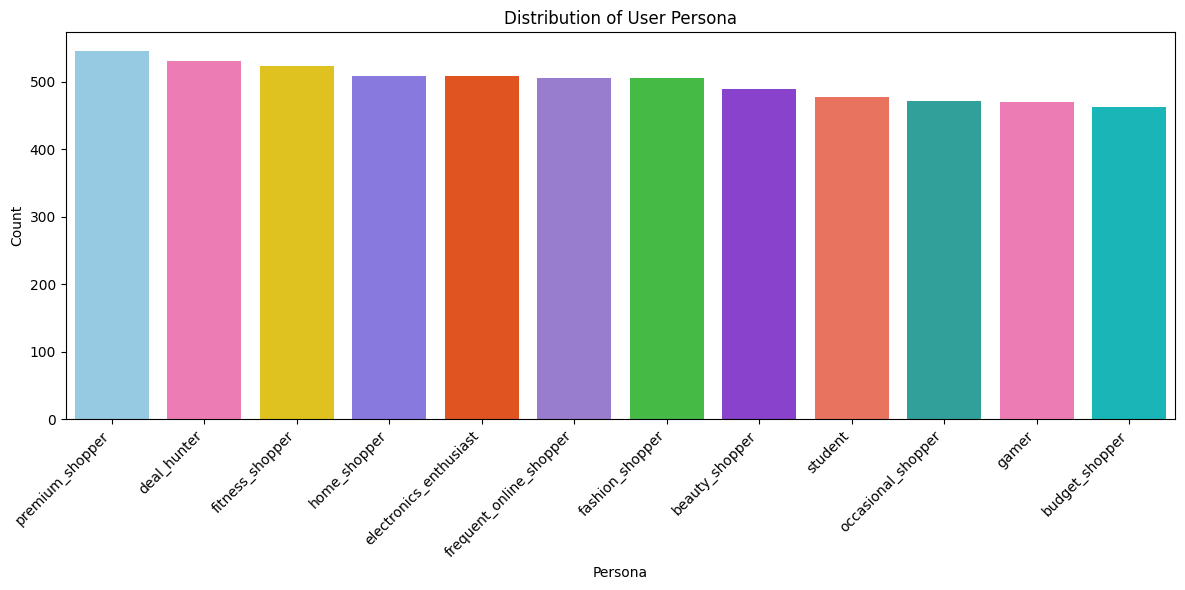

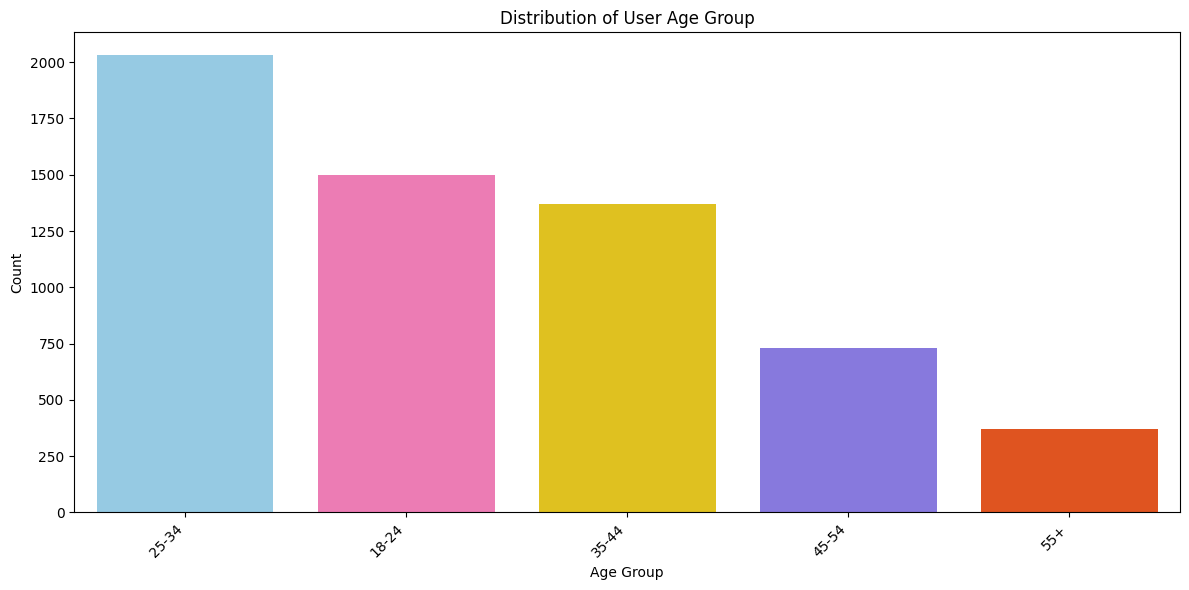

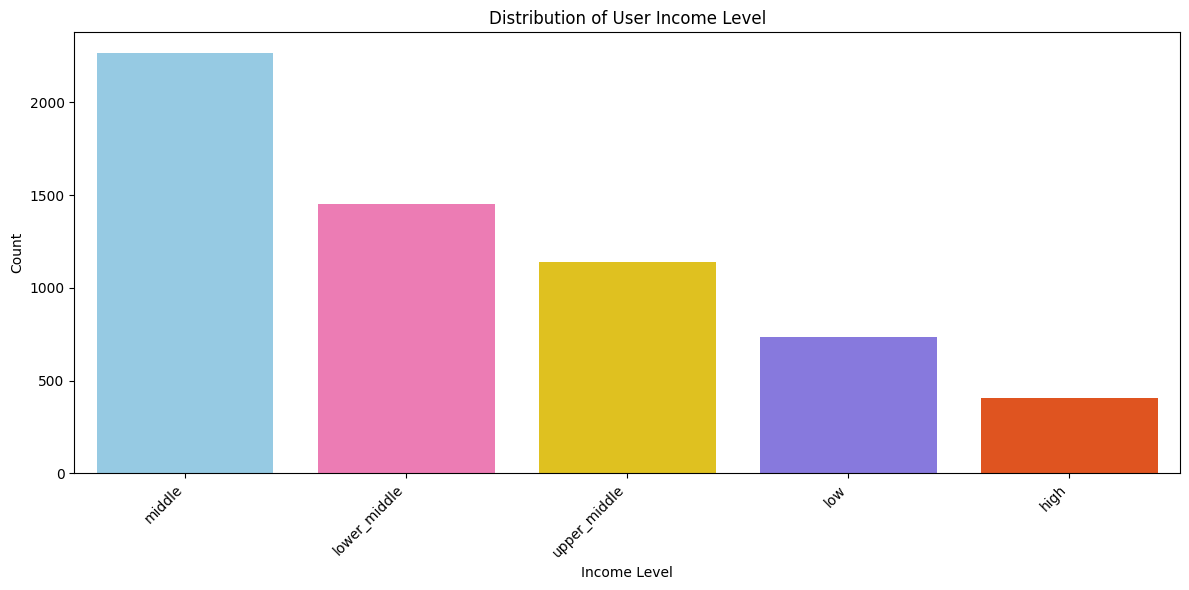

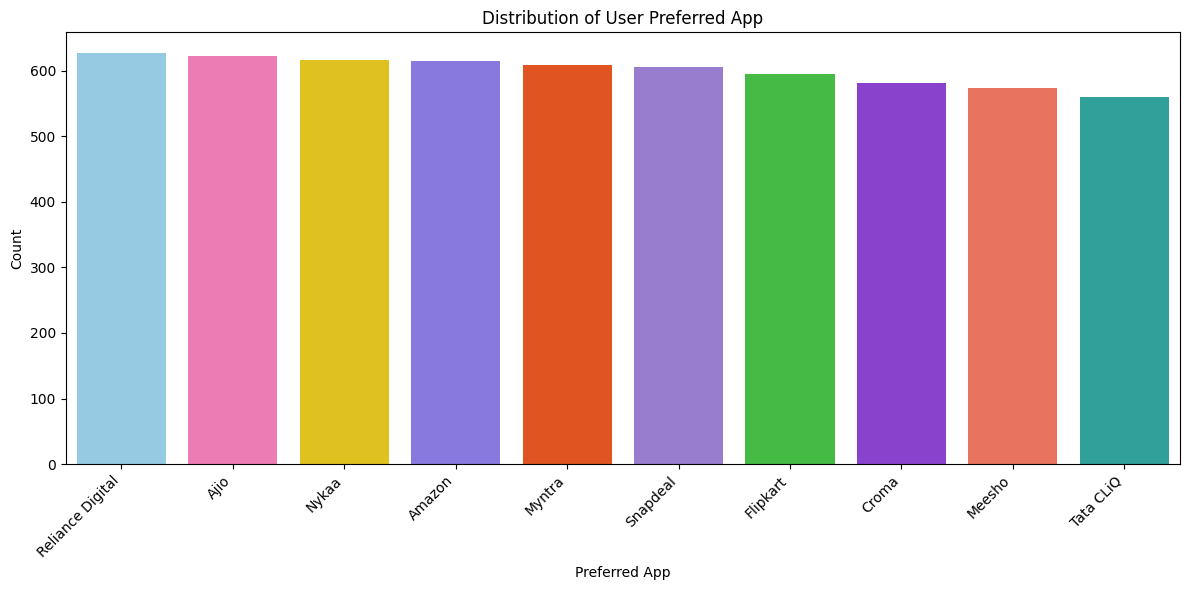

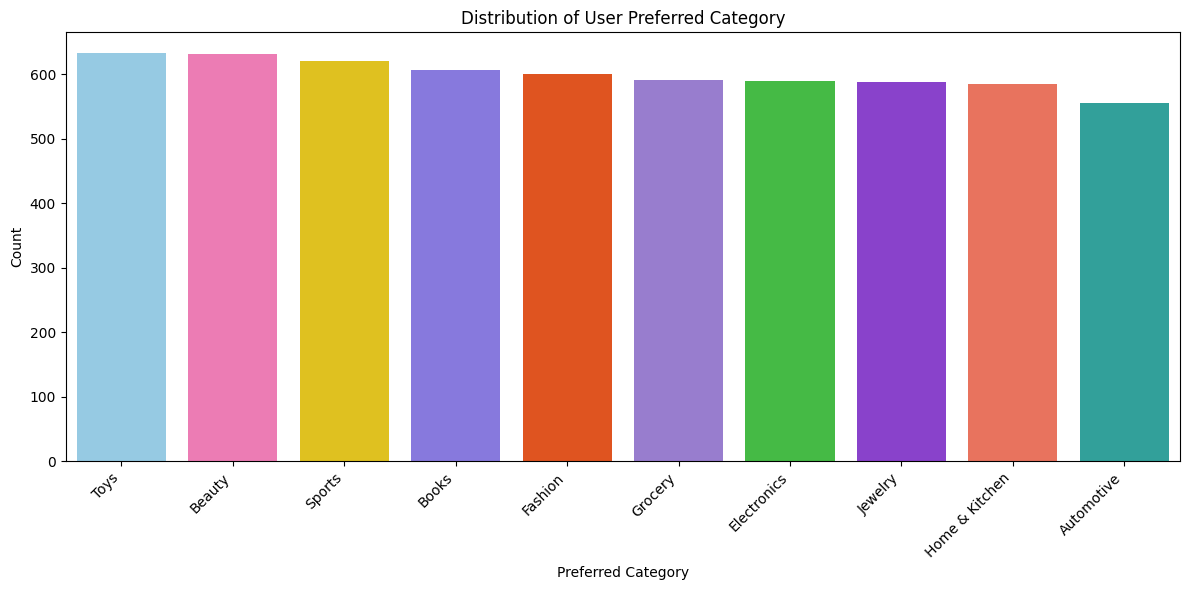

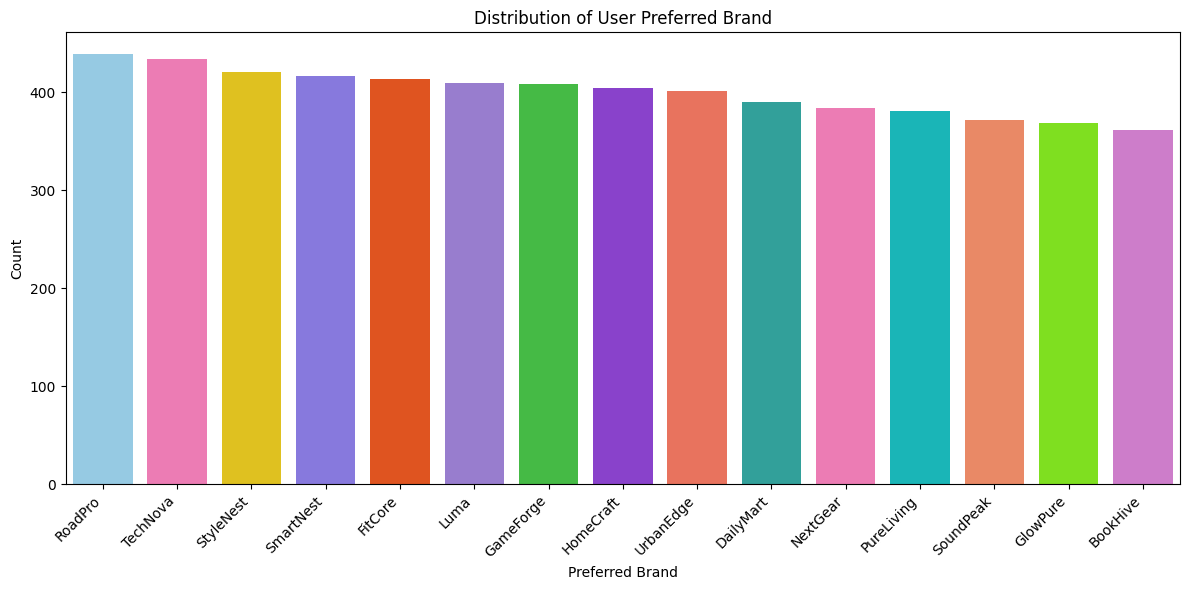

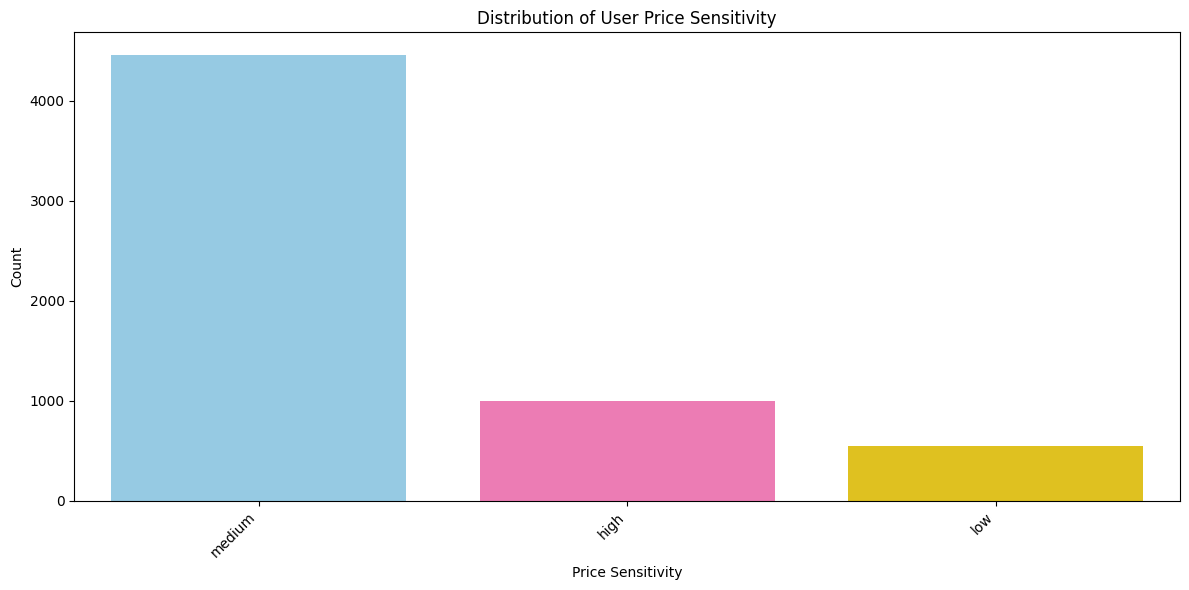


DataFrame df2 after One-Hot Encoding:


,user_id,persona_beauty_shopper,persona_budget_shopper,persona_deal_hunter,persona_electronics_enthusiast,persona_fashion_shopper,persona_fitness_shopper,persona_frequent_online_shopper,persona_gamer,persona_home_shopper,...,preferred_brand_PureLiving,preferred_brand_RoadPro,preferred_brand_SmartNest,preferred_brand_SoundPeak,preferred_brand_StyleNest,preferred_brand_TechNova,preferred_brand_UrbanEdge,price_sensitivity_high,price_sensitivity_low,price_sensitivity_medium
0,USER_00001,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,True,False
1,USER_00002,False,False,False,False,False,False,True,False,False,...,True,False,False,False,False,False,False,False,False,True
2,USER_00003,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,USER_00004,False,False,False,False,False,False,False,False,True,...,False,False,False,False,True,False,False,False,False,True
4,USER_00005,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,True,False,False,False,True


Shape of df2 after encoding: (6000, 61)


In [ ]:
# Bar charts for all categorical columns in df2
for column in ['persona', 'age_group', 'income_level', 'preferred_app', 'preferred_category', 'preferred_brand', 'price_sensitivity']:
    create_bar_chart(df2, column, f'Distribution of User {column.replace("_", " ").title()}', column.replace("_", " ").title(), 'Count')


# Feature Engineering for df2: One-Hot Encoding

# Identify categorical columns in df2 (excluding 'user_id')
categorical_cols = ['persona', 'age_group', 'income_level', 'preferred_app', 'preferred_category', 'preferred_brand', 'price_sensitivity']

# Apply one-hot encoding
df2_encoded = pd.get_dummies(df2, columns=categorical_cols, drop_first=False)

# Display the first few rows of the engineered DataFrame
print("\nDataFrame df2 after One-Hot Encoding:")
display(df2_encoded.head())
print(f"Shape of df2 after encoding: {df2_encoded.shape}")

In [ ]:
# ============================================================
# 2. LOAD DATA
# ============================================================

events = df
users = df1
products = df2

print("Events shape   :", events.shape)
print("Users shape    :", users.shape)
print("Products shape :", products.shape)

display(events.head())

Events shape   : (60000, 20)
Users shape    : (3000, 6)
Products shape : (6000, 8)


,event_id,user_id,timestamp,app,action,product_id,product_name,category,subcategory,brand,price,quantity,discount,final_amount,device,day_of_week,hour,is_weekend,days_since_previous_event,days_since_previous_purchase
0,EVT_0001692,USER_00001,2025-04-03 18:22:00,Nykaa,view,PROD_00894,Pro Bracelet,Jewelry,Rings,GlowPure,"1,380.15",1,0.15,"1,173.13",Android,Thursday,18,False,-1.00,-1.00
1,EVT_0044807,USER_00001,2025-05-17 09:17:00,Nykaa,view,PROD_01896,Ultra Exam Guide,Books,Comics,RoadPro,"1,877.79",1,0.05,"1,783.90",iOS,Saturday,9,True,43.62,-1.00
2,EVT_0056296,USER_00001,2025-08-10 17:48:00,Nykaa,wishlist,PROD_01818,Smart Moisturizer,Beauty,Fragrance,RoadPro,"2,305.94",1,0.40,"1,383.56",Web,Sunday,17,True,85.35,-1.00
3,EVT_0049235,USER_00001,2025-09-08 15:33:00,Flipkart,view,PROD_01905,Pro Puzzle Set,Toys,Educational,StyleNest,802.09,1,0.05,761.99,Android,Monday,15,False,28.91,-1.00
4,EVT_0012247,USER_00001,2025-09-15 18:03:00,Nykaa,purchase,PROD_01568,Premium Mixer Grinder,Home & Kitchen,Kitchen,RoadPro,618.96,1,0.30,433.27,Android,Monday,18,False,7.10,-1.00


In [ ]:
# ============================================================
# 3. BASIC CLEANING
# ============================================================

# Convert timestamps
events["timestamp"] = pd.to_datetime(
    events["timestamp"],
    errors="coerce"
)

# Remove invalid timestamps
events = events.dropna(subset=["timestamp"])

# Sort chronologically
events = events.sort_values(
    ["user_id", "timestamp"]
).reset_index(drop=True)

# Remove exact duplicate events
events = events.drop_duplicates(
    subset=["event_id"]
).reset_index(drop=True)

print("Cleaned events:", events.shape)

print("\nMissing values:")
display(events.isnull().sum())

Cleaned events: (60000, 20)

Missing values:


,0
event_id,0
user_id,0
timestamp,0
app,0
action,0
product_id,0
product_name,0
category,0
subcategory,0
brand,0


In [ ]:
# ============================================================
# 5. NORMALIZE COLUMN NAMES
# ============================================================

# Some datasets may use different names.
# This block makes the feature engineering more robust.

rename_map = {}

if "price" not in events.columns and "base_price" in events.columns:
    rename_map["base_price"] = "price"

if "amount" not in events.columns and "purchase_amount" in events.columns:
    rename_map["purchase_amount"] = "amount"

events = events.rename(columns=rename_map)

print(events.columns.tolist())

['event_id', 'user_id', 'timestamp', 'app', 'action', 'product_id', 'product_name', 'category', 'subcategory', 'brand', 'price', 'quantity', 'discount', 'final_amount', 'device', 'day_of_week', 'hour', 'is_weekend', 'days_since_previous_event', 'days_since_previous_purchase']


In [ ]:
# ============================================================
# 6. TEMPORAL FEATURES
# ============================================================

events["year"] = events["timestamp"].dt.year
events["month"] = events["timestamp"].dt.month
events["day"] = events["timestamp"].dt.day
events["day_of_week"] = events["timestamp"].dt.dayofweek
events["hour"] = events["timestamp"].dt.hour
events["week_of_year"] = events["timestamp"].dt.isocalendar().week.astype(int)
events["quarter"] = events["timestamp"].dt.quarter

# Weekend indicator
events["is_weekend"] = (
    events["day_of_week"] >= 5
).astype(int)

# Working / non-working hour indicator
events["is_night"] = (
    (events["hour"] < 7) |
    (events["hour"] >= 22)
).astype(int)

# Shopping session periods
def get_time_period(hour):

    if 5 <= hour < 12:
        return "morning"

    elif 12 <= hour < 17:
        return "afternoon"

    elif 17 <= hour < 22:
        return "evening"

    else:
        return "night"


events["time_period"] = events["hour"].apply(get_time_period)

print("Temporal features created.")

Temporal features created.


In [ ]:
# ============================================================
# 7. PRICE / DISCOUNT FEATURES
# ============================================================

if "price" in events.columns:

    events["price"] = pd.to_numeric(
        events["price"],
        errors="coerce"
    )

    events["price"] = events["price"].fillna(
        events["price"].median()
    )

else:
    events["price"] = 0.0


# Discount
if "discount_percentage" in events.columns:

    events["discount_percentage"] = pd.to_numeric(
        events["discount_percentage"],
        errors="coerce"
    ).fillna(0)

else:

    events["discount_percentage"] = 0


events["discount_percentage"] = events[
    "discount_percentage"
].clip(0, 100)


# Final price after discount
events["final_price"] = (
    events["price"] *
    (1 - events["discount_percentage"] / 100)
)

# Price bucket
events["price_bucket"] = pd.cut(
    events["final_price"],
    bins=[
        -np.inf,
        500,
        1000,
        2500,
        5000,
        10000,
        25000,
        np.inf
    ],
    labels=[
        "very_low",
        "low",
        "medium",
        "medium_high",
        "high",
        "premium",
        "luxury"
    ]
)

print("Price features created.")

Price features created.


In [ ]:
# ============================================================
# 8. EVENT / BEHAVIOR FEATURES
# ============================================================

if "event_type" in events.columns:

    event_col = "event_type"

elif "action" in events.columns:

    events["event_type"] = events["action"]
    event_col = "event_type"

else:

    raise ValueError(
        "Dataset must contain event_type or action column."
    )


event_types = [
    "search",
    "view",
    "wishlist",
    "add_to_cart",
    "purchase",
    "cancel",
    "return"
]

for event in event_types:

    column_name = f"is_{event}"

    events[column_name] = (
        events[event_col]
        .astype(str)
        .str.lower()
        .eq(event)
        .astype(int)
    )

print("Event features created.")

Event features created.


In [ ]:
# ============================================================
# 9. USER HISTORICAL BEHAVIOR
# ============================================================

events = events.sort_values(
    ["user_id", "timestamp"]
).reset_index(drop=True)


# Event number for each user
events["user_event_number"] = (
    events.groupby("user_id")
    .cumcount() + 1
)


# Previous event timestamp
events["previous_event_time"] = (
    events.groupby("user_id")["timestamp"]
    .shift(1)
)


# Days since previous event
events["days_since_previous_event"] = (
    (
        events["timestamp"] -
        events["previous_event_time"]
    )
    .dt.total_seconds()
    .div(86400)
    .fillna(0)
)


# Previous app
events["previous_app"] = (
    events.groupby("user_id")["app"]
    .shift(1)
)


# Previous category
events["previous_category"] = (
    events.groupby("user_id")["category"]
    .shift(1)
)


# Previous brand
events["previous_brand"] = (
    events.groupby("user_id")["brand"]
    .shift(1)
)


# Previous product
events["previous_product"] = (
    events.groupby("user_id")["product_id"]
    .shift(1)
)

print("Historical behavior features created.")

Historical behavior features created.


In [ ]:
# ============================================================
# 10. CUMULATIVE USER STATISTICS
# ============================================================

events["historical_event_count"] = (
    events.groupby("user_id")
    .cumcount()
)


events["historical_views"] = (
    events.groupby("user_id")["is_view"]
    .cumsum()
    .shift(fill_value=0)
)


events["historical_cart_adds"] = (
    events.groupby("user_id")["is_add_to_cart"]
    .cumsum()
    .shift(fill_value=0)
)


events["historical_wishlists"] = (
    events.groupby("user_id")["is_wishlist"]
    .cumsum()
    .shift(fill_value=0)
)


events["historical_purchases"] = (
    events.groupby("user_id")["is_purchase"]
    .cumsum()
    .shift(fill_value=0)
)


events["historical_returns"] = (
    events.groupby("user_id")["is_return"]
    .cumsum()
    .shift(fill_value=0)
)


events["historical_cancellations"] = (
    events.groupby("user_id")["is_cancel"]
    .cumsum()
    .shift(fill_value=0)
)


print("Cumulative statistics created.")

Cumulative statistics created.


In [ ]:
# ============================================================
# 11. PURCHASE BEHAVIOR
# ============================================================

# Purchase amount only for purchase events
events["historical_purchase_amount"] = np.where(
    events["is_purchase"] == 1,
    events["final_price"],
    0
)


events["cumulative_purchase_amount"] = (
    events.groupby("user_id")[
        "historical_purchase_amount"
    ]
    .cumsum()
    .shift(fill_value=0)
)


# Average historical purchase value
events["average_historical_purchase"] = (
    events["cumulative_purchase_amount"] /
    events["historical_purchases"].replace(0, np.nan)
)

events["average_historical_purchase"] = (
    events["average_historical_purchase"]
    .fillna(0)
)


# Purchase conversion rate
events["purchase_conversion_rate"] = (
    events["historical_purchases"] /
    events["historical_event_count"].replace(0, np.nan)
)

events["purchase_conversion_rate"] = (
    events["purchase_conversion_rate"]
    .fillna(0)
)

print("Purchase behavior features created.")

Purchase behavior features created.


In [ ]:
# ============================================================
# 12. APP BEHAVIOR
# ============================================================

# Number of historical events per app
app_event_count = (
    events
    .groupby(["user_id", "app"])
    .cumcount()
)

events["app_previous_event_count"] = app_event_count


# Whether this is the user's first event on this app
events["is_first_app_event"] = (
    events["app_previous_event_count"] == 0
).astype(int)


# App switching
events["app_switched"] = (
    events["app"] != events["previous_app"]
).astype(int)

events.loc[
    events["previous_app"].isna(),
    "app_switched"
] = 0

print("App behavior features created.")

App behavior features created.


In [ ]:
# ============================================================
# 13. CATEGORY BEHAVIOR
# ============================================================

events["previous_category_same"] = (
    events["category"] ==
    events["previous_category"]
).astype(int)


events["previous_brand_same"] = (
    events["brand"] ==
    events["previous_brand"]
).astype(int)


events["previous_product_same"] = (
    events["product_id"] ==
    events["previous_product"]
).astype(int)


# Number of historical events in category
events["category_event_count"] = (
    events.groupby(
        ["user_id", "category"]
    ).cumcount()
)


# Number of historical events for product
events["product_event_count"] = (
    events.groupby(
        ["user_id", "product_id"]
    ).cumcount()
)


# Number of historical events for brand
events["brand_event_count"] = (
    events.groupby(
        ["user_id", "brand"]
    ).cumcount()
)

print("Category/product/brand features created.")

Category/product/brand features created.


In [ ]:
# ============================================================
# 14. RECENCY FEATURES
# ============================================================

# Last purchase timestamp
events["last_purchase_time"] = (
    events["timestamp"]
    .where(events["is_purchase"] == 1)
    .groupby(events["user_id"])
    .ffill()
    .groupby(events["user_id"])
    .shift(1)
)


events["days_since_last_purchase"] = (
    (
        events["timestamp"] -
        events["last_purchase_time"]
    )
    .dt.total_seconds()
    .div(86400)
)


events["days_since_last_purchase"] = (
    events["days_since_last_purchase"]
    .fillna(999)
)


# Last category interaction
events["last_category_time"] = (
    events.groupby(
        ["user_id", "category"]
    )["timestamp"]
    .transform("min")
)

print("Recency features created.")

Recency features created.


In [ ]:
# ============================================================
# 15. USER PREFERENCE FEATURES
# ============================================================

categorical_user_features = [
    "user_persona",
    "preferred_app",
    "preferred_category",
    "preferred_brand",
    "price_sensitivity",
    "purchase_frequency",
    "gender",
    "city",
    "state"
]

for col in categorical_user_features:

    if col in events.columns:

        events[col] = (
            events[col]
            .fillna("unknown")
            .astype(str)
        )


# Preference matching
if "preferred_app" in events.columns:

    events["app_preference_match"] = (
        events["app"] ==
        events["preferred_app"]
    ).astype(int)


if "preferred_category" in events.columns:

    events["category_preference_match"] = (
        events["category"] ==
        events["preferred_category"]
    ).astype(int)


if "preferred_brand" in events.columns:

    events["brand_preference_match"] = (
        events["brand"] ==
        events["preferred_brand"]
    ).astype(int)

print("Preference features created.")

Preference features created.


In [ ]:
# ============================================================
# 16. FUTURE TARGETS
# ============================================================

events = events.sort_values(
    ["user_id", "timestamp"]
).reset_index(drop=True)


# ------------------------------------------------------------
# Next event
# ------------------------------------------------------------

events["next_event_type"] = (
    events.groupby("user_id")["event_type"]
    .shift(-1)
)


events["next_app"] = (
    events.groupby("user_id")["app"]
    .shift(-1)
)


events["next_category"] = (
    events.groupby("user_id")["category"]
    .shift(-1)
)


events["next_brand"] = (
    events.groupby("user_id")["brand"]
    .shift(-1)
)


events["next_product"] = (
    events.groupby("user_id")["product_id"]
    .shift(-1)
)


events["next_event_time"] = (
    events.groupby("user_id")["timestamp"]
    .shift(-1)
)

In [ ]:
# ============================================================
# 17. NEXT PURCHASE TARGET
# ============================================================

# Keep purchase information only
purchase_mask = events["is_purchase"] == 1

purchase_data = events.loc[
    purchase_mask,
    [
        "user_id",
        "timestamp",
        "app",
        "product_id",
        "category",
        "brand",
        "final_price"
    ]
].copy()


purchase_data = purchase_data.sort_values(
    ["user_id", "timestamp"]
)


# Next purchase information
purchase_data["next_purchase_time"] = (
    purchase_data
    .groupby("user_id")["timestamp"]
    .shift(-1)
)


purchase_data["next_purchase_app"] = (
    purchase_data
    .groupby("user_id")["app"]
    .shift(-1)
)


purchase_data["next_purchase_product"] = (
    purchase_data
    .groupby("user_id")["product_id"]
    .shift(-1)
)


purchase_data["next_purchase_category"] = (
    purchase_data
    .groupby("user_id")["category"]
    .shift(-1)
)


purchase_data["next_purchase_brand"] = (
    purchase_data
    .groupby("user_id")["brand"]
    .shift(-1)
)


purchase_data["next_purchase_amount"] = (
    purchase_data
    .groupby("user_id")["final_price"]
    .shift(-1)
)


purchase_data["days_until_next_purchase"] = (
    (
        purchase_data["next_purchase_time"] -
        purchase_data["timestamp"]
    )
    .dt.total_seconds()
    .div(86400)
)


print(
    "Purchase snapshots:",
    len(purchase_data)
)

display(purchase_data.head())

Purchase snapshots: 8334


,user_id,timestamp,app,product_id,category,brand,final_price,next_purchase_time,next_purchase_app,next_purchase_product,next_purchase_category,next_purchase_brand,next_purchase_amount,days_until_next_purchase
4,USER_00001,2025-09-15 18:03:00,Nykaa,PROD_01568,Home & Kitchen,RoadPro,618.96,2025-11-19 19:27:00,Flipkart,PROD_00677,Toys,RoadPro,"1,395.01",65.06
6,USER_00001,2025-11-19 19:27:00,Flipkart,PROD_00677,Toys,RoadPro,"1,395.01",NaT,NaN,NaN,NaN,NaN,NaN,NaN
14,USER_00002,2026-02-19 18:23:00,Meesho,PROD_02997,Fashion,PureLiving,"1,139.89",2026-08-30 19:51:00,Meesho,PROD_00895,Automotive,PureLiving,675.33,192.06
17,USER_00002,2026-08-30 19:51:00,Meesho,PROD_00895,Automotive,PureLiving,675.33,NaT,NaN,NaN,NaN,NaN,NaN,NaN
28,USER_00003,2026-04-16 20:55:00,Amazon,PROD_01777,Toys,UrbanEdge,621.54,NaT,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# ============================================================
# 18. CREATE SNAPSHOT DATASET
# ============================================================

# Create a unique purchase identifier
purchase_data["purchase_event_id"] = (
    purchase_data["user_id"].astype(str)
    + "_"
    + purchase_data["timestamp"].astype(str)
)


events["purchase_event_id"] = np.where(
    events["is_purchase"] == 1,
    events["user_id"].astype(str)
    + "_"
    + events["timestamp"].astype(str),
    None
)


target_columns = [
    "purchase_event_id",
    "next_purchase_time",
    "next_purchase_app",
    "next_purchase_product",
    "next_purchase_category",
    "next_purchase_brand",
    "next_purchase_amount",
    "days_until_next_purchase"
]


events = events.merge(
    purchase_data[target_columns],
    on="purchase_event_id",
    how="left"
)

print("Targets merged.")

Targets merged.


In [ ]:
# ============================================================
# 19. PURCHASE SNAPSHOTS
# ============================================================

features = events[
    events["is_purchase"] == 1
].copy()


print(
    "Number of purchase snapshots:",
    len(features)
)

Number of purchase snapshots: 8334


In [ ]:
# ============================================================
# 20. REMOVE ROWS WITHOUT FUTURE TARGET
# ============================================================

# Re-create features from the updated events DataFrame, which now includes 'next_purchase_time'
features = events[
    events["is_purchase"] == 1
].copy()

features = features[
    features["next_purchase_time"].notna()
].copy()


print(
    "Rows with future purchase:",
    len(features)
)

Rows with future purchase: 3860


In [ ]:
# ============================================================
# 21. FINAL FEATURE COLUMNS
# ============================================================

feature_columns = [

    # User
    "age",
    "gender",
    "city",
    "state",
    "user_persona",

    # Preferences
    "preferred_app",
    "preferred_category",
    "preferred_brand",
    "price_sensitivity",
    "purchase_frequency",

    # Current behavior
    "app",
    "category",
    "brand",
    "product_id",

    # Price
    "price",
    "discount_percentage",
    "final_price",

    # Time
    "year",
    "month",
    "day",
    "day_of_week",
    "hour",
    "week_of_year",
    "quarter",
    "is_weekend",
    "is_night",

    # History
    "historical_event_count",
    "historical_views",
    "historical_cart_adds",
    "historical_wishlists",
    "historical_purchases",
    "historical_returns",
    "historical_cancellations",

    # Purchase behavior
    "cumulative_purchase_amount",
    "average_historical_purchase",
    "purchase_conversion_rate",

    # Recency
    "days_since_previous_event",
    "days_since_last_purchase",

    # Behavior
    "app_previous_event_count",
    "is_first_app_event",
    "app_switched",
    "previous_category_same",
    "previous_brand_same",
    "previous_product_same",

    # Frequency
    "category_event_count",
    "product_event_count",
    "brand_event_count",

    # Preference matching
    "app_preference_match",
    "category_preference_match",
    "brand_preference_match"
]


# Keep only columns that actually exist
feature_columns = [
    c for c in feature_columns
    if c in features.columns
]


target_columns = [
    "next_purchase_app",
    "next_purchase_product",
    "next_purchase_category",
    "next_purchase_brand",
    "next_purchase_amount",
    "days_until_next_purchase"
]


model_data = features[
    feature_columns + target_columns
].copy()


print("Feature columns:", len(feature_columns))
print("Target columns :", len(target_columns))
print("Dataset shape  :", model_data.shape)

Feature columns: 37
Target columns : 6
Dataset shape  : (3860, 43)


In [ ]:
# ============================================================
# 22. MISSING VALUE HANDLING
# ============================================================

numeric_columns = model_data.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns


categorical_columns = model_data.select_dtypes(
    include=["object", "category"]
).columns


# Numeric missing values
for col in numeric_columns:

    model_data[col] = model_data[col].fillna(
        model_data[col].median()
    )


# Categorical missing values
for col in categorical_columns:

    model_data[col] = (
        model_data[col]
        .astype(str)
        .fillna("unknown")
    )


print("Missing values after cleaning:")

display(
    model_data.isnull().sum()
    .sort_values(ascending=False)
    .head(20)
)

Missing values after cleaning:


,0
app,0
category,0
brand,0
product_id,0
price,0
discount_percentage,0
final_price,0
year,0
month,0
day,0


In [ ]:
# ============================================================
# 22. MISSING VALUE HANDLING
# ============================================================

numeric_columns = model_data.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns


categorical_columns = model_data.select_dtypes(
    include=["object", "category"]
).columns


# Numeric missing values
for col in numeric_columns:

    model_data[col] = model_data[col].fillna(
        model_data[col].median()
    )


# Categorical missing values
for col in categorical_columns:

    model_data[col] = (
        model_data[col]
        .astype(str)
        .fillna("unknown")
    )


print("Missing values after cleaning:")

display(
    model_data.isnull().sum()
    .sort_values(ascending=False)
    .head(20)
)

Missing values after cleaning:


,0
app,0
category,0
brand,0
product_id,0
price,0
discount_percentage,0
final_price,0
year,0
month,0
day,0


In [ ]:
# ============================================================
# 24. TEMPORAL ORDER
# ============================================================

# We need timestamps for a proper temporal train/validation/test split.
# Add timestamp back from the original events.

snapshot_times = events[
    events["is_purchase"] == 1
][[
    "purchase_event_id",
    "timestamp"
]].copy()


model_data = model_data.merge(
    snapshot_times,
    left_index=True,
    right_index=True,
    how="left"
)

# If index merge is not possible due to reset indexes,
# fallback to matching through purchase rows.
if "timestamp" not in model_data.columns:
    model_data["timestamp"] = features[
        "timestamp"
    ].values


model_data = model_data.sort_values(
    "timestamp"
).reset_index(drop=True)


print(
    model_data[
        ["timestamp"]
    ].head()
)

            timestamp
0 2025-01-01 07:38:00
1 2025-01-01 08:36:00
2 2025-01-01 09:05:00
3 2025-01-01 15:59:00
4 2025-01-01 17:16:00


In [ ]:
# ============================================================
# 25. TEMPORAL SPLIT
# ============================================================

TRAIN_END = pd.Timestamp("2026-03-31 23:59:59")
VAL_END = pd.Timestamp("2026-06-30 23:59:59")
TEST_END = pd.Timestamp("2026-09-01 23:59:59")


train_data = model_data[
    model_data["timestamp"] <= TRAIN_END
].copy()


validation_data = model_data[
    (model_data["timestamp"] > TRAIN_END) &
    (model_data["timestamp"] <= VAL_END)
].copy()


test_data = model_data[
    (model_data["timestamp"] > VAL_END) &
    (model_data["timestamp"] <= TEST_END)
].copy()


print("TRAIN      :", train_data.shape)
print("VALIDATION :", validation_data.shape)
print("TEST       :", test_data.shape)

TRAIN      : (3506, 45)
VALIDATION : (283, 45)
TEST       : (71, 45)


In [69]:
import os
# ============================================================
# 26. SAVE FEATURE DATASETS
# ============================================================

FEATURE_PATH = 'feature_data'
if not os.path.exists(FEATURE_PATH):
    os.makedirs(FEATURE_PATH)

FULL_PATH = os.path.join(
    FEATURE_PATH,
    "shopping_features.csv"
)

TRAIN_PATH = os.path.join(
    FEATURE_PATH,
    "train.csv"
)

VAL_PATH = os.path.join(
    FEATURE_PATH,
    "validation.csv"
)

TEST_PATH = os.path.join(
    FEATURE_PATH,
    "test.csv"
)


model_data.to_csv(
    FULL_PATH,
    index=False
)

train_data.to_csv(
    TRAIN_PATH,
    index=False
)

validation_data.to_csv(
    VAL_PATH,
    index=False
)

test_data.to_csv(
    TEST_PATH,
    index=False
)


print("Files saved:")
print(FULL_PATH)
print(TRAIN_PATH)
print(VAL_PATH)
print(TEST_PATH)

Files saved:
feature_data/shopping_features.csv
feature_data/train.csv
feature_data/validation.csv
feature_data/test.csv


In [ ]:
# ============================================================
# 27. FINAL DATA VALIDATION
# ============================================================

print("=" * 60)
print("FEATURE ENGINEERING COMPLETE")
print("=" * 60)

print("\nFull dataset:")
print(model_data.shape)

print("\nTraining:")
print(train_data.shape)

print("\nValidation:")
print(validation_data.shape)

print("\nTest:")
print(test_data.shape)

print("\nDuplicate rows:")
print(model_data.duplicated().sum())

print("\nMissing values:")
print(model_data.isnull().sum().sum())

print("\nTarget availability:")

for target in target_columns:

    print(
        f"{target:30s}: "
        f"{model_data[target].notna().sum()}"
    )

FEATURE ENGINEERING COMPLETE

Full dataset:
(3860, 45)

Training:
(3506, 45)

Validation:
(283, 45)

Test:
(71, 45)

Duplicate rows:
0

Missing values:
0

Target availability:
next_purchase_app             : 3860
next_purchase_product         : 3860
next_purchase_category        : 3860
next_purchase_brand           : 3860
next_purchase_amount          : 3860
days_until_next_purchase      : 3860


LINEAR REGRESSION - SHOPPING PURCHASE AMOUNT

Train shape      : (3506, 45)
Validation shape : (283, 45)
Test shape       : (71, 45)

Target: next_purchase_amount
X_train: (3506, 38)
X_val  : (283, 38)
X_test : (71, 38)

Numeric features: 33
Categorical features: 3

Training Linear Regression...
Training completed.

VALIDATION RESULTS
MAE  : 1190.4284
RMSE : 1850.7391
R²   : 0.0139
MAPE : 146.90%

TEST RESULTS
MAE  : 1059.2381
RMSE : 1560.3515
R²   : 0.0466
MAPE : 143.95%

Prediction sample:


,actual_amount,predicted_amount,error,absolute_error
0,410.79,"1,559.40","-1,148.61","1,148.61"
1,"1,218.81","1,475.01",-256.20,256.20
2,"2,342.91","1,838.06",504.85,504.85
3,"1,553.26","1,335.74",217.52,217.52
4,"1,341.84","1,896.54",-554.70,554.70
5,796.41,"1,205.60",-409.19,409.19
6,224.36,"1,327.95","-1,103.59","1,103.59"
7,"2,909.57","2,261.10",648.47,648.47
8,738.81,969.93,-231.12,231.12
9,672.14,"1,787.13","-1,114.99","1,114.99"


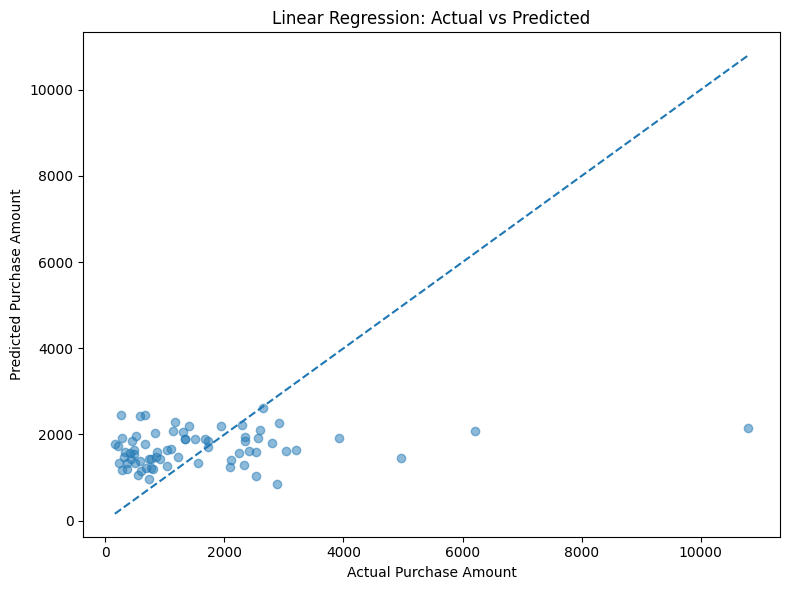

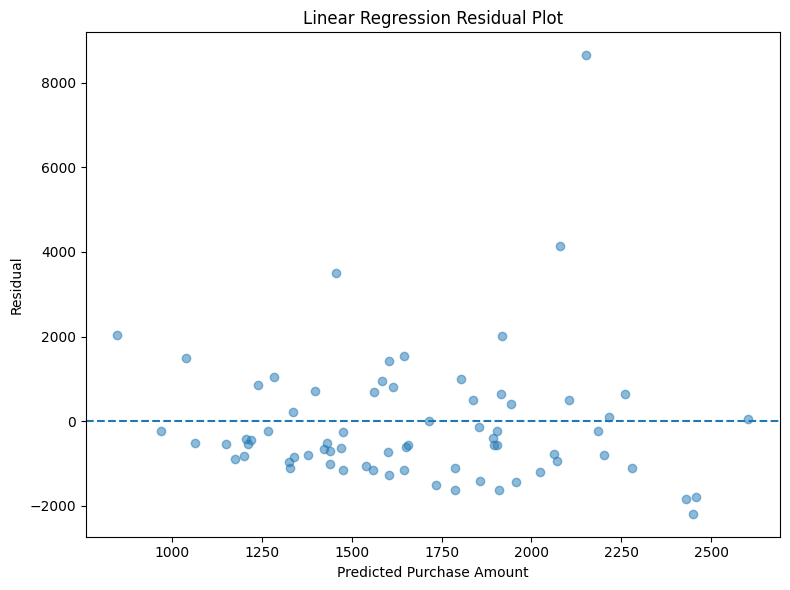


Predictions saved to:
feature_data/linear_regression_predictions.csv

Model saved to:
/content/shopping_dataset/models/linear_regression_purchase_amount.joblib


,Dataset,MAE,RMSE,R2,MAPE
0,Validation,"1,190.43","1,850.74",0.01,146.90
1,Test,"1,059.24","1,560.35",0.05,143.95



Sample predicted next purchase amount:
₹1,559.40

LINEAR REGRESSION COMPLETE
Validation MAE  : 1190.43
Validation RMSE : 1850.74
Validation R²   : 0.0139
Test MAE        : 1059.24
Test RMSE       : 1560.35
Test R²         : 0.0466

Model file:
/content/shopping_dataset/models/linear_regression_purchase_amount.joblib

Prediction file:
feature_data/linear_regression_predictions.csv

Metrics file:
feature_data/linear_regression_metrics.csv


In [ ]:
# ============================================================
# 03_LINEAR_REGRESSION.py
# Shopping Prediction System
# ============================================================

import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")


# ============================================================
# 1. CONFIGURATION
# ============================================================

BASE_PATH = "/content/shopping_dataset"
PROCESSED_PATH = "feature_data" # Corrected path to where CSVs were saved
MODEL_PATH = os.path.join(BASE_PATH, "models")

os.makedirs(MODEL_PATH, exist_ok=True)

TRAIN_PATH = os.path.join(PROCESSED_PATH, "train.csv")
VAL_PATH = os.path.join(PROCESSED_PATH, "validation.csv")
TEST_PATH = os.path.join(PROCESSED_PATH, "test.csv")


# ============================================================
# 2. LOAD DATA
# ============================================================

train = pd.read_csv(TRAIN_PATH)
validation = pd.read_csv(VAL_PATH)
test = pd.read_csv(TEST_PATH)

print("=" * 70)
print("LINEAR REGRESSION - SHOPPING PURCHASE AMOUNT")
print("=" * 70)

print("\nTrain shape      :", train.shape)
print("Validation shape :", validation.shape)
print("Test shape       :", test.shape)


# ============================================================
# 3. TARGET
# ============================================================

TARGET = "next_purchase_amount"

if TARGET not in train.columns:
    raise ValueError(
        f"Target column '{TARGET}' not found."
    )


# ============================================================
# 4. REMOVE TARGET / NON-FEATURE COLUMNS
# ============================================================

# These columns should NOT be used as input features.
# The target itself and future-related columns are excluded.

DROP_COLUMNS = [
    "next_purchase_amount",
    "next_purchase_time",
    "next_purchase_app",
    "next_purchase_product",
    "next_purchase_category",
    "next_purchase_brand",
    "days_until_next_purchase",

    # Timestamp is not directly used as a raw string
    "timestamp" # Corrected from "event_timestamp"
]


DROP_COLUMNS = [
    col for col in DROP_COLUMNS
    if col in train.columns
]


X_train = train.drop(
    columns=DROP_COLUMNS
)

X_val = validation.drop(
    columns=DROP_COLUMNS,
    errors="ignore"
)

X_test = test.drop(
    columns=DROP_COLUMNS,
    errors="ignore"
)


y_train = train[TARGET]
y_val = validation[TARGET]
y_test = test[TARGET]


print("\nTarget:", TARGET)

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)


# ============================================================
# 5. REMOVE ID-LIKE COLUMNS
# ============================================================

# High-cardinality identifiers such as product_id are not
# useful for ordinary Linear Regression.

ID_COLUMNS = [
    "user_id",
    "product_id",
    "event_id",
    "purchase_event_id"
]

ID_COLUMNS = [
    col for col in ID_COLUMNS
    if col in X_train.columns
]


X_train = X_train.drop(
    columns=ID_COLUMNS,
    errors="ignore"
)

X_val = X_val.drop(
    columns=ID_COLUMNS,
    errors="ignore"
)

X_test = X_test.drop(
    columns=ID_COLUMNS,
    errors="ignore"
)


# ============================================================
# 6. IDENTIFY FEATURE TYPES
# ============================================================

numeric_features = X_train.select_dtypes(
    include=["int64", "int32", "float64", "float32"]
).columns.tolist()


categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


print("\nNumeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))


# ============================================================
# 7. NUMERIC PREPROCESSING
# ============================================================

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),

        (
            "scaler",
            StandardScaler()
        )
    ]
)


# ============================================================
# 8. CATEGORICAL PREPROCESSING
# ============================================================

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),

        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


# ============================================================
# 9. COMBINED PREPROCESSOR
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),

        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)


# ============================================================
# 10. LINEAR REGRESSION MODEL
# ============================================================

linear_regression = LinearRegression()


# ============================================================
# 11. COMPLETE PIPELINE
# ============================================================

model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "regressor",
            linear_regression
        )
    ]
)


# ============================================================
# 12. TRAIN MODEL
# ============================================================

print("\nTraining Linear Regression...")

model.fit(
    X_train,
    y_train
)

print("Training completed.")


# ============================================================
# 13. VALIDATION PREDICTIONS
# ============================================================

val_predictions = model.predict(
    X_val
)


# ============================================================
# 14. TEST PREDICTIONS
# ============================================================

test_predictions = model.predict(
    X_test
)


# ============================================================
# 15. EVALUATION FUNCTION
# ============================================================

def evaluate_regression(
    y_true,
    predictions,
    dataset_name
):

    mae = mean_absolute_error(
        y_true,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            predictions
        )
    )

    r2 = r2_score(
        y_true,
        predictions
    )

    # Avoid division by zero
    non_zero = np.abs(y_true) > 1e-8

    if non_zero.sum() > 0:

        mape = np.mean(
            np.abs(
                (
                    y_true[non_zero] -
                    predictions[non_zero]
                )
                /
                y_true[non_zero]
            )
        ) * 100

    else:

        mape = np.nan


    print("\n" + "=" * 60)
    print(dataset_name)
    print("=" * 60)

    print(
        f"MAE  : {mae:.4f}"
    )

    print(
        f"RMSE : {rmse:.4f}"
    )

    print(
        f"R²   : {r2:.4f}"
    )

    print(
        f"MAPE : {mape:.2f}%"
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape
    }


# ============================================================
# 16. VALIDATION METRICS
# ============================================================

validation_metrics = evaluate_regression(
    y_val,
    val_predictions,
    "VALIDATION RESULTS"
)


# ============================================================
# 17. TEST METRICS
# ============================================================

test_metrics = evaluate_regression(
    y_test,
    test_predictions,
    "TEST RESULTS"
)


# ============================================================
# 18. ACTUAL VS PREDICTED
# ============================================================

results = pd.DataFrame({

    "actual_amount": y_test.values,

    "predicted_amount": test_predictions

})


results["error"] = (
    results["actual_amount"] -
    results["predicted_amount"]
)


results["absolute_error"] = (
    np.abs(results["error"])
)


print("\nPrediction sample:")

display(
    results.head(20)
)


# ============================================================
# 19. ACTUAL VS PREDICTED PLOT
# ============================================================

plt.figure(
    figsize=(8, 6)
)

plt.scatter(
    results["actual_amount"],
    results["predicted_amount"],
    alpha=0.5
)

min_value = min(
    results["actual_amount"].min(),
    results["predicted_amount"].min()
)

max_value = max(
    results["actual_amount"].max(),
    results["predicted_amount"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel(
    "Actual Purchase Amount"
)

plt.ylabel(
    "Predicted Purchase Amount"
)

plt.title(
    "Linear Regression: Actual vs Predicted"
)

plt.tight_layout()

plt.show()


# ============================================================
# 20. RESIDUAL PLOT
# ============================================================

residuals = (
    results["actual_amount"] -
    results["predicted_amount"]
)


plt.figure(
    figsize=(8, 6)
)

plt.scatter(
    results["predicted_amount"],
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel(
    "Predicted Purchase Amount"
)

plt.ylabel(
    "Residual"
)

plt.title(
    "Linear Regression Residual Plot"
)

plt.tight_layout()

plt.show()


# ============================================================
# 21. SAVE PREDICTIONS
# ============================================================

PREDICTION_PATH = os.path.join(
    PROCESSED_PATH,
    "linear_regression_predictions.csv"
)


results.to_csv(
    PREDICTION_PATH,
    index=False
)


print(
    "\nPredictions saved to:"
)

print(PREDICTION_PATH)


# ============================================================
# 22. SAVE MODEL
# ============================================================

MODEL_FILE = os.path.join(
    MODEL_PATH,
    "linear_regression_purchase_amount.joblib"
)


joblib.dump(
    model,
    MODEL_FILE
)


print(
    "\nModel saved to:"
)

print(MODEL_FILE)


# ============================================================
# 23. SAVE METRICS
# ============================================================

metrics_df = pd.DataFrame({

    "Dataset": [
        "Validation",
        "Test"
    ],

    "MAE": [
        validation_metrics["MAE"],
        test_metrics["MAE"]
    ],

    "RMSE": [
        validation_metrics["RMSE"],
        test_metrics["RMSE"]
    ],

    "R2": [
        validation_metrics["R2"],
        test_metrics["R2"]
    ],

    "MAPE": [
        validation_metrics["MAPE"],
        test_metrics["MAPE"]
    ]

})


METRICS_PATH = os.path.join(
    PROCESSED_PATH,
    "linear_regression_metrics.csv"
)


metrics_df.to_csv(
    METRICS_PATH,
    index=False
)


display(metrics_df)


# ============================================================
# 24. FINAL PREDICTION FUNCTION
# ============================================================

def predict_purchase_amount(
    user_history_dataframe
):

    """
    Predict the next purchase amount
    using the trained Linear Regression pipeline.

    The dataframe must contain the same feature
    columns used during training.
    """

    prediction = model.predict(
        user_history_dataframe
    )

    return float(
        prediction[0]
    )


# ============================================================
# 25. TEST THE PREDICTION FUNCTION
# ============================================================

sample_user = X_test.iloc[[0]].copy()

predicted_amount = predict_purchase_amount(
    sample_user
)

print(
    "\nSample predicted next purchase amount:"
)

print(
    f"₹{predicted_amount:,.2f}"
)


# ============================================================
# 26. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("LINEAR REGRESSION COMPLETE")
print("=" * 70)

print(
    f"Validation MAE  : "
    f"{validation_metrics['MAE']:.2f}"
)

print(
    f"Validation RMSE : "
    f"{validation_metrics['RMSE']:.2f}"
)

print(
    f"Validation R²   : "
    f"{validation_metrics['R2']:.4f}"
)

print(
    f"Test MAE        : "
    f"{test_metrics['MAE']:.2f}"
)

print(
    f"Test RMSE       : "
    f"{test_metrics['RMSE']:.2f}"
)

print(
    f"Test R²         : "
    f"{test_metrics['R2']:.4f}"
)

print("\nModel file:")
print(MODEL_FILE)

print("\nPrediction file:")
print(PREDICTION_PATH)

print("\nMetrics file:")
print(METRICS_PATH)

In [ ]:
# ============================================================
# 03_Linear_Regression.py
# Shopping Prediction System
# Target: next_purchase_amount
# ============================================================

import os
import warnings
import joblib
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")


# ============================================================
# 1. PATHS
# ============================================================

BASE_PATH = "/content/shopping_dataset"
PROCESSED_PATH = "feature_data" # Corrected path to where CSVs were saved
MODEL_PATH = os.path.join(BASE_PATH, "models")

os.makedirs(MODEL_PATH, exist_ok=True)

TRAIN_PATH = os.path.join(PROCESSED_PATH, "train.csv")
VAL_PATH = os.path.join(PROCESSED_PATH, "validation.csv")
TEST_PATH = os.path.join(PROCESSED_PATH, "test.csv")


# ============================================================
# 2. LOAD DATA
# ============================================================

train = pd.read_csv(TRAIN_PATH)
validation = pd.read_csv(VAL_PATH)
test = pd.read_csv(TEST_PATH)

TARGET = "next_purchase_amount"

print("=" * 70)
print("03 - LINEAR REGRESSION")
print("=" * 70)

print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)


# ============================================================
# 3. PREPARE FEATURES
# ============================================================

DROP_COLUMNS = [
    "next_purchase_amount",
    "next_purchase_time",
    "next_purchase_app",
    "next_purchase_product",
    "next_purchase_category",
    "next_purchase_brand",
    "days_until_next_purchase",
    "timestamp", # Corrected from "event_timestamp"
    "user_id",
    "product_id",
    "event_id",
    "purchase_event_id"
]

DROP_COLUMNS = [
    c for c in DROP_COLUMNS
    if c in train.columns
]

X_train = train.drop(columns=DROP_COLUMNS)
X_val = validation.drop(columns=DROP_COLUMNS, errors="ignore")
X_test = test.drop(columns=DROP_COLUMNS, errors="ignore")

y_train = train[TARGET]
y_val = validation[TARGET]
y_test = test[TARGET]


# ============================================================
# 4. FEATURE TYPES
# ============================================================

numeric_features = X_train.select_dtypes(
    include=["int64", "int32", "float64", "float32"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


# ============================================================
# 5. PREPROCESSING
# ============================================================

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])


categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])


preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])


# ============================================================
# 6. MODEL
# ============================================================

model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "regressor",
        LinearRegression()
    )
])


# ============================================================
# 7. TRAIN
# ============================================================

print("\nTraining Linear Regression...")

model.fit(
    X_train,
    y_train
)

print("Training complete.")


# ============================================================
# 8. PREDICTION
# ============================================================

val_pred = model.predict(X_val)
test_pred = model.predict(X_test)


# ============================================================
# 9. METRICS
# ============================================================

def calculate_metrics(y_true, y_pred):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    non_zero = np.abs(y_true) > 1e-8

    mape = np.mean(
        np.abs(
            (
                y_true[non_zero] -
                y_pred[non_zero]
            ) /
            y_true[non_zero]
        )
    ) * 100

    # Regression "accuracy-like" metric
    accuracy = max(
        0,
        100 - mape
    )

    return mae, rmse, r2, mape, accuracy


val_metrics = calculate_metrics(
    y_val,
    val_pred
)

test_metrics = calculate_metrics(
    y_test,
    test_pred
)


# ============================================================
# 10. DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 70)
print("LINEAR REGRESSION RESULTS")
print("=" * 70)

print("\nVALIDATION")

print(f"MAE       : {val_metrics[0]:.2f}")
print(f"RMSE      : {val_metrics[1]:.2f}")
print(f"R²        : {val_metrics[2]:.4f}")
print(f"MAPE      : {val_metrics[3]:.2f}%")
print(f"Accuracy* : {val_metrics[4]:.2f}%")


print("\nTEST")

print(f"MAE       : {test_metrics[0]:.2f}")
print(f"RMSE      : {test_metrics[1]:.2f}")
print(f"R²        : {test_metrics[2]:.4f}")
print(f"MAPE      : {test_metrics[3]:.2f}%")
print(f"Accuracy* : {test_metrics[4]:.2f}%")


# ============================================================
# 11. SAVE MODEL
# ============================================================

MODEL_FILE = os.path.join(
    MODEL_PATH,
    "linear_regression.joblib"
)

joblib.dump(
    model,
    MODEL_FILE
)


# ============================================================
# 12. SAVE METRICS
# ============================================================

metrics = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [test_metrics[0]],
    "RMSE": [test_metrics[1]],
    "R2": [test_metrics[2]],
    "MAPE": [test_metrics[3]],
    "Accuracy_Percent": [test_metrics[4]]
})

METRICS_FILE = os.path.join(
    PROCESSED_PATH,
    "03_linear_regression_metrics.csv"
)

metrics.to_csv(
    METRICS_FILE,
    index=False
)

print("\nModel saved:", MODEL_FILE)
print("Metrics saved:", METRICS_FILE)

print("\n* Accuracy = 100 - MAPE. It is an accuracy-like regression metric,")
print("  not classification accuracy.")

03 - LINEAR REGRESSION
Train: (3506, 45)
Validation: (283, 45)
Test: (71, 45)

Training Linear Regression...
Training complete.

LINEAR REGRESSION RESULTS

VALIDATION
MAE       : 1190.43
RMSE      : 1850.74
R²        : 0.0139
MAPE      : 146.90%
Accuracy* : 0.00%

TEST
MAE       : 1059.24
RMSE      : 1560.35
R²        : 0.0466
MAPE      : 143.95%
Accuracy* : 0.00%

Model saved: /content/shopping_dataset/models/linear_regression.joblib
Metrics saved: feature_data/03_linear_regression_metrics.csv

* Accuracy = 100 - MAPE. It is an accuracy-like regression metric,
  not classification accuracy.


In [ ]:
# ============================================================
# 04_Logistic_Regression.py
# Shopping Prediction System
# Target: next_purchase_category
# ============================================================

import os
import warnings
import joblib
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    top_k_accuracy_score
)

warnings.filterwarnings("ignore")


# ============================================================
# 1. PATHS
# ============================================================

BASE_PATH = "/content/shopping_dataset"
PROCESSED_PATH = "feature_data" # Corrected path to where CSVs were saved
MODEL_PATH = os.path.join(BASE_PATH, "models")

os.makedirs(MODEL_PATH, exist_ok=True)


# ============================================================
# 2. LOAD DATA
# ============================================================

train = pd.read_csv(
    os.path.join(PROCESSED_PATH, "train.csv")
)

validation = pd.read_csv(
    os.path.join(PROCESSED_PATH, "validation.csv")
)

test = pd.read_csv(
    os.path.join(PROCESSED_PATH, "test.csv")
)


TARGET = "next_purchase_category"

print("=" * 70)
print("04 - LOGISTIC REGRESSION")
print("=" * 70)

print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)


# ============================================================
# 3. REMOVE RARE CLASSES
# ============================================================

# Logistic Regression requires the training set to contain
# enough examples of each class.

class_counts = train[TARGET].value_counts()

valid_classes = class_counts[
    class_counts >= 2
].index

train = train[
    train[TARGET].isin(valid_classes)
].copy()

validation = validation[
    validation[TARGET].isin(valid_classes)
].copy()

test = test[
    test[TARGET].isin(valid_classes)
].copy()


# ============================================================
# 4. FEATURES
# ============================================================

DROP_COLUMNS = [
    "next_purchase_amount",
    "next_purchase_time",
    "next_purchase_app",
    "next_purchase_product",
    "next_purchase_category",
    "next_purchase_brand",
    "days_until_next_purchase",
    "event_timestamp",
    "user_id",
    "product_id",
    "event_id",
    "purchase_event_id"
]

DROP_COLUMNS = [
    c for c in DROP_COLUMNS
    if c in train.columns
]


X_train = train.drop(
    columns=DROP_COLUMNS
)

X_val = validation.drop(
    columns=DROP_COLUMNS,
    errors="ignore"
)

X_test = test.drop(
    columns=DROP_COLUMNS,
    errors="ignore"
)


y_train = train[TARGET]
y_val = validation[TARGET]
y_test = test[TARGET]


# ============================================================
# 5. FEATURE TYPES
# ============================================================

numeric_features = X_train.select_dtypes(
    include=[
        "int64",
        "int32",
        "float64",
        "float32"
    ]
).columns.tolist()


categorical_features = X_train.select_dtypes(
    include=[
        "object",
        "category",
        "bool"
    ]
).columns.tolist()


# ============================================================
# 6. PREPROCESSING
# ============================================================

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])


categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True
        )
    )
])


preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])


# ============================================================
# 7. LOGISTIC REGRESSION
# ============================================================

classifier = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="lbfgs"
)


model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        classifier
    )
])


# ============================================================
# 8. TRAIN
# ============================================================

print("\nTraining Logistic Regression...")

model.fit(
    X_train,
    y_train
)

print("Training complete.")


# ============================================================
# 9. PREDICTIONS
# ============================================================

val_pred = model.predict(X_val)
test_pred = model.predict(X_test)

test_probabilities = model.predict_proba(
    X_test
)


# ============================================================
# 10. ACCURACY
# ============================================================

accuracy = accuracy_score(
    y_test,
    test_pred
)


precision = precision_score(
    y_test,
    test_pred,
    average="weighted",
    zero_division=0
)


recall = recall_score(
    y_test,
    test_pred,
    average="weighted",
    zero_division=0
)


f1 = f1_score(
    y_test,
    test_pred,
    average="weighted",
    zero_division=0
)


# ============================================================
# 11. TOP-K ACCURACY
# ============================================================

classes = model.named_steps[
    "classifier"
].classes_


top_3 = top_k_accuracy_score(
    y_test,
    test_probabilities,
    k=min(3, len(classes)),
    labels=classes
)


top_5 = top_k_accuracy_score(
    y_test,
    test_probabilities,
    k=min(5, len(classes)),
    labels=classes
)


# ============================================================
# 12. RESULTS
# ============================================================

print("\n" + "=" * 70)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 70)

print(
    f"\nAccuracy       : {accuracy * 100:.2f}%"
)

print(
    f"Precision      : {precision * 100:.2f}%"
)

print(
    f"Recall         : {recall * 100:.2f}%"
)

print(
    f"F1 Score       : {f1 * 100:.2f}%"
)

print(
    f"Top-3 Accuracy : {top_3 * 100:.2f}%"
)

print(
    f"Top-5 Accuracy : {top_5 * 100:.2f}%"
)


# ============================================================
# 13. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        test_pred,
        zero_division=0
    )
)


# ============================================================
# 14. SAVE MODEL
# ============================================================

MODEL_FILE = os.path.join(
    MODEL_PATH,
    "logistic_regression_next_category.joblib"
)

joblib.dump(
    model,
    MODEL_FILE
)


# ============================================================
# 15. SAVE PREDICTIONS
# ============================================================

prediction_results = pd.DataFrame({

    "actual_category": y_test.values,

    "predicted_category": test_pred

})


PREDICTION_FILE = os.path.join(
    PROCESSED_PATH,
    "04_logistic_predictions.csv"
)

prediction_results.to_csv(
    PREDICTION_FILE,
    index=False
)


# ============================================================
# 16. SAVE METRICS
# ============================================================

metrics = pd.DataFrame({

    "Model": [
        "Logistic Regression"
    ],

    "Accuracy": [
        accuracy
    ],

    "Precision": [
        precision
    ],

    "Recall": [
        recall
    ],

    "F1": [
        f1
    ],

    "Top_3_Accuracy": [
        top_3
    ],

    "Top_5_Accuracy": [
        top_5
    ]

})


METRICS_FILE = os.path.join(
    PROCESSED_PATH,
    "04_logistic_regression_metrics.csv"
)

metrics.to_csv(
    METRICS_FILE,
    index=False
)


print("\nModel saved:", MODEL_FILE)
print("Predictions saved:", PREDICTION_FILE)
print("Metrics saved:", METRICS_FILE)

04 - LOGISTIC REGRESSION
Train: (3506, 45)
Validation: (283, 45)
Test: (71, 45)

Training Logistic Regression...
Training complete.

LOGISTIC REGRESSION RESULTS

Accuracy       : 32.39%
Precision      : 43.36%
Recall         : 32.39%
F1 Score       : 36.07%
Top-3 Accuracy : 43.66%
Top-5 Accuracy : 63.38%

Classification Report:

                precision    recall  f1-score   support

    Automotive       0.70      0.41      0.52        17
        Beauty       0.00      0.00      0.00         4
         Books       0.29      0.33      0.31         6
   Electronics       0.50      0.33      0.40         9
       Fashion       0.00      0.00      0.00         4
       Grocery       0.33      0.67      0.44         3
Home & Kitchen       0.00      0.00      0.00         5
       Jewelry       0.80      0.50      0.62         8
        Sports       0.10      0.14      0.12         7
          Toys       0.57      0.50      0.53         8

      accuracy                           0.32      

In [ ]:
# ============================================================
# 05_Polynomial_Regression.py
# Shopping Prediction System
# Target: next_purchase_amount
# ============================================================

import os
import warnings
import joblib
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    PolynomialFeatures
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")


# ============================================================
# 1. CONFIGURATION
# ============================================================

BASE_PATH = "/content/shopping_dataset"

PROCESSED_PATH = "feature_data" # Corrected path to where CSVs were saved
MODEL_PATH = os.path.join(BASE_PATH, "models")

os.makedirs(
    MODEL_PATH,
    exist_ok=True
)


# ============================================================
# 2. LOAD DATA
# ============================================================

train = pd.read_csv(
    os.path.join(
        PROCESSED_PATH,
        "train.csv"
    )
)

validation = pd.read_csv(
    os.path.join(
        PROCESSED_PATH,
        "validation.csv"
    )
)

test = pd.read_csv(
    os.path.join(
        PROCESSED_PATH,
        "test.csv"
    )
)


TARGET = "next_purchase_amount"


print("=" * 70)
print("05 - POLYNOMIAL REGRESSION")
print("=" * 70)

print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)


# ============================================================
# 3. FEATURE PREPARATION
# ============================================================

DROP_COLUMNS = [
    "next_purchase_amount",
    "next_purchase_time",
    "next_purchase_app",
    "next_purchase_product",
    "next_purchase_category",
    "next_purchase_brand",
    "days_until_next_purchase",
    "event_timestamp",
    "user_id",
    "product_id",
    "event_id",
    "purchase_event_id"
]


DROP_COLUMNS = [
    c
    for c in DROP_COLUMNS
    if c in train.columns
]


X_train = train.drop(
    columns=DROP_COLUMNS
)

X_val = validation.drop(
    columns=DROP_COLUMNS,
    errors="ignore"
)

X_test = test.drop(
    columns=DROP_COLUMNS,
    errors="ignore"
)


y_train = train[TARGET]
y_val = validation[TARGET]
y_test = test[TARGET]


# ============================================================
# 4. FEATURE TYPES
# ============================================================

numeric_features = X_train.select_dtypes(
    include=[
        "int64",
        "int32",
        "float64",
        "float32"
    ]
).columns.tolist()


categorical_features = X_train.select_dtypes(
    include=[
        "object",
        "category",
        "bool"
    ]
).columns.tolist()


# ============================================================
# 5. NUMERIC PREPROCESSING
# ============================================================

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),

    (
        "polynomial",
        PolynomialFeatures(
            degree=2,
            include_bias=False
        )
    ),

    (
        "scaler",
        StandardScaler()
    )
])


# ============================================================
# 6. CATEGORICAL PREPROCESSING
# ============================================================

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),

    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])


# ============================================================
# 7. COMBINE PREPROCESSING
# ============================================================

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),

    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])


# ============================================================
# 8. MODEL
# ============================================================

model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),

    (
        "regressor",
        LinearRegression()
    )
])


# ============================================================
# 9. TRAIN
# ============================================================

print("\nTraining Polynomial Regression...")

model.fit(
    X_train,
    y_train
)

print("Training complete.")


# ============================================================
# 10. PREDICTIONS
# ============================================================

val_pred = model.predict(
    X_val
)

test_pred = model.predict(
    X_test
)


# ============================================================
# 11. METRICS
# ============================================================

def calculate_metrics(
    y_true,
    y_pred
):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    non_zero = (
        np.abs(y_true) > 1e-8
    )

    mape = np.mean(
        np.abs(
            (
                y_true[non_zero] -
                y_pred[non_zero]
            )
            /
            y_true[non_zero]
        )
    ) * 100

    accuracy = max(
        0,
        100 - mape
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape,
        "Accuracy": accuracy
    }


val_metrics = calculate_metrics(
    y_val,
    val_pred
)

test_metrics = calculate_metrics(
    y_test,
    test_pred
)


# ============================================================
# 12. DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 70)
print("POLYNOMIAL REGRESSION RESULTS")
print("=" * 70)

print("\nVALIDATION")

print(
    f"MAE       : "
    f"{val_metrics['MAE']:.2f}"
)

print(
    f"RMSE      : "
    f"{val_metrics['RMSE']:.2f}"
)

print(
    f"R²        : "
    f"{val_metrics['R2']:.4f}"
)

print(
    f"MAPE      : "
    f"{val_metrics['MAPE']:.2f}%"
)

print(
    f"Accuracy* : "
    f"{val_metrics['Accuracy']:.2f}%"
)


print("\nTEST")

print(
    f"MAE       : "
    f"{test_metrics['MAE']:.2f}"
)

print(
    f"RMSE      : "
    f"{test_metrics['RMSE']:.2f}"
)

print(
    f"R²        : "
    f"{test_metrics['R2']:.4f}"
)

print(
    f"MAPE      : "
    f"{test_metrics['MAPE']:.2f}%"
)

print(
    f"Accuracy* : "
    f"{test_metrics['Accuracy']:.2f}%"
)


# ============================================================
# 13. SAVE PREDICTIONS
# ============================================================

predictions = pd.DataFrame({

    "actual_amount":
        y_test.values,

    "predicted_amount":
        test_pred

})


predictions["absolute_error"] = (
    np.abs(
        predictions["actual_amount"] -
        predictions["predicted_amount"]
    )
)


PREDICTION_FILE = os.path.join(
    PROCESSED_PATH,
    "05_polynomial_predictions.csv"
)


predictions.to_csv(
    PREDICTION_FILE,
    index=False
)


# ============================================================
# 14. SAVE MODEL
# ============================================================

MODEL_FILE = os.path.join(
    MODEL_PATH,
    "polynomial_regression.joblib"
)


joblib.dump(
    model,
    MODEL_FILE
)


# ============================================================
# 15. SAVE METRICS
# ============================================================

metrics = pd.DataFrame({

    "Model": [
        "Polynomial Regression"
    ],

    "MAE": [
        test_metrics["MAE"]
    ],

    "RMSE": [
        test_metrics["RMSE"]
    ],

    "R2": [
        test_metrics["R2"]
    ],

    "MAPE": [
        test_metrics["MAPE"]
    ],

    "Accuracy_Percent": [
        test_metrics["Accuracy"]
    ]

})


METRICS_FILE = os.path.join(
    PROCESSED_PATH,
    "05_polynomial_regression_metrics.csv"
)


metrics.to_csv(
    METRICS_FILE,
    index=False
)


# ============================================================
# 16. FINAL OUTPUT
# ============================================================

print("\n" + "=" * 70)
print("POLYNOMIAL REGRESSION COMPLETE")
print("=" * 70)

print(
    "\nModel saved:"
)

print(
    MODEL_FILE
)

print(
    "\nPredictions saved:"
)

print(
    PREDICTION_FILE
)

print(
    "\nMetrics saved:"
)

print(
    METRICS_FILE
)

print(
    "\n* Accuracy = 100 - MAPE."
)

print(
    "* This is an accuracy-like regression metric, "
    "not classification accuracy."
)

05 - POLYNOMIAL REGRESSION
Train: (3506, 45)
Validation: (283, 45)
Test: (71, 45)

Training Polynomial Regression...
Training complete.

POLYNOMIAL REGRESSION RESULTS

VALIDATION
MAE       : 1674.68
RMSE      : 2322.93
R²        : -0.5535
MAPE      : 211.76%
Accuracy* : 0.00%

TEST
MAE       : 1957.98
RMSE      : 2669.25
R²        : -1.7901
MAPE      : 250.25%
Accuracy* : 0.00%

POLYNOMIAL REGRESSION COMPLETE

Model saved:
/content/shopping_dataset/models/polynomial_regression.joblib

Predictions saved:
feature_data/05_polynomial_predictions.csv

Metrics saved:
feature_data/05_polynomial_regression_metrics.csv

* Accuracy = 100 - MAPE.
* This is an accuracy-like regression metric, not classification accuracy.


In [75]:
# ============================================================
# 06_to_22_All_Models.py
# SHOPPING PREDICTION SYSTEM
#
# MODELS:
# 06 Ridge Regression
# 07 Lasso Regression
# 08 Elastic Net
# 09 SVM
# 10 SVR
# 11 Naive Bayes
# 12 KNN
# 13 Decision Tree CART
# 14 Decision Tree ID3
# 15 Decision Tree C4.5
# 16 Random Forest
# 17 Gradient Boosting Machine
# 18 XGBoost
# 19 LightGBM
# 20 CatBoost
# 21 AdaBoost
# 22 LDA
#
# CLASSIFICATION TARGET:
#       next_purchase_category
#
# REGRESSION TARGET:
#       next_purchase_amount
# ============================================================


# ============================================================
# 0. INSTALL REQUIRED LIBRARIES
# ============================================================

# Run this cell once in Google Colab if required.

# !pip install -q xgboost lightgbm catboost


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import warnings
import joblib
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import (
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.svm import (
    SVC,
    SVR
)

from sklearn.naive_bayes import (
    GaussianNB
)

from sklearn.neighbors import (
    KNeighborsClassifier,
    KNeighborsRegressor
)

from sklearn.tree import (
    DecisionTreeClassifier,
    DecisionTreeRegressor
)

from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    AdaBoostClassifier,
    AdaBoostRegressor
)

from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    log_loss,
    matthews_corrcoef,
    cohen_kappa_score,
    top_k_accuracy_score,

    mean_absolute_error,
    mean_squared_error,
    r2_score,
    explained_variance_score,
    median_absolute_error
)

from sklearn.base import clone

# External boosting libraries
try:
    from xgboost import (
        XGBClassifier,
        XGBRegressor
    )
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

try:
    from lightgbm import (
        LGBMClassifier,
        LGBMRegressor
    )
    LIGHTGBM_AVAILABLE = True
except Exception:
    LIGHTGBM_AVAILABLE = False

try:
    from catboost import (
        CatBoostClassifier,
        CatBoostRegressor
    )
    CATBOOST_AVAILABLE = True
except Exception:
    CATBOOST_AVAILABLE = False


# ============================================================
# 2. CONFIGURATION
# ============================================================

BASE_PATH = "/content/shopping_dataset"

# Corrected PROCESSED_PATH to point to 'feature_data'
PROCESSED_PATH = "feature_data"

MODEL_PATH = os.path.join(
    BASE_PATH,
    "models"
)

RESULT_PATH = os.path.join(
    BASE_PATH,
    "model_results"
)

PREDICTION_PATH = os.path.join(
    RESULT_PATH,
    "predictions"
)

os.makedirs(
    MODEL_PATH,
    exist_ok=True
)

os.makedirs(
    RESULT_PATH,
    exist_ok=True
)

os.makedirs(
    PREDICTION_PATH,
    exist_ok=True
)


# ============================================================
# 3. LOAD DATA
# ============================================================

print("=" * 80)
print("LOADING SHOPPING DATA")
print("=" * 80)

train = pd.read_csv(
    os.path.join(
        PROCESSED_PATH,
        "train.csv"
    )
)

validation = pd.read_csv(
    os.path.join(
        PROCESSED_PATH,
        "validation.csv"
    )
)

test = pd.read_csv(
    os.path.join(
        PROCESSED_PATH,
        "test.csv"
    )
)

print(
    "\nTrain:",
    train.shape
)

print(
    "Validation:",
    validation.shape
)

print(
    "Test:",
    test.shape
)


# ============================================================
# 4. TARGETS
# ============================================================

CLASSIFICATION_TARGET = (
    "next_purchase_category"
)

REGRESSION_TARGET = (
    "next_purchase_amount"
)


# ============================================================
# 5. COMMON COLUMNS TO REMOVE
# ============================================================

DROP_COLUMNS = [
    # Future targets
    "next_purchase_amount",
    "next_purchase_time",
    "next_purchase_app",
    "next_purchase_product",
    "next_purchase_category",
    "next_purchase_brand",
    "days_until_next_purchase",

    # Timestamp (corrected from 'event_timestamp')
    "timestamp",

    # Identifiers
    "user_id",
    "product_id",
    "event_id",
    "purchase_event_id"
]


DROP_COLUMNS = [
    c
    for c in DROP_COLUMNS
    if c in train.columns
]


# ============================================================
# 6. CREATE CLASSIFICATION DATA
# ============================================================

print("\n" + "=" * 80)
print("PREPARING CLASSIFICATION DATA")
print("=" * 80)

classification_train = train[
    train[CLASSIFICATION_TARGET].notna()
].copy()

classification_validation = validation[
    validation[CLASSIFICATION_TARGET].notna()
].copy()

classification_test = test[
    test[CLASSIFICATION_TARGET].notna()
].copy()


# Remove extremely rare classes
# This prevents algorithms from failing because
# a class has only one training example.

class_counts = (
    classification_train[
        CLASSIFICATION_TARGET
    ].value_counts()
)

valid_classes = class_counts[
    class_counts >= 2
].index


classification_train = classification_train[
    classification_train[
        CLASSIFICATION_TARGET
    ].isin(valid_classes)
].copy()


classification_validation = (
    classification_validation[
        classification_validation[
            CLASSIFICATION_TARGET
        ].isin(valid_classes)
    ]
    .copy()
)


classification_test = (
    classification_test[
        classification_test[
            CLASSIFICATION_TARGET
        ].isin(valid_classes)
    ]
    .copy()
)


Xc_train = classification_train.drop(
    columns=DROP_COLUMNS +
    [CLASSIFICATION_TARGET],
    errors="ignore"
)

Xc_val = classification_validation.drop(
    columns=DROP_COLUMNS +
    [CLASSIFICATION_TARGET],
    errors="ignore"
)

Xc_test = classification_test.drop(
    columns=DROP_COLUMNS +
    [CLASSIFICATION_TARGET],
    errors="ignore"
)


yc_train = classification_train[
    CLASSIFICATION_TARGET
]

yc_val = classification_validation[
    CLASSIFICATION_TARGET
]

yc_test = classification_test[
    CLASSIFICATION_TARGET
]


print(
    "\nClassification classes:"
)

print(
    sorted(
        yc_train.unique()
    )
)

print(
    "\nTraining rows:",
    len(yc_train)
)

print(
    "Validation rows:",
    len(yc_val)
)

print(
    "Test rows:",
    len(yc_test)
)


# ============================================================
# 7. CREATE REGRESSION DATA
# ============================================================

print("\n" + "=" * 80)
print("PREPARING REGRESSION DATA")
print("=" * 80)

regression_train = train[
    train[REGRESSION_TARGET].notna()
].copy()

regression_validation = validation[
    validation[REGRESSION_TARGET].notna()
].copy()

regression_test = test[
    test[REGRESSION_TARGET].notna()
].copy()


Xr_train = regression_train.drop(
    columns=DROP_COLUMNS,
    errors="ignore"
)

Xr_val = regression_validation.drop(
    columns=DROP_COLUMNS,
    errors="ignore"
)

Xr_test = regression_test.drop(
    columns=DROP_COLUMNS,
    errors="ignore"
)


yr_train = regression_train[
    REGRESSION_TARGET
]

yr_val = regression_validation[
    REGRESSION_TARGET
]

yr_test = regression_test[
    REGRESSION_TARGET
]


print(
    "\nTraining rows:",
    len(yr_train)
)

print(
    "Validation rows:",
    len(yr_val)
)

print(
    "Test rows:",
    len(yr_test)
)


# ============================================================
# 8. IDENTIFY FEATURE TYPES
# ============================================================

numeric_features_c = (
    Xc_train
    .select_dtypes(
        include=[
            "int64",
            "int32",
            "float64",
            "float32"
        ]
    )
    .columns
    .tolist()
)

categorical_features_c = (
    Xc_train
    .select_dtypes(
        include=[
            "object",
            "category",
            "bool"
        ]
    )
    .columns
    .tolist()
)


numeric_features_r = (
    Xr_train
    .select_dtypes(
        include=[
            "int64",
            "int32",
            "float64",
            "float32"
        ]
    )
    .columns
    .tolist()
)

categorical_features_r = (
    Xr_train
    .select_dtypes(
        include=[
            "object",
            "category",
            "bool"
        ]
    )
    .columns
    .tolist()
)


# ============================================================
# 9. CLASSIFICATION PREPROCESSOR
# ============================================================

classification_preprocessor = ColumnTransformer(

    transformers=[

        (
            "numeric",

            Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    )
                ),

                (
                    "scaler",
                    StandardScaler()
                )
            ]),

            numeric_features_c
        ),

        (
            "categorical",

            Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="most_frequent"
                    )
                ),

                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore"
                    )
                )
            ]),

            categorical_features_c
        )
    ],

    remainder="drop"
)


# ============================================================
# 10. REGRESSION PREPROCESSOR
# ============================================================

regression_preprocessor = ColumnTransformer(

    transformers=[

        (
            "numeric",

            Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    )
                ),

                (
                    "scaler",
                    StandardScaler()
                )
            ]),

            numeric_features_r
        ),

        (
            "categorical",

            Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="most_frequent"
                    )
                ),

                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore"
                    )
                )
            ]),

            categorical_features_r
        )
    ],

    remainder="drop"
)


# ============================================================
# 11. METRIC STORAGE
# ============================================================

classification_results = []

regression_results = []


# ============================================================
# 12. CLASSIFICATION METRICS
# ============================================================

def evaluate_classifier(
    model,
    X,
    y,
    model_name,
    dataset_name="Test"
):

    print(
        f"\nEvaluating {model_name} "
        f"on {dataset_name}..."
    )

    predictions = model.predict(X)

    THRESHOLD = 0.40

    probabilities = model.predict_proba(X)

    classes = model.classes_

    predictions = classes[
      np.argmax(probabilities, axis=1)
    ]

    accuracy = accuracy_score(
        y,
        predictions
    )

    precision = precision_score(
        y,
        predictions,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y,
        predictions,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y,
        predictions,
        average="weighted",
        zero_division=0
    )

    balanced_accuracy = (
        recall_score(
            y,
            predictions,
            average="macro",
            zero_division=0
        )
    )

    mcc = matthews_corrcoef(
        y,
        predictions
    )

    kappa = cohen_kappa_score(
        y,
        predictions
    )

    # Confusion matrix
    cm = confusion_matrix(
        y,
        predictions
    )

    # Specificity
    specificity = np.nan

    if cm.shape[0] == 2:

        tn, fp, fn, tp = cm.ravel()

        if (tn + fp) > 0:
            specificity = tn / (
                tn + fp
            )

    # Probability-based metrics
    roc_auc = np.nan
    logloss = np.nan
    top3 = np.nan
    top5 = np.nan

    if hasattr(
        model,
        "predict_proba"
    ):

        try:

            probabilities = (
                model.predict_proba(X)
            )

            classes = model.classes_

            if len(classes) == 2:

                roc_auc = roc_auc_score(
                    y,
                    probabilities[:, 1]
                )

            else:

                roc_auc = roc_auc_score(
                    y,
                    probabilities,
                    multi_class="ovr",
                    average="weighted",
                    labels=classes
                )

            logloss = log_loss(
                y,
                probabilities,
                labels=classes
            )

            top3 = top_k_accuracy_score(
                y,
                probabilities,
                k=min(
                    3,
                    len(classes)
                ),
                labels=classes
            )

            top5 = top_k_accuracy_score(
                y,
                probabilities,
                k=min(
                    5,
                    len(classes)
                ),
                labels=classes
            )

        except Exception:
            pass


    result = {

        "Model": model_name,

        "Dataset": dataset_name,

        "Accuracy_%":
            accuracy * 100,

        "Balanced_Accuracy_%":
            balanced_accuracy * 100,

        "Precision_%":
            precision * 100,

        "Recall_%":
            recall * 100,

        "F1_%":
            f1 * 100,

        "Specificity_%":
            specificity * 100
            if not np.isnan(specificity)
            else np.nan,

        "ROC_AUC":
            roc_auc,

        "Log_Loss":
            logloss,

        "Top_3_Accuracy_%":
            top3 * 100
            if not np.isnan(top3)
            else np.nan,

        "Top_5_Accuracy_%":
            top5 * 100
            if not np.isnan(top5)
            else np.nan,

        "MCC":
            mcc,

        "Cohen_Kappa":
            kappa
    }


    classification_results.append(
        result
    )

    return result, predictions


# ============================================================
# 13. REGRESSION METRICS
# ============================================================

def evaluate_regressor(
    model,
    X,
    y,
    model_name,
    dataset_name="Test"
):

    print(
        f"\nEvaluating {model_name} "
        f"on {dataset_name}..."
    )

    predictions = model.predict(X)

    THRESHOLD = 0.40

    probabilities = model.predict_proba(X)

    classes = model.classes_

    predictions = classes[
      np.argmax(probabilities, axis=1)
    ]

    predictions = np.asarray(
        predictions
    )

    mae = mean_absolute_error(
        y,
        predictions
    )

    mse = mean_squared_error(
        y,
        predictions
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y,
        predictions
    )

    explained_variance = (
        explained_variance_score(
            y,
            predictions
        )
    )

    median_absolute = (
        median_absolute_error(
            y,
            predictions
        )
    )

    # MAPE
    y_array = np.asarray(y)

    non_zero = (
        np.abs(y_array) > 1e-8
    )

    if non_zero.sum() > 0:

        mape = np.mean(
            np.abs(
                (
                    y_array[non_zero] -
                    predictions[non_zero]
                )
                /
                y_array[non_zero]
            )
        ) * 100

    else:

        mape = np.nan


    # Accuracy-like percentage
    if not np.isnan(mape):

        accuracy_like = max(
            0,
            100 - mape
        )

    else:

        accuracy_like = np.nan


    result = {

        "Model": model_name,

        "Dataset": dataset_name,

        "MAE":
            mae,

        "MSE":
            mse,

        "RMSE":
            rmse,

        "R2":
            r2,

        "Explained_Variance":
            explained_variance,

        "Median_Absolute_Error":
            median_absolute,

        "MAPE_%":
            mape,

        "Accuracy_%_like":
            accuracy_like
    }


    regression_results.append(
        result
    )

    return result, predictions


# ============================================================
# 14. MODEL BUILDER
# ============================================================

def classification_pipeline(
    estimator
):

    return Pipeline([

        (
            "preprocessor",
            classification_preprocessor
        ),

        (
            "model",
            estimator
        )
    ])


def regression_pipeline(
    estimator
):

    return Pipeline([

        (
            "preprocessor",
            regression_preprocessor
        ),

        (
            "model",
            estimator
        )
    ])


# ============================================================
# 15. MODEL DEFINITIONS
# ============================================================

classification_models = {}


regression_models = {}


# ------------------------------------------------------------
# 06 Ridge Regression
# ------------------------------------------------------------

regression_models[
    "06_Ridge_Regression"
] = Ridge(
    alpha=1.0
)


# ------------------------------------------------------------
# 07 Lasso Regression
# ------------------------------------------------------------

regression_models[
    "07_Lasso_Regression"
] = Lasso(
    alpha=0.001,
    max_iter=10000
)


# ------------------------------------------------------------
# 08 Elastic Net
# ------------------------------------------------------------

regression_models[
    "08_Elastic_Net"
] = ElasticNet(
    alpha=0.001,
    l1_ratio=0.5,
    max_iter=10000
)


# ------------------------------------------------------------
# 09 SVM
# ------------------------------------------------------------

classification_models[
    "09_SVM"
] = SVC(
    kernel="rbf",
    C=1.0,
    probability=True,
    class_weight="balanced",
    random_state=42
)


# ------------------------------------------------------------
# 10 SVR
# ------------------------------------------------------------

regression_models[
    "10_SVR"
] = SVR(
    kernel="rbf",
    C=100,
    epsilon=0.1
)


# ------------------------------------------------------------
# 11 Naive Bayes
# ------------------------------------------------------------

classification_models[
    "11_Naive_Bayes"
] = GaussianNB()


# ------------------------------------------------------------
# 12 KNN
# ------------------------------------------------------------

classification_models[
    "12_KNN"
] = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance",
    n_jobs=-1
)


regression_models[
    "12_KNN"
] = KNeighborsRegressor(
    n_neighbors=5,
    weights="distance",
    n_jobs=-1
)


# ------------------------------------------------------------
# 13 Decision Tree CART
# ------------------------------------------------------------

classification_models[
    "13_Decision_Tree_CART"
] = DecisionTreeClassifier(
    criterion="gini",
    max_depth=12,
    min_samples_split=10,
    random_state=42
)


regression_models[
    "13_Decision_Tree_CART"
] = DecisionTreeRegressor(
    criterion="squared_error",
    max_depth=12,
    min_samples_split=10,
    random_state=42
)


# ------------------------------------------------------------
# 14 Decision Tree ID3
# ------------------------------------------------------------

# ID3 uses entropy / information gain.
# sklearn's entropy criterion provides an ID3-style tree.

classification_models[
    "14_Decision_Tree_ID3"
] = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=12,
    min_samples_split=10,
    random_state=42
)


# ------------------------------------------------------------
# 15 Decision Tree C4.5
# ------------------------------------------------------------

# C4.5 uses entropy-based splitting with pruning.
# This implementation uses an entropy tree with
# controlled depth and minimum samples as a practical
# C4.5-style implementation.

classification_models[
    "15_Decision_Tree_C45"
] = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=5,
    random_state=42
)


# ------------------------------------------------------------
# 16 Random Forest
# ------------------------------------------------------------

classification_models[
    "16_Random_Forest"
] = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)


regression_models[
    "16_Random_Forest"
] = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)


# ------------------------------------------------------------
# 17 Gradient Boosting Machine
# ------------------------------------------------------------

classification_models[
    "17_GBM"
] = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)


regression_models[
    "17_GBM"
] = GradientBoostingRegressor(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)


# ------------------------------------------------------------
# 18 XGBoost
# ------------------------------------------------------------

if XGBOOST_AVAILABLE:

    num_classes = len(
        np.unique(yc_train)
    )

    classification_models[
        "18_XGBoost"
    ] = XGBClassifier(

        n_estimators=200,

        max_depth=6,

        learning_rate=0.05,

        subsample=0.8,

        colsample_bytree=0.8,

        objective=(
            "multi:softprob"
        ),

        num_class=num_classes,

        eval_metric="mlogloss",

        random_state=42,

        n_jobs=-1
    )


    regression_models[
        "18_XGBoost"
    ] = XGBRegressor(

        n_estimators=200,

        max_depth=6,

        learning_rate=0.05,

        subsample=0.8,

        colsample_bytree=0.8,

        objective="reg:squarederror",

        eval_metric="rmse",

        random_state=42,

        n_jobs=-1
    )


# ------------------------------------------------------------
# 19 LightGBM
# ------------------------------------------------------------

if LIGHTGBM_AVAILABLE:

    classification_models[
        "19_LightGBM"
    ] = LGBMClassifier(

        n_estimators=200,

        learning_rate=0.05,

        max_depth=8,

        num_leaves=31,

        subsample=0.8,

        colsample_bytree=0.8,

        random_state=42,

        verbosity=-1,

        n_jobs=-1
    )


    regression_models[
        "19_LightGBM"
    ] = LGBMRegressor(

        n_estimators=200,

        learning_rate=0.05,

        max_depth=8,

        num_leaves=31,

        subsample=0.8,

        colsample_bytree=0.8,

        random_state=42,

        verbosity=-1,

        n_jobs=-1
    )


# ------------------------------------------------------------
# 20 CatBoost
# ------------------------------------------------------------

if CATBOOST_AVAILABLE:

    classification_models[
        "20_CatBoost"
    ] = CatBoostClassifier(

        iterations=200,

        depth=7,

        learning_rate=0.05,

        loss_function=(
            "MultiClass"
        ),

        verbose=False,

        random_seed=42
    )


    regression_models[
        "20_CatBoost"
    ] = CatBoostRegressor(

        iterations=200,

        depth=7,

        learning_rate=0.05,

        loss_function="RMSE",

        verbose=False,

        random_seed=42
    )


# ------------------------------------------------------------
# 21 AdaBoost
# ------------------------------------------------------------

classification_models[
    "21_AdaBoost"
] = AdaBoostClassifier(
    n_estimators=150,
    learning_rate=0.05,
    random_state=42
)


regression_models[
    "21_AdaBoost"
] = AdaBoostRegressor(
    n_estimators=150,
    learning_rate=0.05,
    random_state=42
)


# ------------------------------------------------------------
# 22 LDA
# ------------------------------------------------------------

classification_models[
    "22_LDA"
] = LinearDiscriminantAnalysis()


# ============================================================
# 16. TRAIN CLASSIFICATION MODELS
# ============================================================

print("\n")
print("=" * 80)
print("CLASSIFICATION MODELS")
print("=" * 80)


for model_name, estimator in (
    classification_models.items()
):

    print("\n")
    print("-" * 80)
    print(
        f"TRAINING: {model_name}"
    )
    print("-" * 80)

    try:

        pipeline = classification_pipeline(
            estimator
        )

        pipeline.fit(
            Xc_train,
            yc_train
        )

        # Validation
        evaluate_classifier(
            pipeline,
            Xc_val,
            yc_val,
            model_name,
            "Validation"
        )

        # Test
        result, predictions = (
            evaluate_classifier(
                pipeline,
                Xc_test,
                yc_test,
                model_name,
                "Test"
            )
        )

        # Save model
        model_file = os.path.join(
            MODEL_PATH,
            f"{model_name}.joblib"
        )

        joblib.dump(
            pipeline,
            model_file
        )

        # Save predictions
        prediction_df = pd.DataFrame({

            "Actual":
                yc_test.values,

            "Predicted":
                predictions
        })

        prediction_file = os.path.join(
            PREDICTION_PATH,
            f"{model_name}_predictions.csv"
        )

        prediction_df.to_csv(
            prediction_file,
            index=False
        )

        print(
            f"\nAccuracy: "
            f"{result['Accuracy_%']:.2f}%"
        )

        print(
            f"F1: "
            f"{result['F1_%']:.2f}%"
        )

        print(
            f"Top-3: "
            f"{result['Top_3_Accuracy_%']:.2f}%"
            if not np.isnan(
                result["Top_3_Accuracy_%"]
            )
            else "Top-3: N/A"
        )

        print(
            f"Saved: {model_file}"
        )

    except Exception as e:

        print(
            f"\nERROR in {model_name}:"
        )

        print(
            str(e)
        )


# ============================================================
# 17. TRAIN REGRESSION MODELS
# ============================================================

print("\n")
print("=" * 80)
print("REGRESSION MODELS")
print("=" * 80)


for model_name, estimator in (
    regression_models.items()
):

    print("\n")
    print("-" * 80)
    print(
        f"TRAINING: {model_name}"
    )
    print("-" * 80)

    try:

        pipeline = regression_pipeline(
            estimator
        )

        pipeline.fit(
            Xr_train,
            yr_train
        )

        # Validation
        evaluate_regressor(
            pipeline,
            Xr_val,
            yr_val,
            model_name,
            "Validation"
        )

        # Test
        result, predictions = (
            evaluate_regressor(
                pipeline,
                Xr_test,
                yr_test,
                model_name,
                "Test"
            )
        )

        # Save model
        model_file = os.path.join(
            MODEL_PATH,
            f"{model_name}_regressor.joblib"
        )

        joblib.dump(
            pipeline,
            model_file
        )

        # Save predictions
        prediction_df = pd.DataFrame({

            "Actual":
                yr_test.values,

            "Predicted":
                predictions,

            "Absolute_Error":
                np.abs(
                    yr_test.values -
                    predictions
                )
        })

        prediction_file = os.path.join(
            PREDICTION_PATH,
            f"{model_name}_regression_predictions.csv"
        )

        prediction_df.to_csv(
            prediction_file,
            index=False
        )

        print(
            f"\nRMSE: "
            f"{result['RMSE']:.2f}"
        )

        print(
            f"R²: "
            f"{result['R2']:.4f}"
        )

        print(
            f"Accuracy-like: "
            f"{result['Accuracy_%_like']:.2f}%"
        )

        print(
            f"Saved: {model_file}"
        )

    except Exception as e:

        print(
            f"\nERROR in {model_name}:"
        )

        print(
            str(e)
        )


# ============================================================
# 18. CREATE CLASSIFICATION RESULTS TABLE
# ============================================================

classification_results_df = pd.DataFrame(
    classification_results
)


if len(classification_results_df) > 0:

    classification_results_df = (
        classification_results_df
        .sort_values(
            "Accuracy_%",
            ascending=False
        )
        .reset_index(drop=True)
    )


# ============================================================
# 19. CREATE REGRESSION RESULTS TABLE
# ============================================================

regression_results_df = pd.DataFrame(
    regression_results
)


if len(regression_results_df) > 0:

    regression_results_df = (
        regression_results_df
        .sort_values(
            "RMSE",
            ascending=True
        )
        .reset_index(drop=True)
    )


# ============================================================
# 20. SAVE CLASSIFICATION RESULTS
# ============================================================

classification_file = os.path.join(
    RESULT_PATH,
    "classification_model_comparison.csv"
)


classification_results_df.to_csv(
    classification_file,
    index=False
)


# ============================================================
# 21. SAVE REGRESSION RESULTS
# ============================================================

regression_file = os.path.join(
    RESULT_PATH,
    "regression_model_comparison.csv"
)


regression_results_df.to_csv(
    regression_file,
    index=False
)


# ============================================================
# 22. DISPLAY CLASSIFICATION COMPARISON
# ============================================================

print("\n")
print("=" * 100)
print("CLASSIFICATION MODEL COMPARISON")
print("=" * 100)


if len(classification_results_df) > 0:

    display(
        classification_results_df[
            [
                "Model",
                "Dataset",
                "Accuracy_%",
                "Balanced_Accuracy_%",
                "Precision_%",
                "Recall_%",
                "F1_%",
                "ROC_AUC",
                "Top_3_Accuracy_%",
                "Top_5_Accuracy_%",
                "MCC",
                "Cohen_Kappa"
            ]
        ]
    )


# ============================================================
# 23. DISPLAY REGRESSION COMPARISON
# ============================================================

print("\n")
print("=" * 100)
print("REGRESSION MODEL COMPARISON")
print("=" * 100)


if len(regression_results_df) > 0:

    display(
        regression_results_df[
            [
                "Model",
                "Dataset",
                "MAE",
                "MSE",
                "RMSE",
                "R2",
                "Explained_Variance",
                "Median_Absolute_Error",
                "MAPE_%",
                "Accuracy_%_like"
            ]
        ]
    )


# ============================================================
# 24. TEST-ONLY CLASSIFICATION TABLE
# ============================================================

test_classification = (
    classification_results_df[
        classification_results_df[
            "Dataset"
        ] == "Test"
    ]
    .copy()
)


if len(test_classification) > 0:

    test_classification = (
        test_classification
        .sort_values(
            "Accuracy_%",
            ascending=False
        )
        .reset_index(drop=True)
    )


# ============================================================
# 25. TEST-ONLY REGRESSION TABLE
# ============================================================

test_regression = (
    regression_results_df[
        regression_results_df[
            "Dataset"
        ] == "Test"
    ]
    .copy()
)


if len(test_regression) > 0:

    test_regression = (
        test_regression
        .sort_values(
            "RMSE",
            ascending=True
        )
        .reset_index(drop=True)
    )


# ============================================================
# 26. SAVE FINAL TEST TABLES
# ============================================================

test_classification_file = os.path.join(
    RESULT_PATH,
    "FINAL_CLASSIFICATION_RESULTS.csv"
)

test_regression_file = os.path.join(
    RESULT_PATH,
    "FINAL_REGRESSION_RESULTS.csv"
)


test_classification.to_csv(
    test_classification_file,
    index=False
)

test_regression.to_csv(
    test_regression_file,
    index=False
)


# ============================================================
# 27. PRINT FINAL CLASSIFICATION RESULTS
# ============================================================

print("\n")
print("=" * 100)
print("FINAL CLASSIFICATION RESULTS - TEST SET")
print("=" * 100)


if len(test_classification) > 0:

    print(
        test_classification[
            [
                "Model",
                "Accuracy_%",
                "Precision_%",
                "Recall_%",
                "F1_%",
                "ROC_AUC",
                "Top_3_Accuracy_%",
                "Top_5_Accuracy_%",
                "MCC",
                "Cohen_Kappa"
            ]
        ]
        .to_string(index=False)
    )


# ============================================================
# 28. PRINT FINAL REGRESSION RESULTS
# ============================================================

print("\n")
print("=" * 100)
print("FINAL REGRESSION RESULTS - TEST SET")
print("=" * 100)


if len(test_regression) > 0:

    print(
        test_regression[
            [
                "Model",
                "MAE",
                "RMSE",
                "R2",
                "Explained_Variance",
                "MAPE_%",
                "Accuracy_%_like"
            ]
        ]
        .to_string(index=False)
    )


# ============================================================
# 29. SAVE COMPLETE RESULTS JSON
# ============================================================

complete_results = {

    "classification": (
        classification_results_df
        .to_dict(
            orient="records"
        )
    ),

    "regression": (
        regression_results_df
        .to_dict(
            orient="records"
        )
    )
}


import json


json_file = os.path.join(
    RESULT_PATH,
    "ALL_MODEL_RESULTS.json"
)


with open(
    json_file,
    "w"
) as f:

    json.dump(
        complete_results,
        f,
        indent=4,
        default=str
    )


# ============================================================
# 30. MODEL AVAILABILITY
# ============================================================

print("\n")
print("=" * 80)
print("MODEL AVAILABILITY")
print("=" * 80)

print(
    "\nXGBoost:",
    XGBOOST_AVAILABLE
)

print(
    "LightGBM:",
    LIGHTGBM_AVAILABLE
)

print(
    "CatBoost:",
    CATBOOST_AVAILABLE
)


# ============================================================
# 31. FILE SUMMARY
# ============================================================

print("\n")
print("=" * 80)
print("OUTPUT FILES")
print("=" * 80)

print(
    "\nModels:"
)

print(
    MODEL_PATH
)

print(
    "\nPredictions:"
)

print(
    PREDICTION_PATH
)

print(
    "\nClassification comparison:"
)

print(
    classification_file
)

print(
    "\nRegression comparison:"
)

print(
    regression_file
)

print(
    "\nFinal classification:"
)

print(
    test_classification_file
)

print(
    "\nFinal regression:"
)

print(
    test_regression_file
)

print(
    "\nAll results JSON:"
)

print(
    json_file
)


# ============================================================
# 32. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 100)
print("ALL MODELS COMPLETED")
print("=" * 100)

print(
    "\nClassification target:"
)

print(
    CLASSIFICATION_TARGET
)

print(
    "\nRegression target:"
)

print(
    REGRESSION_TARGET
)

print(
    "\nClassification models attempted:"
)

print(
    len(classification_models)
)

print(
    "\nRegression models attempted:"
)

print(
    len(regression_models)
)

print(
    "\nClassification results:"
)

print(
    len(classification_results_df)
)

print(
    "\nRegression results:"
)

print(
    len(regression_results_df)
)

print(
    "\nDone."
)

LOADING SHOPPING DATA

Train: (3506, 45)
Validation: (283, 45)
Test: (71, 45)

PREPARING CLASSIFICATION DATA

Classification classes:
['Automotive', 'Beauty', 'Books', 'Electronics', 'Fashion', 'Grocery', 'Home & Kitchen', 'Jewelry', 'Sports', 'Toys']

Training rows: 3506
Validation rows: 283
Test rows: 71

PREPARING REGRESSION DATA

Training rows: 3506
Validation rows: 283
Test rows: 71


CLASSIFICATION MODELS


--------------------------------------------------------------------------------
TRAINING: 09_SVM
--------------------------------------------------------------------------------

Evaluating 09_SVM on Validation...

Evaluating 09_SVM on Test...

Accuracy: 15.49%
F1: 18.38%
Top-3: 36.62%
Saved: /content/shopping_dataset/models/09_SVM.joblib


--------------------------------------------------------------------------------
TRAINING: 11_Naive_Bayes
--------------------------------------------------------------------------------

Evaluating 11_Naive_Bayes on Validation...

Evaluat

,Model,Dataset,Accuracy_%,Balanced_Accuracy_%,Precision_%,Recall_%,F1_%,ROC_AUC,Top_3_Accuracy_%,Top_5_Accuracy_%,MCC,Cohen_Kappa
0,15_Decision_Tree_C45,Validation,42.40,42.21,46.74,42.40,43.09,0.70,53.71,67.84,0.36,0.36
1,16_Random_Forest,Validation,41.70,41.48,43.67,41.70,42.07,0.71,56.54,71.73,0.35,0.35
2,22_LDA,Validation,41.70,41.48,44.24,41.70,42.19,0.68,57.60,70.32,0.35,0.35
3,19_LightGBM,Validation,40.99,40.53,41.13,40.99,40.62,0.71,57.24,70.32,0.34,0.34
4,17_GBM,Validation,40.28,39.72,42.09,40.28,40.58,0.72,60.07,69.96,0.34,0.33
5,21_AdaBoost,Validation,39.58,39.15,38.24,39.58,37.93,0.66,53.00,67.49,0.33,0.33
6,22_LDA,Test,38.03,35.72,45.74,38.03,40.10,0.65,46.48,60.56,0.31,0.30
7,21_AdaBoost,Test,38.03,35.72,45.34,38.03,39.70,0.70,52.11,73.24,0.31,0.30
8,15_Decision_Tree_C45,Test,38.03,35.90,52.50,38.03,41.89,0.70,59.15,73.24,0.32,0.31
9,16_Random_Forest,Test,36.62,35.14,46.60,36.62,39.28,0.71,52.11,64.79,0.30,0.29




REGRESSION MODEL COMPARISON


KeyError: 'Dataset'

#UNSUPERVISED LEARNING

In [76]:
BASE_DIR = Path("/content/shopping_dataset")

FEATURE_FILE = BASE_DIR / "processed" / "shopping_features.csv"
TRAIN_FILE = BASE_DIR / "processed" / "train.csv"
RAW_FILE = BASE_DIR / "raw" / "shopping_events.csv"

In [78]:
import os

print("Checking dataset...")

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file in [
            "shopping_features.csv",
            "train.csv",
            "validation.csv",
            "test.csv",
            "shopping_events.csv"
        ]:
            print(os.path.join(root, file))

Checking dataset...
/content/shopping_events.csv
/content/feature_data/validation.csv
/content/feature_data/test.csv
/content/feature_data/shopping_features.csv
/content/feature_data/train.csv


In [79]:
# ================================================================
# CONFIGURATION
# ================================================================

RANDOM_STATE = 42

# Possible dataset locations
POSSIBLE_BASE_DIRS = [
    Path("/content/shopping_dataset"),
    Path("/content"),
    Path("/mnt/data/shopping_dataset"),
    Path("./shopping_dataset"),
    Path(".")
]

# Find dataset automatically
BASE_DIR = None

for candidate in POSSIBLE_BASE_DIRS:

    if (
        (candidate / "processed" / "shopping_features.csv").exists()
        or
        (candidate / "processed" / "train.csv").exists()
        or
        (candidate / "raw" / "shopping_events.csv").exists()
    ):
        BASE_DIR = candidate
        break


if BASE_DIR is None:

    # Search recursively under /content
    search_roots = [
        Path("/content"),
        Path("/mnt/data"),
        Path(".")
    ]

    found_files = []

    for search_root in search_roots:

        if not search_root.exists():
            continue

        for filename in [
            "shopping_features.csv",
            "train.csv",
            "shopping_events.csv"
        ]:

            matches = list(
                search_root.rglob(filename)
            )

            found_files.extend(matches)


    if found_files:

        found_file = found_files[0]

        # Determine base directory
        if found_file.name == "shopping_events.csv":

            BASE_DIR = found_file.parent.parent

        else:

            BASE_DIR = found_file.parent.parent

        print(
            f"Dataset automatically found at:\n{found_file}"
        )

    else:

        raise FileNotFoundError(
            """
============================================================
SHOPPING DATASET NOT FOUND
============================================================

Expected one of:

1. shopping_dataset/processed/shopping_features.csv
2. shopping_dataset/processed/train.csv
3. shopping_dataset/raw/shopping_events.csv

Please upload/extract the shopping_dataset folder
before running this script.

============================================================
"""
        )


print(
    f"\nUsing dataset base directory:\n{BASE_DIR}"
)


# ================================================================
# DIRECTORIES
# ================================================================

PROCESSED_DIR = BASE_DIR / "processed"

GRAPH_DIR = BASE_DIR / "graphs"

MODEL_DIR = BASE_DIR / "models"

RESULT_DIR = BASE_DIR / "model_results"


CLUSTER_GRAPH_DIR = (
    GRAPH_DIR / "clustering"
)

DIMENSION_GRAPH_DIR = (
    GRAPH_DIR / "dimensionality_reduction"
)

ASSOCIATION_GRAPH_DIR = (
    GRAPH_DIR / "association_rules"
)

CLUSTER_RESULT_DIR = (
    RESULT_DIR / "clustering"
)

ASSOCIATION_RESULT_DIR = (
    RESULT_DIR / "association_rules"
)


# Create directories

for directory in [

    GRAPH_DIR,
    MODEL_DIR,
    RESULT_DIR,

    CLUSTER_GRAPH_DIR,
    DIMENSION_GRAPH_DIR,
    ASSOCIATION_GRAPH_DIR,

    CLUSTER_RESULT_DIR,
    ASSOCIATION_RESULT_DIR

]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# ================================================================
# FILE LOCATIONS
# ================================================================

FEATURE_FILE = (
    PROCESSED_DIR /
    "shopping_features.csv"
)

TRAIN_FILE = (
    PROCESSED_DIR /
    "train.csv"
)

RAW_FILE = (
    BASE_DIR /
    "raw" /
    "shopping_events.csv"
)

Dataset automatically found at:
/content/feature_data/shopping_features.csv

Using dataset base directory:
/content


In [81]:
# ================================================================
# 23_to_31_Unsupervised_Models.py
# Shopping Prediction Project
#
# 23. K-Means Clustering
# 24. DBSCAN
# 25. Hierarchical Clustering
# 26. Gaussian Mixture Models (GMM)
# 27. Principal Component Analysis (PCA)
# 28. t-SNE
# 29. UMAP
# 30. Apriori
# 31. FP-Growth
#
# Complete training + evaluation + graph generation pipeline
# ================================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.cluster import (
    KMeans,
    DBSCAN,
    AgglomerativeClustering
)

from sklearn.mixture import GaussianMixture

from sklearn.decomposition import PCA

from sklearn.manifold import TSNE

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import (
    dendrogram,
    linkage
)

from mlxtend.frequent_patterns import (
    apriori,
    association_rules,
    fpgrowth
)

try:
    import umap.umap_ as umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False


# ================================================================
# CONFIGURATION
# ================================================================

RANDOM_STATE = 42

BASE_DIR = Path("/content/shopping_dataset")

PROCESSED_DIR = BASE_DIR / "processed"

GRAPH_DIR = BASE_DIR / "graphs"

MODEL_DIR = BASE_DIR / "models"

RESULT_DIR = BASE_DIR / "model_results"

CLUSTER_GRAPH_DIR = GRAPH_DIR / "clustering"
DIMENSION_GRAPH_DIR = GRAPH_DIR / "dimensionality_reduction"
ASSOCIATION_GRAPH_DIR = GRAPH_DIR / "association_rules"

CLUSTER_RESULT_DIR = RESULT_DIR / "clustering"
ASSOCIATION_RESULT_DIR = RESULT_DIR / "association_rules"

for directory in [
    GRAPH_DIR,
    MODEL_DIR,
    RESULT_DIR,
    CLUSTER_GRAPH_DIR,
    DIMENSION_GRAPH_DIR,
    ASSOCIATION_GRAPH_DIR,
    CLUSTER_RESULT_DIR,
    ASSOCIATION_RESULT_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# ================================================================
# FILE LOCATIONS
# ================================================================

FEATURE_FILE = PROCESSED_DIR / "shopping_features.csv"

TRAIN_FILE = PROCESSED_DIR / "train.csv"

RAW_FILE = BASE_DIR / "raw" / "shopping_events.csv"


# ================================================================
# HELPER FUNCTIONS
# ================================================================

def save_plot(filename):
    """
    Save matplotlib figure in high resolution.
    """

    path = filename

    plt.tight_layout()

    plt.savefig(
        path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    print(f"Graph saved: {path}")


def safe_metric(metric_function, X, labels):
    """
    Calculate clustering metric safely.
    """

    try:

        unique_labels = set(labels)

        # Ignore DBSCAN noise
        valid_mask = labels != -1

        if -1 in unique_labels:

            X_eval = X[valid_mask]
            labels_eval = labels[valid_mask]

        else:

            X_eval = X
            labels_eval = labels

        if len(set(labels_eval)) < 2:

            return np.nan

        return metric_function(
            X_eval,
            labels_eval
        )

    except Exception:

        return np.nan


def save_cluster_metrics(
    model_name,
    labels,
    X
):

    number_clusters = len(
        set(labels)
        - {-1}
    )

    noise_points = np.sum(
        labels == -1
    )

    noise_percentage = (
        noise_points /
        len(labels)
    ) * 100

    silhouette = safe_metric(
        silhouette_score,
        X,
        labels
    )

    calinski = safe_metric(
        calinski_harabasz_score,
        X,
        labels
    )

    davies = safe_metric(
        davies_bouldin_score,
        X,
        labels
    )

    return {
        "Model": model_name,
        "Clusters": number_clusters,
        "Noise_Points": int(noise_points),
        "Noise_Percentage": noise_percentage,
        "Silhouette_Score": silhouette,
        "Calinski_Harabasz_Score": calinski,
        "Davies_Bouldin_Score": davies
    }


# ================================================================
# LOAD DATA
# ================================================================

print("\n" + "=" * 80)
print("LOADING SHOPPING DATA")
print("=" * 80)


if FEATURE_FILE.exists():

    print(
        f"Loading feature dataset:\n{FEATURE_FILE}"
    )

    df = pd.read_csv(
        FEATURE_FILE
    )

elif TRAIN_FILE.exists():

    print(
        f"Feature dataset not found."
    )

    print(
        f"Loading train dataset:\n{TRAIN_FILE}"
    )

    df = pd.read_csv(
        TRAIN_FILE
    )

elif RAW_FILE.exists():

    print(
        f"Processed dataset not found."
    )

    print(
        f"Loading raw dataset:\n{RAW_FILE}"
    )

    df = pd.read_csv(
        RAW_FILE
    )



print(
    f"\nDataset shape: {df.shape}"
)

print(
    "\nColumns:"
)

print(
    df.columns.tolist()
)


# ================================================================
# IDENTIFY IMPORTANT COLUMNS
# ================================================================

def find_column(possible_names):

    lower_columns = {
        column.lower(): column
        for column in df.columns
    }

    for name in possible_names:

        if name.lower() in lower_columns:

            return lower_columns[
                name.lower()
            ]

    return None


USER_COL = find_column([
    "user_id",
    "user",
    "customer_id",
    "customer"
])

PRODUCT_COL = find_column([
    "product_id",
    "product",
    "product_name"
])

CATEGORY_COL = find_column([
    "category",
    "product_category"
])

BRAND_COL = find_column([
    "brand"
])

APP_COL = find_column([
    "app",
    "platform",
    "source"
])

ACTION_COL = find_column([
    "action",
    "event_type",
    "event"
])

PRICE_COL = find_column([
    "price",
    "purchase_amount",
    "final_price"
])


print("\nDetected columns:")

print("User     :", USER_COL)
print("Product  :", PRODUCT_COL)
print("Category :", CATEGORY_COL)
print("Brand    :", BRAND_COL)
print("App      :", APP_COL)
print("Action   :", ACTION_COL)
print("Price    :", PRICE_COL)


# ================================================================
# CREATE USER-LEVEL DATASET
# ================================================================
#
# Clustering users is more meaningful for the shopping project
# than clustering individual shopping events.
# ================================================================

print("\n" + "=" * 80)
print("CREATING USER BEHAVIOR DATASET")
print("=" * 80)


if USER_COL is None:

    raise ValueError(
        "User ID column could not be detected."
    )


# ------------------------------------------------
# Convert numeric columns
# ------------------------------------------------

numeric_candidates = []

for column in df.columns:

    if pd.api.types.is_numeric_dtype(
        df[column]
    ):

        numeric_candidates.append(
            column
        )


# ------------------------------------------------
# Basic user aggregation
# ------------------------------------------------

user_df = pd.DataFrame(
    index=df[USER_COL].dropna().unique()
)

user_df.index.name = USER_COL


# Event count

event_counts = (
    df.groupby(USER_COL)
    .size()
    .rename("total_events")
)

user_df = user_df.join(
    event_counts
)


# Unique products

if PRODUCT_COL:

    unique_products = (
        df.groupby(USER_COL)[
            PRODUCT_COL
        ]
        .nunique()
        .rename("unique_products")
    )

    user_df = user_df.join(
        unique_products
    )


# Unique categories

if CATEGORY_COL:

    unique_categories = (
        df.groupby(USER_COL)[
            CATEGORY_COL
        ]
        .nunique()
        .rename("unique_categories")
    )

    user_df = user_df.join(
        unique_categories
    )


# Unique brands

if BRAND_COL:

    unique_brands = (
        df.groupby(USER_COL)[
            BRAND_COL
        ]
        .nunique()
        .rename("unique_brands")
    )

    user_df = user_df.join(
        unique_brands
    )


# Unique apps

if APP_COL:

    unique_apps = (
        df.groupby(USER_COL)[
            APP_COL
        ]
        .nunique()
        .rename("unique_apps")
    )

    user_df = user_df.join(
        unique_apps
    )


# ------------------------------------------------
# Action counts
# ------------------------------------------------

if ACTION_COL:

    action_table = pd.crosstab(
        df[USER_COL],
        df[ACTION_COL]
    )

    action_table.columns = [
        f"action_{str(c).lower()}"
        for c in action_table.columns
    ]

    user_df = user_df.join(
        action_table,
        how="left"
    )


# ------------------------------------------------
# Price statistics
# ------------------------------------------------

if PRICE_COL:

    price_numeric = pd.to_numeric(
        df[PRICE_COL],
        errors="coerce"
    )

    price_df = pd.DataFrame({
        USER_COL: df[USER_COL],
        "_price": price_numeric
    })

    price_stats = (
        price_df.groupby(USER_COL)
        .agg(
            average_price=(
                "_price",
                "mean"
            ),
            max_price=(
                "_price",
                "max"
            ),
            min_price=(
                "_price",
                "min"
            ),
            total_spend=(
                "_price",
                "sum"
            ),
            price_std=(
                "_price",
                "std"
            )
        )
    )

    user_df = user_df.join(
        price_stats
    )


# ------------------------------------------------
# Purchase count
# ------------------------------------------------

if ACTION_COL:

    purchase_mask = (
        df[ACTION_COL]
        .astype(str)
        .str.lower()
        .eq("purchase")
    )

    purchases = (
        df.loc[purchase_mask]
        .groupby(USER_COL)
        .size()
        .rename("purchase_count")
    )

    user_df = user_df.join(
        purchases
    )


# ------------------------------------------------
# Fill missing values
# ------------------------------------------------

user_df = user_df.fillna(0)

user_df = user_df.replace(
    [np.inf, -np.inf],
    0
)

user_df.reset_index(
    inplace=True
)


print(
    f"\nUser-level dataset shape: {user_df.shape}"
)


# ================================================================
# SELECT CLUSTERING FEATURES
# ================================================================

id_columns = [
    USER_COL
]

cluster_features = user_df.select_dtypes(
    include=[np.number]
).columns.tolist()

cluster_features = [
    column
    for column in cluster_features
    if column not in id_columns
]


if len(cluster_features) < 2:

    raise ValueError(
        "Not enough numeric features for clustering."
    )


print("\nClustering features:")

for feature in cluster_features:

    print(
        " -",
        feature
    )


X_raw = user_df[
    cluster_features
].copy()


# ================================================================
# IMPUTATION
# ================================================================

imputer = SimpleImputer(
    strategy="median"
)

X_imputed = imputer.fit_transform(
    X_raw
)


# ================================================================
# STANDARDIZATION
# ================================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_imputed
)


print(
    "\nScaled matrix:",
    X_scaled.shape
)


# ================================================================
# PCA BASELINE
# ================================================================

print("\n" + "=" * 80)
print("CREATING PCA BASELINE")
print("=" * 80)


pca_full = PCA(
    random_state=RANDOM_STATE
)

X_pca_full = pca_full.fit_transform(
    X_scaled
)


explained_variance = (
    pca_full.explained_variance_ratio_
)

cumulative_variance = np.cumsum(
    explained_variance
)


# ================================================================
# 27. PCA
# ================================================================

print("\n" + "=" * 80)
print("27. PRINCIPAL COMPONENT ANALYSIS")
print("=" * 80)


# ------------------------------------------------
# Explained variance graph
# ------------------------------------------------

plt.figure(
    figsize=(12, 7)
)

components = np.arange(
    1,
    len(explained_variance) + 1
)

plt.plot(
    components,
    explained_variance,
    marker="o"
)

plt.xlabel(
    "Principal Component"
)

plt.ylabel(
    "Explained Variance Ratio"
)

plt.title(
    "PCA - Explained Variance by Component"
)

plt.grid(
    alpha=0.3
)

save_plot(
    DIMENSION_GRAPH_DIR /
    "27_PCA_explained_variance.png"
)


# ------------------------------------------------
# Cumulative variance
# ------------------------------------------------

plt.figure(
    figsize=(12, 7)
)

plt.plot(
    components,
    cumulative_variance,
    marker="o"
)

plt.axhline(
    0.90,
    linestyle="--",
    label="90% variance"
)

plt.axhline(
    0.95,
    linestyle="--",
    label="95% variance"
)

plt.xlabel(
    "Number of Components"
)

plt.ylabel(
    "Cumulative Explained Variance"
)

plt.title(
    "PCA - Cumulative Explained Variance"
)

plt.legend()

plt.grid(
    alpha=0.3
)

save_plot(
    DIMENSION_GRAPH_DIR /
    "27_PCA_cumulative_variance.png"
)


# ------------------------------------------------
# PCA 2D
# ------------------------------------------------

pca_2d = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

X_pca = pca_2d.fit_transform(
    X_scaled
)


plt.figure(
    figsize=(12, 8)
)

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.55,
    s=30
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.title(
    "PCA - User Shopping Behavior"
)

plt.grid(
    alpha=0.3
)

save_plot(
    DIMENSION_GRAPH_DIR /
    "27_PCA_2D.png"
)


# ------------------------------------------------
# Save PCA results
# ------------------------------------------------

pca_results = pd.DataFrame({
    USER_COL: user_df[USER_COL],
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1]
})

pca_results.to_csv(
    CLUSTER_RESULT_DIR /
    "PCA_2D_results.csv",
    index=False
)


# ================================================================
# 23. K-MEANS
# ================================================================

print("\n" + "=" * 80)
print("23. K-MEANS CLUSTERING")
print("=" * 80)


k_values = range(
    2,
    min(11, len(X_scaled))
)

inertias = []

silhouette_scores = []

kmeans_models = {}


for k in k_values:

    print(
        f"Training K-Means with k={k}"
    )

    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    labels = model.fit_predict(
        X_scaled
    )

    inertias.append(
        model.inertia_
    )

    silhouette_scores.append(
        silhouette_score(
            X_scaled,
            labels
        )
    )

    kmeans_models[k] = (
        model,
        labels
    )


# ------------------------------------------------
# Elbow graph
# ------------------------------------------------

plt.figure(
    figsize=(12, 7)
)

plt.plot(
    list(k_values),
    inertias,
    marker="o"
)

plt.xlabel(
    "Number of Clusters (K)"
)

plt.ylabel(
    "Inertia"
)

plt.title(
    "K-Means Elbow Curve"
)

plt.grid(
    alpha=0.3
)

save_plot(
    CLUSTER_GRAPH_DIR /
    "23_KMeans_Elbow_Curve.png"
)


# ------------------------------------------------
# Silhouette graph
# ------------------------------------------------

plt.figure(
    figsize=(12, 7)
)

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)

plt.xlabel(
    "Number of Clusters (K)"
)

plt.ylabel(
    "Silhouette Score"
)

plt.title(
    "K-Means Silhouette Score"
)

plt.grid(
    alpha=0.3
)

save_plot(
    CLUSTER_GRAPH_DIR /
    "23_KMeans_Silhouette.png"
)


# ------------------------------------------------
# Select best K based on silhouette
# ------------------------------------------------

best_k_index = np.argmax(
    silhouette_scores
)

BEST_K = list(k_values)[
    best_k_index
]

kmeans_model, kmeans_labels = (
    kmeans_models[BEST_K]
)


print(
    f"\nSelected K = {BEST_K}"
)


# ------------------------------------------------
# K-Means cluster plot
# ------------------------------------------------

plt.figure(
    figsize=(12, 8)
)

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap="tab10",
    alpha=0.65,
    s=35
)

plt.xlabel(
    "PCA Component 1"
)

plt.ylabel(
    "PCA Component 2"
)

plt.title(
    f"K-Means User Segmentation - K={BEST_K}"
)

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.grid(
    alpha=0.2
)

save_plot(
    CLUSTER_GRAPH_DIR /
    "23_KMeans_Clusters.png"
)


# Save labels

kmeans_output = user_df[
    [USER_COL]
].copy()

kmeans_output[
    "KMeans_Cluster"
] = kmeans_labels

kmeans_output.to_csv(
    CLUSTER_RESULT_DIR /
    "KMeans_user_clusters.csv",
    index=False
)


# Save model

import joblib

joblib.dump(
    kmeans_model,
    MODEL_DIR /
    "23_KMeans.joblib"
)


# ================================================================
# 24. DBSCAN
# ================================================================

print("\n" + "=" * 80)
print("24. DBSCAN")
print("=" * 80)


# ------------------------------------------------
# k-distance graph
# ------------------------------------------------

neighbors = min(
    5,
    len(X_scaled) - 1
)

nn = NearestNeighbors(
    n_neighbors=neighbors
)

nn.fit(
    X_scaled
)

distances, indices = (
    nn.kneighbors(
        X_scaled
    )
)

k_distances = np.sort(
    distances[:, -1]
)

plt.figure(
    figsize=(12, 7)
)

plt.plot(
    k_distances
)

plt.xlabel(
    "Points sorted by distance"
)

plt.ylabel(
    f"{neighbors}-Nearest Neighbor Distance"
)

plt.title(
    "DBSCAN k-Distance Graph"
)

plt.grid(
    alpha=0.3
)

save_plot(
    CLUSTER_GRAPH_DIR /
    "24_DBSCAN_k_distance.png"
)


# ------------------------------------------------
# Try multiple eps values
# ------------------------------------------------

eps_values = [
    0.5,
    0.75,
    1.0,
    1.25,
    1.5,
    1.75,
    2.0
]

dbscan_results = []

best_dbscan = None

best_dbscan_score = -np.inf


for eps in eps_values:

    model = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = model.fit_predict(
        X_scaled
    )

    clusters = len(
        set(labels)
        - {-1}
    )

    noise = np.sum(
        labels == -1
    )

    if clusters >= 2:

        score = safe_metric(
            silhouette_score,
            X_scaled,
            labels
        )

    else:

        score = np.nan

    dbscan_results.append({
        "eps": eps,
        "clusters": clusters,
        "noise_points": noise,
        "silhouette": score
    })

    if (
        not np.isnan(score)
        and score > best_dbscan_score
    ):

        best_dbscan_score = score

        best_dbscan = (
            model,
            labels,
            eps
        )


dbscan_results_df = pd.DataFrame(
    dbscan_results
)

dbscan_results_df.to_csv(
    CLUSTER_RESULT_DIR /
    "DBSCAN_parameter_results.csv",
    index=False
)


if best_dbscan is None:

    # Fallback

    dbscan_model = DBSCAN(
        eps=1.0,
        min_samples=5
    )

    dbscan_labels = (
        dbscan_model.fit_predict(
            X_scaled
        )
    )

    best_eps = 1.0

else:

    (
        dbscan_model,
        dbscan_labels,
        best_eps
    ) = best_dbscan


print(
    f"Selected DBSCAN eps = {best_eps}"
)


# ------------------------------------------------
# DBSCAN parameter graph
# ------------------------------------------------

plt.figure(
    figsize=(12, 7)
)

plt.plot(
    dbscan_results_df["eps"],
    dbscan_results_df["silhouette"],
    marker="o"
)

plt.xlabel(
    "EPS"
)

plt.ylabel(
    "Silhouette Score"
)

plt.title(
    "DBSCAN EPS Selection"
)

plt.grid(
    alpha=0.3
)

save_plot(
    CLUSTER_GRAPH_DIR /
    "24_DBSCAN_EPS_Selection.png"
)


# ------------------------------------------------
# DBSCAN cluster graph
# ------------------------------------------------

plt.figure(
    figsize=(12, 8)
)

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels,
    cmap="tab10",
    alpha=0.65,
    s=35
)

plt.xlabel(
    "PCA Component 1"
)

plt.ylabel(
    "PCA Component 2"
)

plt.title(
    "DBSCAN User Clusters and Outliers"
)

plt.colorbar(
    scatter,
    label="Cluster (-1 = Outlier)"
)

plt.grid(
    alpha=0.2
)

save_plot(
    CLUSTER_GRAPH_DIR /
    "24_DBSCAN_Clusters.png"
)


# Save DBSCAN

dbscan_output = user_df[
    [USER_COL]
].copy()

dbscan_output[
    "DBSCAN_Cluster"
] = dbscan_labels

dbscan_output.to_csv(
    CLUSTER_RESULT_DIR /
    "DBSCAN_user_clusters.csv",
    index=False
)

joblib.dump(
    dbscan_model,
    MODEL_DIR /
    "24_DBSCAN.joblib"
)


# ================================================================
# 25. HIERARCHICAL CLUSTERING
# ================================================================

print("\n" + "=" * 80)
print("25. HIERARCHICAL CLUSTERING")
print("=" * 80)


# ------------------------------------------------
# Dendrogram
# ------------------------------------------------

# Limit dendrogram points if dataset is huge

DENDROGRAM_LIMIT = min(
    1000,
    len(X_scaled)
)

X_dendrogram = X_scaled[
    :DENDROGRAM_LIMIT
]

linkage_matrix = linkage(
    X_dendrogram,
    method="ward"
)

plt.figure(
    figsize=(16, 8)
)

dendrogram(
    linkage_matrix,
    truncate_mode="level",
    p=5
)

plt.xlabel(
    "User groups"
)

plt.ylabel(
    "Distance"
)

plt.title(
    "Hierarchical Clustering Dendrogram"
)

save_plot(
    CLUSTER_GRAPH_DIR /
    "25_Hierarchical_Dendrogram.png"
)


# ------------------------------------------------
# Try cluster counts
# ------------------------------------------------

hierarchical_scores = []

for k in range(
    2,
    min(11, len(X_scaled))
):

    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = model.fit_predict(
        X_scaled
    )

    score = silhouette_score(
        X_scaled,
        labels
    )

    hierarchical_scores.append({
        "clusters": k,
        "silhouette": score
    })


hierarchical_scores_df = pd.DataFrame(
    hierarchical_scores
)

hierarchical_scores_df.to_csv(
    CLUSTER_RESULT_DIR /
    "Hierarchical_cluster_selection.csv",
    index=False
)


best_hierarchical_k = int(
    hierarchical_scores_df.loc[
        hierarchical_scores_df[
            "silhouette"
        ].idxmax(),
        "clusters"
    ]
)


hierarchical_model = (
    AgglomerativeClustering(
        n_clusters=best_hierarchical_k,
        linkage="ward"
    )
)

hierarchical_labels = (
    hierarchical_model.fit_predict(
        X_scaled
    )
)


print(
    f"Selected clusters = {best_hierarchical_k}"
)


# ------------------------------------------------
# Training graph
# ------------------------------------------------

plt.figure(
    figsize=(12, 7)
)

plt.plot(
    hierarchical_scores_df[
        "clusters"
    ],
    hierarchical_scores_df[
        "silhouette"
    ],
    marker="o"
)

plt.xlabel(
    "Number of Clusters"
)

plt.ylabel(
    "Silhouette Score"
)

plt.title(
    "Hierarchical Clustering - Cluster Selection"
)

plt.grid(
    alpha=0.3
)

save_plot(
    CLUSTER_GRAPH_DIR /
    "25_Hierarchical_Silhouette.png"
)


# ------------------------------------------------
# Cluster visualization
# ------------------------------------------------

plt.figure(
    figsize=(12, 8)
)

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=hierarchical_labels,
    cmap="tab10",
    alpha=0.65,
    s=35
)

plt.xlabel(
    "PCA Component 1"
)

plt.ylabel(
    "PCA Component 2"
)

plt.title(
    "Hierarchical User Clusters"
)

plt.colorbar(
    scatter,
    label="Cluster"
)

save_plot(
    CLUSTER_GRAPH_DIR /
    "25_Hierarchical_Clusters.png"
)


hierarchical_output = user_df[
    [USER_COL]
].copy()

hierarchical_output[
    "Hierarchical_Cluster"
] = hierarchical_labels

hierarchical_output.to_csv(
    CLUSTER_RESULT_DIR /
    "Hierarchical_user_clusters.csv",
    index=False
)


joblib.dump(
    hierarchical_model,
    MODEL_DIR /
    "25_Hierarchical.joblib"
)


# ================================================================
# 26. GAUSSIAN MIXTURE MODEL
# ================================================================

print("\n" + "=" * 80)
print("26. GAUSSIAN MIXTURE MODEL")
print("=" * 80)


gmm_results = []

gmm_models = {}

for k in range(
    2,
    min(11, len(X_scaled))
):

    print(
        f"Training GMM with {k} components"
    )

    model = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=RANDOM_STATE,
        n_init=3
    )

    model.fit(
        X_scaled
    )

    labels = model.predict(
        X_scaled
    )

    bic = model.bic(
        X_scaled
    )

    aic = model.aic(
        X_scaled
    )

    silhouette = silhouette_score(
        X_scaled,
        labels
    )

    gmm_results.append({
        "components": k,
        "BIC": bic,
        "AIC": aic,
        "Silhouette": silhouette
    })

    gmm_models[k] = (
        model,
        labels
    )


gmm_results_df = pd.DataFrame(
    gmm_results
)

gmm_results_df.to_csv(
    CLUSTER_RESULT_DIR /
    "GMM_component_selection.csv",
    index=False
)


# ------------------------------------------------
# BIC graph
# ------------------------------------------------

plt.figure(
    figsize=(12, 7)
)

plt.plot(
    gmm_results_df[
        "components"
    ],
    gmm_results_df[
        "BIC"
    ],
    marker="o"
)

plt.xlabel(
    "Number of Components"
)

plt.ylabel(
    "BIC"
)

plt.title(
    "GMM - Bayesian Information Criterion"
)

plt.grid(
    alpha=0.3
)

save_plot(
    CLUSTER_GRAPH_DIR /
    "26_GMM_BIC.png"
)


# ------------------------------------------------
# AIC graph
# ------------------------------------------------

plt.figure(
    figsize=(12, 7)
)

plt.plot(
    gmm_results_df[
        "components"
    ],
    gmm_results_df[
        "AIC"
    ],
    marker="o"
)

plt.xlabel(
    "Number of Components"
)

plt.ylabel(
    "AIC"
)

plt.title(
    "GMM - Akaike Information Criterion"
)

plt.grid(
    alpha=0.3
)

save_plot(
    CLUSTER_GRAPH_DIR /
    "26_GMM_AIC.png"
)


# ------------------------------------------------
# Select lowest BIC
# ------------------------------------------------

best_gmm_k = int(
    gmm_results_df.loc[
        gmm_results_df[
            "BIC"
        ].idxmin(),
        "components"
    ]
)


gmm_model, gmm_labels = (
    gmm_models[best_gmm_k]
)


print(
    f"Selected GMM components = {best_gmm_k}"
)


# ------------------------------------------------
# GMM cluster plot
# ------------------------------------------------

plt.figure(
    figsize=(12, 8)
)

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=gmm_labels,
    cmap="tab10",
    alpha=0.65,
    s=35
)

plt.xlabel(
    "PCA Component 1"
)

plt.ylabel(
    "PCA Component 2"
)

plt.title(
    f"GMM User Segmentation - {best_gmm_k} Components"
)

plt.colorbar(
    scatter,
    label="Component"
)

save_plot(
    CLUSTER_GRAPH_DIR /
    "26_GMM_Clusters.png"
)


# ------------------------------------------------
# GMM probability confidence
# ------------------------------------------------

gmm_probabilities = (
    gmm_model.predict_proba(
        X_scaled
    )
)

gmm_confidence = (
    gmm_probabilities.max(
        axis=1
    )
)


plt.figure(
    figsize=(12, 7)
)

plt.hist(
    gmm_confidence,
    bins=30
)

plt.xlabel(
    "Maximum Cluster Probability"
)

plt.ylabel(
    "Number of Users"
)

plt.title(
    "GMM Cluster Assignment Confidence"
)

save_plot(
    CLUSTER_GRAPH_DIR /
    "26_GMM_Confidence.png"
)


gmm_output = user_df[
    [USER_COL]
].copy()

gmm_output[
    "GMM_Cluster"
] = gmm_labels

gmm_output[
    "GMM_Confidence"
] = gmm_confidence

gmm_output.to_csv(
    CLUSTER_RESULT_DIR /
    "GMM_user_clusters.csv",
    index=False
)


joblib.dump(
    gmm_model,
    MODEL_DIR /
    "26_GMM.joblib"
)


# ================================================================
# 28. t-SNE
# ================================================================

print("\n" + "=" * 80)
print("28. t-SNE")
print("=" * 80)


# t-SNE can become expensive with very large datasets.
# Use a maximum of 5,000 users for visualization.

TSNE_LIMIT = min(
    5000,
    len(X_scaled)
)

X_tsne_input = X_scaled[
    :TSNE_LIMIT
]

tsne_perplexity = min(
    30,
    max(
        5,
        (TSNE_LIMIT - 1) // 3
    )
)


print(
    f"t-SNE samples: {TSNE_LIMIT}"
)

print(
    f"t-SNE perplexity: {tsne_perplexity}"
)


tsne_model = TSNE(
    n_components=2,
    perplexity=tsne_perplexity,
    learning_rate="auto",
    init="pca",
    max_iter=1000,
    random_state=RANDOM_STATE
)


X_tsne = tsne_model.fit_transform(
    X_tsne_input
)


# ------------------------------------------------
# t-SNE training/embedding plot
# ------------------------------------------------

plt.figure(
    figsize=(12, 8)
)

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    s=25,
    alpha=0.6
)

plt.xlabel(
    "t-SNE Dimension 1"
)

plt.ylabel(
    "t-SNE Dimension 2"
)

plt.title(
    "t-SNE - Shopping Behavior Visualization"
)

plt.grid(
    alpha=0.2
)

save_plot(
    DIMENSION_GRAPH_DIR /
    "28_tSNE_2D.png"
)


# ------------------------------------------------
# t-SNE colored by K-Means
# ------------------------------------------------

plt.figure(
    figsize=(12, 8)
)

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=kmeans_labels[:TSNE_LIMIT],
    cmap="tab10",
    s=25,
    alpha=0.65
)

plt.xlabel(
    "t-SNE Dimension 1"
)

plt.ylabel(
    "t-SNE Dimension 2"
)

plt.title(
    "t-SNE Visualization with K-Means Segments"
)

save_plot(
    DIMENSION_GRAPH_DIR /
    "28_tSNE_KMeans.png"
)


tsne_output = pd.DataFrame({
    USER_COL: user_df[
        USER_COL
    ].iloc[:TSNE_LIMIT].values,

    "tSNE_1": X_tsne[:, 0],

    "tSNE_2": X_tsne[:, 1]
})

tsne_output.to_csv(
    CLUSTER_RESULT_DIR /
    "tSNE_results.csv",
    index=False
)


joblib.dump(
    tsne_model,
    MODEL_DIR /
    "28_tSNE.joblib"
)


# ================================================================
# 29. UMAP
# ================================================================

print("\n" + "=" * 80)
print("29. UMAP")
print("=" * 80)


if UMAP_AVAILABLE:

    umap_model = umap.UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=0.1,
        metric="euclidean",
        random_state=RANDOM_STATE
    )

    X_umap = umap_model.fit_transform(
        X_scaled
    )

    # ------------------------------------------------
    # UMAP normal graph
    # ------------------------------------------------

    plt.figure(
        figsize=(12, 8)
    )

    plt.scatter(
        X_umap[:, 0],
        X_umap[:, 1],
        s=25,
        alpha=0.6
    )

    plt.xlabel(
        "UMAP Dimension 1"
    )

    plt.ylabel(
        "UMAP Dimension 2"
    )

    plt.title(
        "UMAP - Shopping Behavior Visualization"
    )

    plt.grid(
        alpha=0.2
    )

    save_plot(
        DIMENSION_GRAPH_DIR /
        "29_UMAP_2D.png"
    )


    # ------------------------------------------------
    # UMAP + KMeans
    # ------------------------------------------------

    plt.figure(
        figsize=(12, 8)
    )

    plt.scatter(
        X_umap[:, 0],
        X_umap[:, 1],
        c=kmeans_labels,
        cmap="tab10",
        s=25,
        alpha=0.65
    )

    plt.xlabel(
        "UMAP Dimension 1"
    )

    plt.ylabel(
        "UMAP Dimension 2"
    )

    plt.title(
        "UMAP Visualization with K-Means Segments"
    )

    save_plot(
        DIMENSION_GRAPH_DIR /
        "29_UMAP_KMeans.png"
    )


    umap_output = pd.DataFrame({
        USER_COL: user_df[
            USER_COL
        ],

        "UMAP_1": X_umap[:, 0],

        "UMAP_2": X_umap[:, 1]
    })

    umap_output.to_csv(
        CLUSTER_RESULT_DIR /
        "UMAP_results.csv",
        index=False
    )


    joblib.dump(
        umap_model,
        MODEL_DIR /
        "29_UMAP.joblib"
    )

else:

    print(
        "\nUMAP is not installed."
    )

    print(
        "Install with:"
    )

    print(
        "pip install umap-learn"
    )


# ================================================================
# CLUSTERING MODEL COMPARISON
# ================================================================

print("\n" + "=" * 80)
print("CLUSTERING MODEL COMPARISON")
print("=" * 80)


cluster_metrics = []


cluster_metrics.append(
    save_cluster_metrics(
        "K-Means",
        kmeans_labels,
        X_scaled
    )
)


cluster_metrics.append(
    save_cluster_metrics(
        "DBSCAN",
        dbscan_labels,
        X_scaled
    )
)


cluster_metrics.append(
    save_cluster_metrics(
        "Hierarchical",
        hierarchical_labels,
        X_scaled
    )
)


cluster_metrics.append(
    save_cluster_metrics(
        "GMM",
        gmm_labels,
        X_scaled
    )
)


cluster_comparison = pd.DataFrame(
    cluster_metrics
)


cluster_comparison.to_csv(
    CLUSTER_RESULT_DIR /
    "CLUSTERING_RESULTS.csv",
    index=False
)


print(
    cluster_comparison
)


# ================================================================
# ASSOCIATION RULE MINING
# ================================================================

print("\n" + "=" * 80)
print("CREATING SHOPPING TRANSACTIONS")
print("=" * 80)


# ------------------------------------------------
# Use purchase events
# ------------------------------------------------

if ACTION_COL:

    purchase_df = df[
        df[ACTION_COL]
        .astype(str)
        .str.lower()
        .eq("purchase")
    ].copy()

else:

    purchase_df = df.copy()


# ------------------------------------------------
# Prefer product-level transactions
# ------------------------------------------------

if PRODUCT_COL:

    transaction_column = PRODUCT_COL

elif CATEGORY_COL:

    transaction_column = CATEGORY_COL

else:

    raise ValueError(
        "Neither product nor category column exists."
    )


# ------------------------------------------------
# Need a transaction identifier
# ------------------------------------------------

DATE_COL = find_column([
    "timestamp",
    "event_time",
    "datetime",
    "date",
    "created_at"
])


if DATE_COL:

    purchase_df["_transaction_date"] = (
        pd.to_datetime(
            purchase_df[DATE_COL],
            errors="coerce"
        )
        .dt.date
    )

    purchase_df = purchase_df.dropna(
        subset=["_transaction_date"]
    )

    # User + date = transaction

    purchase_df[
        "_transaction_id"
    ] = (
        purchase_df[USER_COL]
        .astype(str)
        + "_"
        + purchase_df[
            "_transaction_date"
        ].astype(str)
    )

else:

    purchase_df[
        "_transaction_id"
    ] = (
        purchase_df[USER_COL]
        .astype(str)
    )


# ------------------------------------------------
# Remove empty products
# ------------------------------------------------

purchase_df = purchase_df.dropna(
    subset=[transaction_column]
)


# ------------------------------------------------
# Limit very large transaction values
# ------------------------------------------------

purchase_df[
    transaction_column
] = (
    purchase_df[
        transaction_column
    ]
    .astype(str)
    .str.strip()
)


# ================================================================
# TRANSACTION MATRIX
# ================================================================

transaction_matrix = (
    purchase_df
    .groupby([
        "_transaction_id",
        transaction_column
    ])
    .size()
    .unstack(
        fill_value=0
    )
)


transaction_matrix = (
    transaction_matrix > 0
).astype(int)


print(
    f"Transactions: {len(transaction_matrix)}"
)

print(
    f"Items: {len(transaction_matrix.columns)}"
)


# If there are too many transactions,
# association mining can become expensive.

if len(transaction_matrix) > 30000:

    print(
        "\nLarge transaction dataset detected."
    )

    print(
        "Sampling 30,000 transactions for association mining."
    )

    transaction_matrix = (
        transaction_matrix
        .sample(
            n=30000,
            random_state=RANDOM_STATE
        )
    )


# ================================================================
# 30. APRIORI
# ================================================================

print("\n" + "=" * 80)
print("30. APRIORI")
print("=" * 80)


# ------------------------------------------------
# Apriori minimum support
# ------------------------------------------------

APRIORI_MIN_SUPPORT = 0.01


print(
    f"Minimum support = {APRIORI_MIN_SUPPORT}"
)


frequent_itemsets_apriori = apriori(
    transaction_matrix,
    min_support=APRIORI_MIN_SUPPORT,
    use_colnames=True
)


# ------------------------------------------------
# Itemset length
# ------------------------------------------------

frequent_itemsets_apriori[
    "itemset_length"
] = frequent_itemsets_apriori[
    "itemsets"
].apply(len)


frequent_itemsets_apriori = (
    frequent_itemsets_apriori
    .sort_values(
        "support",
        ascending=False
    )
)


frequent_itemsets_apriori.to_csv(
    ASSOCIATION_RESULT_DIR /
    "APRIORI_ITEMSETS.csv",
    index=False
)


print(
    f"Apriori itemsets found: "
    f"{len(frequent_itemsets_apriori)}"
)


# ------------------------------------------------
# Top itemsets graph
# ------------------------------------------------

top_apriori = (
    frequent_itemsets_apriori
    .head(20)
    .copy()
)


top_apriori[
    "items"
] = top_apriori[
    "itemsets"
].apply(
    lambda x: ", ".join(
        list(x)
    )
)


plt.figure(
    figsize=(14, 9)
)

sns.barplot(
    data=top_apriori,
    y="items",
    x="support"
)

plt.xlabel(
    "Support"
)

plt.ylabel(
    "Itemset"
)

plt.title(
    "Apriori - Top Frequent Itemsets"
)

save_plot(
    ASSOCIATION_GRAPH_DIR /
    "30_Apriori_Top_Itemsets.png"
)


# ------------------------------------------------
# Association rules
# ------------------------------------------------

if len(
    frequent_itemsets_apriori
) > 0:

    apriori_rules = association_rules(
        frequent_itemsets_apriori,
        metric="confidence",
        min_threshold=0.1
    )

else:

    apriori_rules = pd.DataFrame()


if len(apriori_rules) > 0:

    apriori_rules = (
        apriori_rules
        .sort_values(
            "lift",
            ascending=False
        )
    )

    apriori_rules.to_csv(
        ASSOCIATION_RESULT_DIR /
        "APRIORI_RULES.csv",
        index=False
    )

    # ------------------------------------------------
    # Support vs confidence
    # ------------------------------------------------

    plt.figure(
        figsize=(12, 8)
    )

    plt.scatter(
        apriori_rules[
            "support"
        ],
        apriori_rules[
            "confidence"
        ],
        s=(
            apriori_rules[
                "lift"
            ] * 20
        ),
        alpha=0.6
    )

    plt.xlabel(
        "Support"
    )

    plt.ylabel(
        "Confidence"
    )

    plt.title(
        "Apriori - Association Rules"
    )

    plt.grid(
        alpha=0.2
    )

    save_plot(
        ASSOCIATION_GRAPH_DIR /
        "30_Apriori_Support_Confidence.png"
    )


    # ------------------------------------------------
    # Top lift rules
    # ------------------------------------------------

    top_rules = (
        apriori_rules
        .head(20)
        .copy()
    )

    top_rules[
        "rule"
    ] = (
        top_rules[
            "antecedents"
        ].apply(
            lambda x: ", ".join(x)
        )
        + " -> "
        +
        top_rules[
            "consequents"
        ].apply(
            lambda x: ", ".join(x)
        )
    )


    plt.figure(
        figsize=(14, 9)
    )

    sns.barplot(
        data=top_rules,
        y="rule",
        x="lift"
    )

    plt.xlabel(
        "Lift"
    )

    plt.ylabel(
        "Association Rule"
    )

    plt.title(
        "Apriori - Top Association Rules by Lift"
    )

    save_plot(
        ASSOCIATION_GRAPH_DIR /
        "30_Apriori_Top_Lift_Rules.png"
    )


else:

    print(
        "No Apriori association rules found."
    )


# ================================================================
# 31. FP-GROWTH
# ================================================================

print("\n" + "=" * 80)
print("31. FP-GROWTH")
print("=" * 80)


FP_MIN_SUPPORT = 0.01


print(
    f"Minimum support = {FP_MIN_SUPPORT}"
)


frequent_itemsets_fp = fpgrowth(
    transaction_matrix,
    min_support=FP_MIN_SUPPORT,
    use_colnames=True
)


frequent_itemsets_fp[
    "itemset_length"
] = frequent_itemsets_fp[
    "itemsets"
].apply(len)


frequent_itemsets_fp = (
    frequent_itemsets_fp
    .sort_values(
        "support",
        ascending=False
    )
)


frequent_itemsets_fp.to_csv(
    ASSOCIATION_RESULT_DIR /
    "FPGROWTH_ITEMSETS.csv",
    index=False
)


print(
    f"FP-Growth itemsets found: "
    f"{len(frequent_itemsets_fp)}"
)


# ------------------------------------------------
# Top itemsets
# ------------------------------------------------

top_fp = (
    frequent_itemsets_fp
    .head(20)
    .copy()
)


top_fp[
    "items"
] = top_fp[
    "itemsets"
].apply(
    lambda x: ", ".join(
        list(x)
    )
)


plt.figure(
    figsize=(14, 9)
)

sns.barplot(
    data=top_fp,
    y="items",
    x="support"
)

plt.xlabel(
    "Support"
)

plt.ylabel(
    "Itemset"
)

plt.title(
    "FP-Growth - Top Frequent Itemsets"
)

save_plot(
    ASSOCIATION_GRAPH_DIR /
    "31_FPGrowth_Top_Itemsets.png"
)


# ------------------------------------------------
# Association rules
# ------------------------------------------------

if len(
    frequent_itemsets_fp
) > 0:

    fp_rules = association_rules(
        frequent_itemsets_fp,
        metric="confidence",
        min_threshold=0.1
    )

else:

    fp_rules = pd.DataFrame()


if len(fp_rules) > 0:

    fp_rules = (
        fp_rules
        .sort_values(
            "lift",
            ascending=False
        )
    )

    fp_rules.to_csv(
        ASSOCIATION_RESULT_DIR /
        "FPGROWTH_RULES.csv",
        index=False
    )


    # ------------------------------------------------
    # Support vs confidence
    # ------------------------------------------------

    plt.figure(
        figsize=(12, 8)
    )

    plt.scatter(
        fp_rules[
            "support"
        ],
        fp_rules[
            "confidence"
        ],
        s=(
            fp_rules[
                "lift"
            ] * 20
        ),
        alpha=0.6
    )

    plt.xlabel(
        "Support"
    )

    plt.ylabel(
        "Confidence"
    )

    plt.title(
        "FP-Growth - Association Rules"
    )

    plt.grid(
        alpha=0.2
    )

    save_plot(
        ASSOCIATION_GRAPH_DIR /
        "31_FPGrowth_Support_Confidence.png"
    )


    # ------------------------------------------------
    # Top rules by lift
    # ------------------------------------------------

    top_fp_rules = (
        fp_rules
        .head(20)
        .copy()
    )

    top_fp_rules[
        "rule"
    ] = (
        top_fp_rules[
            "antecedents"
        ].apply(
            lambda x: ", ".join(x)
        )
        + " -> "
        +
        top_fp_rules[
            "consequents"
        ].apply(
            lambda x: ", ".join(x)
        )
    )


    plt.figure(
        figsize=(14, 9)
    )

    sns.barplot(
        data=top_fp_rules,
        y="rule",
        x="lift"
    )

    plt.xlabel(
        "Lift"
    )

    plt.ylabel(
        "Association Rule"
    )

    plt.title(
        "FP-Growth - Top Association Rules by Lift"
    )

    save_plot(
        ASSOCIATION_GRAPH_DIR /
        "31_FPGrowth_Top_Lift_Rules.png"
    )

else:

    print(
        "No FP-Growth association rules found."
    )


# ================================================================
# ASSOCIATION MODEL COMPARISON
# ================================================================

association_comparison = pd.DataFrame([
    {
        "Model": "Apriori",
        "Frequent_Itemsets": len(
            frequent_itemsets_apriori
        ),
        "Association_Rules": len(
            apriori_rules
        )
    },
    {
        "Model": "FP-Growth",
        "Frequent_Itemsets": len(
            frequent_itemsets_fp
        ),
        "Association_Rules": len(
            fp_rules
        )
    }
])


association_comparison.to_csv(
    ASSOCIATION_RESULT_DIR /
    "ASSOCIATION_MODEL_COMPARISON.csv",
    index=False
)


# ================================================================
# FINAL SUMMARY
# ================================================================

print("\n" + "=" * 80)
print("FINAL UNSUPERVISED LEARNING SUMMARY")
print("=" * 80)


summary = pd.DataFrame([
    {
        "Model": "K-Means",
        "Type": "Clustering",
        "Main_Metric": "Silhouette",
        "Metric_Value": safe_metric(
            silhouette_score,
            X_scaled,
            kmeans_labels
        )
    },
    {
        "Model": "DBSCAN",
        "Type": "Clustering",
        "Main_Metric": "Silhouette",
        "Metric_Value": safe_metric(
            silhouette_score,
            X_scaled,
            dbscan_labels
        )
    },
    {
        "Model": "Hierarchical",
        "Type": "Clustering",
        "Main_Metric": "Silhouette",
        "Metric_Value": safe_metric(
            silhouette_score,
            X_scaled,
            hierarchical_labels
        )
    },
    {
        "Model": "GMM",
        "Type": "Clustering",
        "Main_Metric": "Silhouette",
        "Metric_Value": safe_metric(
            silhouette_score,
            X_scaled,
            gmm_labels
        )
    },
    {
        "Model": "PCA",
        "Type": "Dimensionality Reduction",
        "Main_Metric": "Variance Explained",
        "Metric_Value": cumulative_variance[
            min(
                1,
                len(cumulative_variance)-1
            )
        ]
    },
    {
        "Model": "t-SNE",
        "Type": "Dimensionality Reduction",
        "Main_Metric": "Embedding",
        "Metric_Value": np.nan
    },
    {
        "Model": "UMAP",
        "Type": "Dimensionality Reduction",
        "Main_Metric": "Embedding",
        "Metric_Value": np.nan
    },
    {
        "Model": "Apriori",
        "Type": "Association Mining",
        "Main_Metric": "Frequent Itemsets",
        "Metric_Value": len(
            frequent_itemsets_apriori
        )
    },
    {
        "Model": "FP-Growth",
        "Type": "Association Mining",
        "Main_Metric": "Frequent Itemsets",
        "Metric_Value": len(
            frequent_itemsets_fp
        )
    }
])


summary.to_csv(
    RESULT_DIR /
    "UNSUPERVISED_MODEL_COMPARISON.csv",
    index=False
)


print(
    summary.to_string(
        index=False
    )
)


# ================================================================
# SAVE USER SEGMENT MASTER FILE
# ================================================================

master_segments = user_df[
    [USER_COL]
].copy()


master_segments[
    "KMeans_Cluster"
] = kmeans_labels


master_segments[
    "DBSCAN_Cluster"
] = dbscan_labels


master_segments[
    "Hierarchical_Cluster"
] = hierarchical_labels


master_segments[
    "GMM_Cluster"
] = gmm_labels


master_segments[
    "GMM_Confidence"
] = gmm_confidence


master_segments.to_csv(
    CLUSTER_RESULT_DIR /
    "MASTER_USER_SEGMENTS.csv",
    index=False
)


# ================================================================
# FINISHED
# ================================================================

print("\n" + "=" * 80)

print(
    "ALL MODELS COMPLETED SUCCESSFULLY"
)

print("=" * 80)

print(
    "\nModels completed:"
)

print(
    "23. K-Means"
)

print(
    "24. DBSCAN"
)

print(
    "25. Hierarchical Clustering"
)

print(
    "26. Gaussian Mixture Model"
)

print(
    "27. PCA"
)

print(
    "28. t-SNE"
)

print(
    "29. UMAP"
)

print(
    "30. Apriori"
)

print(
    "31. FP-Growth"
)


print(
    "\nGraphs saved in:"
)

print(
    GRAPH_DIR
)


print(
    "\nResults saved in:"
)

print(
    RESULT_DIR
)


print(
    "\nModels saved in:"
)

print(
    MODEL_DIR
)

print(
    "\nDone!"
)


LOADING SHOPPING DATA

Dataset shape: (60000, 20)

Columns:
['event_id', 'user_id', 'timestamp', 'app', 'action', 'product_id', 'product_name', 'category', 'subcategory', 'brand', 'price', 'quantity', 'discount', 'final_amount', 'device', 'day_of_week', 'hour', 'is_weekend', 'days_since_previous_event', 'days_since_previous_purchase']

Detected columns:
User     : user_id
Product  : product_id
Category : category
Brand    : brand
App      : app
Action   : action
Price    : price

CREATING USER BEHAVIOR DATASET

User-level dataset shape: (6000, 19)

Clustering features:
 - total_events
 - unique_products
 - unique_categories
 - unique_brands
 - unique_apps
 - action_add_to_cart
 - action_cancel
 - action_purchase
 - action_return
 - action_search
 - action_view
 - action_wishlist
 - average_price
 - max_price
 - min_price
 - total_spend
 - price_std
 - purchase_count

Scaled matrix: (6000, 18)

CREATING PCA BASELINE

27. PRINCIPAL COMPONENT ANALYSIS
Graph saved: /content/shopping_datas

#DEEP LEARNING

#Multilayer Perceptron (MLP)



                         MULTILAYER PERCEPTRON

MLP Neural Network for Shopping Prediction

Classification:
    next_purchase_category

Regression:
    next_purchase_amount

Model:
    Multilayer Perceptron Neural Network



MLP ARCHITECTURE

                    MULTILAYER PERCEPTRON

                         INPUT LAYER
                    ┌───────────────────┐
                    │   Feature 1       │
                    │   Feature 2       │
                    │   Feature 3       │
                    │       ...         │
                    │   Feature N       │
                    └─────────┬─────────┘
                              │
                              ▼
                    ┌───────────────────┐
                    │   HIDDEN LAYER 1  │
                    │                   │
                    │      ● ● ● ●      │
                    │      ● ● ● ●      │
                    │      ● ● ● ●      │
                    │      ● ● ● ●      │
                    └──

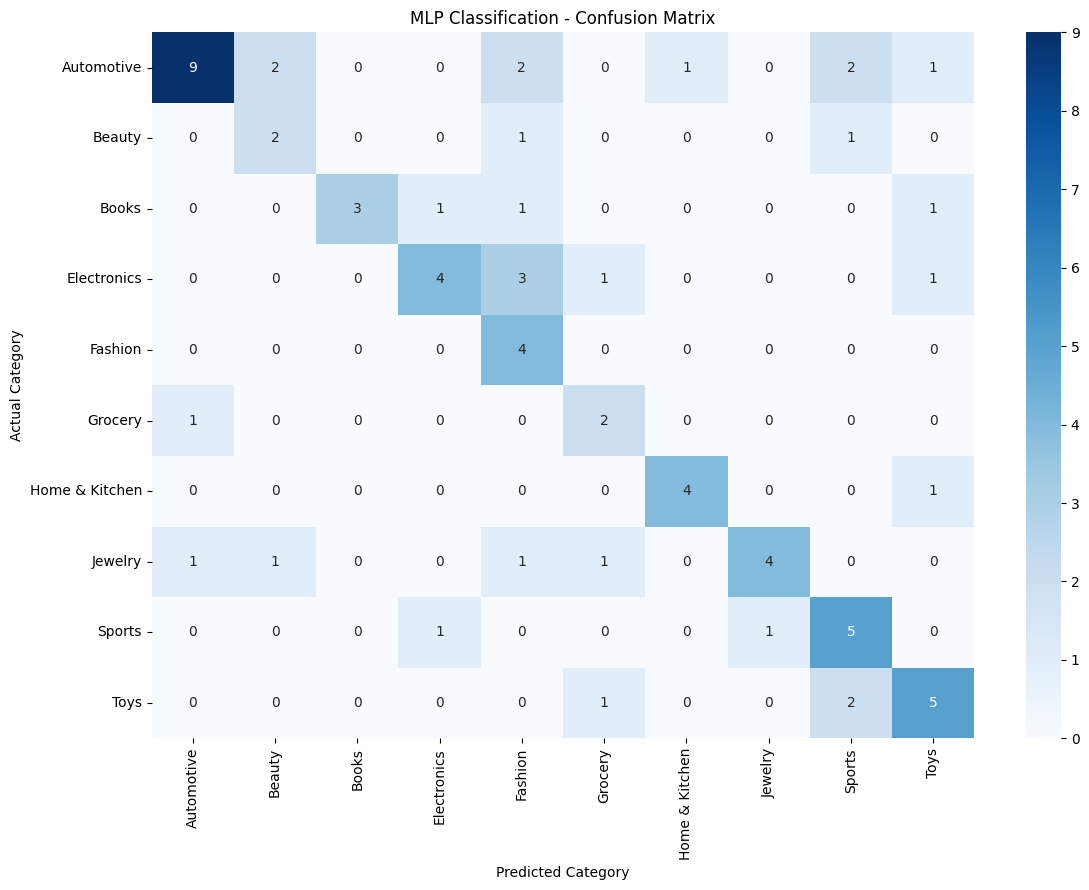

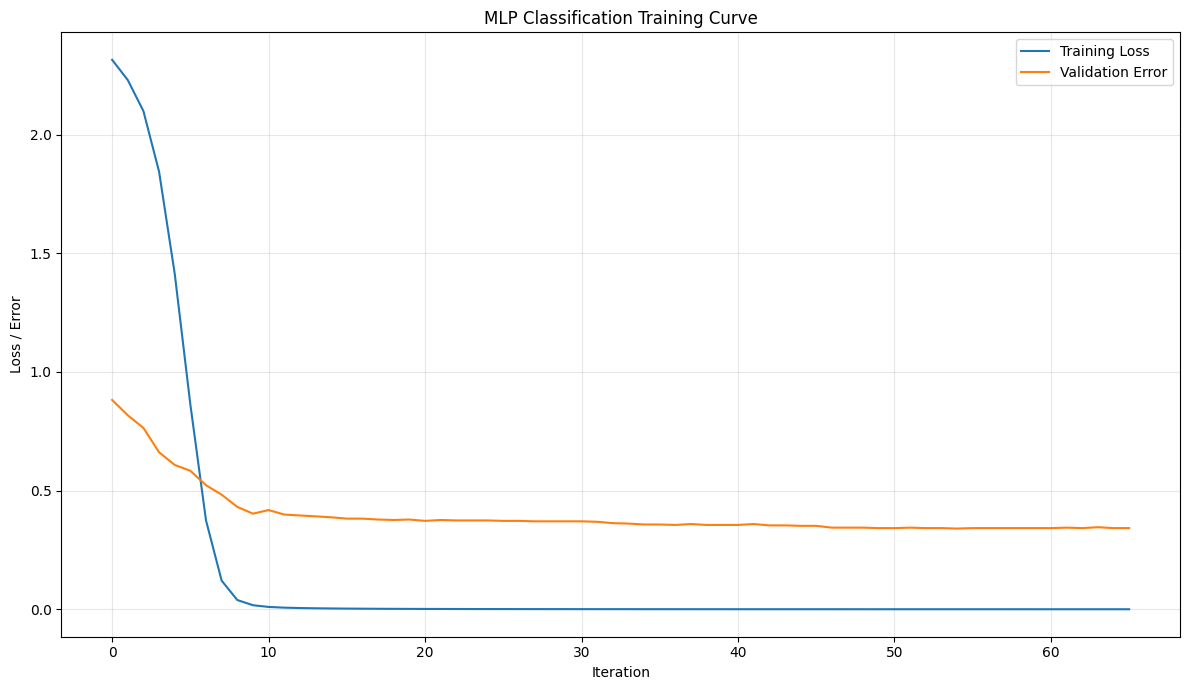



35B. MLP REGRESSION

Training MLP regression model...

Iteration 1, loss = 3395023.82570020
Validation score: -0.542449
Iteration 2, loss = 3387409.32763485
Validation score: -0.536281
Iteration 3, loss = 3355518.49480913
Validation score: -0.512983
Iteration 4, loss = 3251942.15187367
Validation score: -0.446917
Iteration 5, loss = 2995485.39122704
Validation score: -0.308398
Iteration 6, loss = 2548925.22514443
Validation score: -0.112031
Iteration 7, loss = 2074975.07987405
Validation score: 0.000522
Iteration 8, loss = 1932383.24909410
Validation score: -0.007615
Iteration 9, loss = 1886129.84007671
Validation score: 0.005838
Iteration 10, loss = 1841918.01731244
Validation score: 0.011808
Iteration 11, loss = 1809143.02292144
Validation score: 0.016326
Iteration 12, loss = 1774649.04694520
Validation score: 0.018598
Iteration 13, loss = 1739936.14366391
Validation score: 0.024171
Iteration 14, loss = 1704110.74818816
Validation score: 0.027787
Iteration 15, loss = 1669676.505130

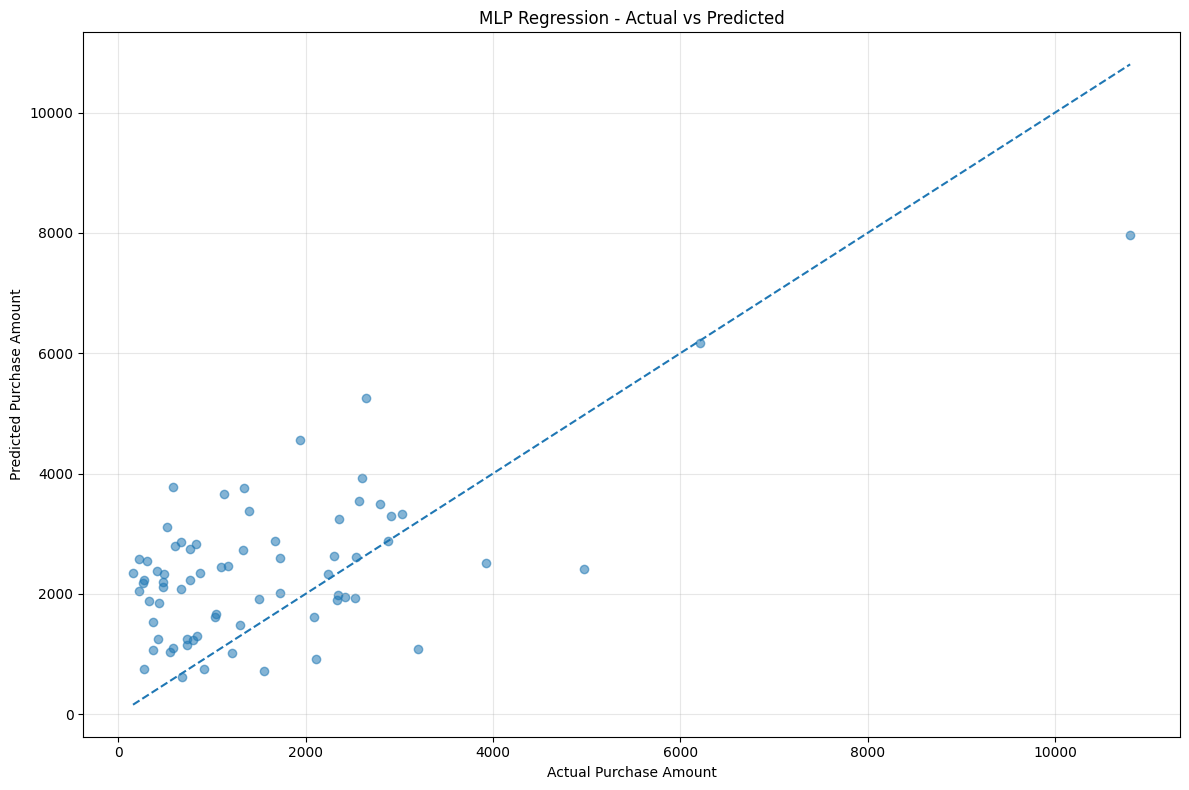

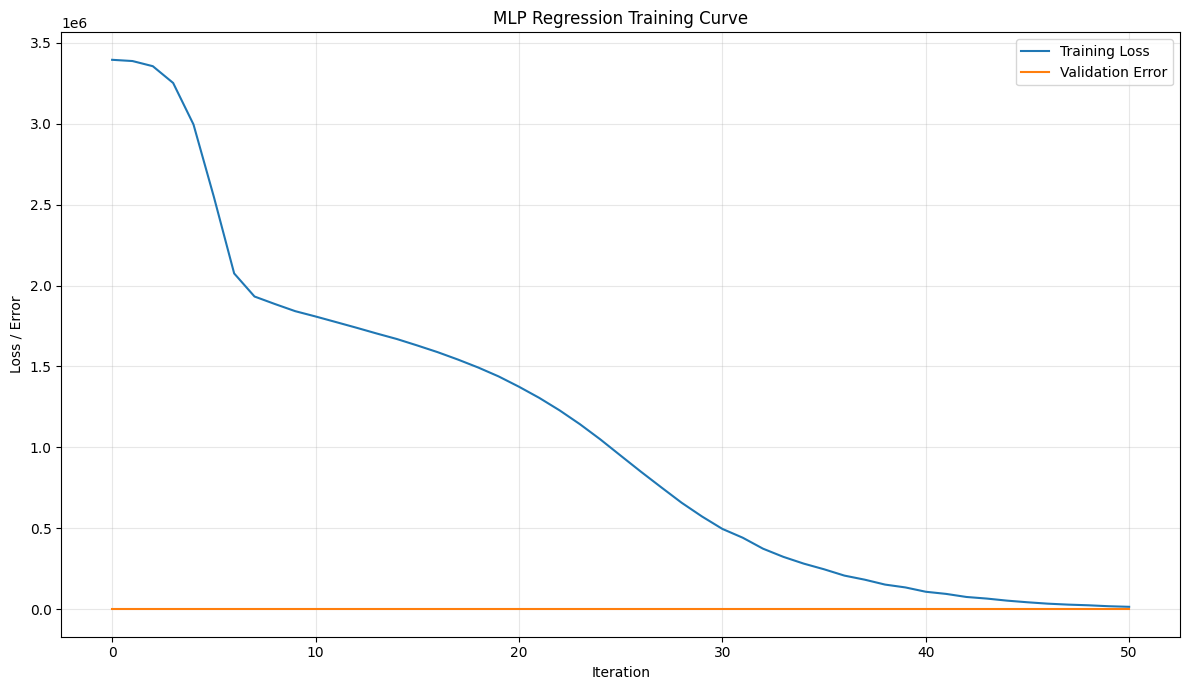



TRAINING INFORMATION

Classification iterations: 66
Classification final loss: 0.00034048286829101995
Regression iterations: 51
Regression final loss: 15027.9624768052


SAVING MODELS

Models saved successfully.


MLP FINAL SUMMARY

╔══════════════════════════════════════════════════════════════╗
║                  MLP CLASSIFICATION                         ║
╠══════════════════════════════════════════════════════════════╣

║ Accuracy           :    59.15%                    ║
║ Precision          :   0.6815                     ║
║ Recall             :   0.5915                     ║
║ F1 Score           :   0.6022                     ║
║ MCC                :   0.5503                     ║
║ Cohen Kappa        :   0.5416                     ║
╚══════════════════════════════════════════════════════════════╝

╔══════════════════════════════════════════════════════════════╗
║                    MLP REGRESSION                            ║
╠═════════════════════════════════════════════════

In [84]:
# ================================================================
# 35. MULTILAYER PERCEPTRON (MLP)
# Shopping Prediction Project
#
# Classification:
#   Target = next_purchase_category
#
# Regression:
#   Target = next_purchase_amount
#
# Includes:
#   - Data loading
#   - Feature preprocessing
#   - MLP Classification
#   - MLP Regression
#   - Printed architecture diagrams
#   - Printed pipeline diagram
#   - Training curves
#   - Confusion matrix
#   - Regression prediction graph
#   - Comprehensive metrics
#   - Model saving
# ================================================================


# ================================================================
# 1. IMPORT LIBRARIES
# ================================================================

import os
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    LabelEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.neural_network import MLPClassifier
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    log_loss,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    explained_variance_score,
    median_absolute_error
)

from sklearn.metrics import roc_auc_score


# ================================================================
# 2. CONFIGURATION
# ================================================================

RANDOM_STATE = 42

BASE_DIR = Path("/content")

PROCESSED_DIR = BASE_DIR / "feature_data"


GRAPH_DIR = BASE_DIR / "graphs"

MODEL_DIR = BASE_DIR / "models"

RESULT_DIR = BASE_DIR / "model_results"

MLP_GRAPH_DIR = GRAPH_DIR / "mlp"

MLP_RESULT_DIR = RESULT_DIR / "mlp"


# Create directories

for directory in [
    GRAPH_DIR,
    MODEL_DIR,
    RESULT_DIR,
    MLP_GRAPH_DIR,
    MLP_RESULT_DIR
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# ================================================================
# 3. FILE LOCATIONS
# ================================================================

FEATURE_FILE = (
    PROCESSED_DIR /
    "shopping_features.csv"
)

TRAIN_FILE = (
    PROCESSED_DIR /
    "train.csv"
)

VALIDATION_FILE = (
    PROCESSED_DIR /
    "validation.csv"
)

TEST_FILE = (
    PROCESSED_DIR /
    "test.csv"
)

RAW_FILE = (
    BASE_DIR /
    "raw" /
    "shopping_events.csv"
)


# ================================================================
# 4. PRINT HEADER
# ================================================================

print("\n")
print("=" * 80)
print(" " * 25 + "MULTILAYER PERCEPTRON")
print("=" * 80)

print("""
MLP Neural Network for Shopping Prediction

Classification:
    next_purchase_category

Regression:
    next_purchase_amount

Model:
    Multilayer Perceptron Neural Network
""")

print("=" * 80)


# ================================================================
# 5. PRINT MLP ARCHITECTURE DIAGRAM
# ================================================================

print("\n")
print("=" * 80)
print("MLP ARCHITECTURE")
print("=" * 80)

print(r"""
                    MULTILAYER PERCEPTRON
                    ====================

                         INPUT LAYER
                    ┌───────────────────┐
                    │   Feature 1       │
                    │   Feature 2       │
                    │   Feature 3       │
                    │       ...         │
                    │   Feature N       │
                    └─────────┬─────────┘
                              │
                              ▼
                    ┌───────────────────┐
                    │   HIDDEN LAYER 1  │
                    │                   │
                    │      ● ● ● ●      │
                    │      ● ● ● ●      │
                    │      ● ● ● ●      │
                    │      ● ● ● ●      │
                    └─────────┬─────────┘
                              │
                         ReLU Activation
                              │
                              ▼
                    ┌───────────────────┐
                    │   HIDDEN LAYER 2  │
                    │                   │
                    │       ● ● ●       │
                    │       ● ● ●       │
                    │       ● ● ●       │
                    │       ● ● ●       │
                    └─────────┬─────────┘
                              │
                         ReLU Activation
                              │
                              ▼
                    ┌───────────────────┐
                    │   OUTPUT LAYER    │
                    │                   │
                    │ Classification    │
                    │        ↓          │
                    │   Categories      │
                    │                   │
                    │ Regression        │
                    │        ↓          │
                    │ Purchase Amount   │
                    └───────────────────┘


                Forward Propagation
                       ↓
                Prediction
                       ↓
                Loss Calculation
                       ↓
                Backpropagation
                       ↓
                Weight Update
                       ↓
                Repeat
""")


# ================================================================
# 6. PRINT DATA PIPELINE
# ================================================================

print("\n")
print("=" * 80)
print("DATA PROCESSING PIPELINE")
print("=" * 80)

print(r"""
┌──────────────────────────────┐
│       Shopping Dataset       │
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│      Load Train / Test       │
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│      Remove Target Leakage   │
│      IDs / Timestamp         │
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│      Missing Value Handling  │
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│ Numeric → Scaling            │
│ Categorical → One-Hot        │
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│       MLP Neural Network     │
└──────────────┬───────────────┘
               │
          ┌────┴────┐
          ▼         ▼
   Classification Regression
          │         │
          ▼         ▼
     Category     Amount
     Prediction   Prediction
""")


# ================================================================
# 7. LOAD DATA
# ================================================================

print("\n")
print("=" * 80)
print("LOADING DATA")
print("=" * 80)


if TRAIN_FILE.exists():

    print(
        f"\nLoading training data:\n{TRAIN_FILE}"
    )

    train_df = pd.read_csv(TRAIN_FILE)

else:

    raise FileNotFoundError(
        f"""
Training dataset not found.

Expected:
{TRAIN_FILE}

Please make sure the processed shopping dataset
has been uploaded/extracted.
"""
    )


if VALIDATION_FILE.exists():

    print(
        f"Loading validation data:\n{VALIDATION_FILE}"
    )

    validation_df = pd.read_csv(
        VALIDATION_FILE
    )

else:

    validation_df = None

    print(
        "Validation dataset not found."
    )


if TEST_FILE.exists():

    print(
        f"Loading test data:\n{TEST_FILE}"
    )

    test_df = pd.read_csv(TEST_FILE)

else:

    raise FileNotFoundError(
        f"""
Test dataset not found.

Expected:
{TEST_FILE}
"""
    )


print("\nTrain shape:")
print(train_df.shape)

print("\nValidation shape:")
if validation_df is not None:
    print(validation_df.shape)
else:
    print("Not available")

print("\nTest shape:")
print(test_df.shape)


# ================================================================
# 8. TARGET DEFINITIONS
# ================================================================

CLASSIFICATION_TARGET = (
    "next_purchase_category"
)

REGRESSION_TARGET = (
    "next_purchase_amount"
)


# ================================================================
# 9. CHECK TARGETS
# ================================================================

print("\n")
print("=" * 80)
print("CHECKING TARGET COLUMNS")
print("=" * 80)

print(
    "\nClassification target:",
    CLASSIFICATION_TARGET
)

print(
    "Regression target:",
    REGRESSION_TARGET
)


if CLASSIFICATION_TARGET not in train_df.columns:

    raise ValueError(
        f"""
Classification target not found:

{CLASSIFICATION_TARGET}

Available columns:
{train_df.columns.tolist()}
"""
    )


if REGRESSION_TARGET not in train_df.columns:

    raise ValueError(
        f"""
Regression target not found:

{REGRESSION_TARGET}

Available columns:
{train_df.columns.tolist()}
"""
    )


# ================================================================
# 10. REMOVE TARGET LEAKAGE
# ================================================================

DROP_COLUMNS = [

    # Targets
    CLASSIFICATION_TARGET,
    REGRESSION_TARGET,

    # Common identifiers
    "event_id",
    "user_id",
    "product_id",

    # Timestamp
    "timestamp",
    "event_time",
    "datetime",
    "date",

    # Future information
    "next_purchase_time",
    "next_purchase_date",
    "future_purchase_amount",
    "future_purchase_category"
]


def prepare_features(df):

    X = df.copy()

    columns_to_drop = [
        col
        for col in DROP_COLUMNS
        if col in X.columns
    ]

    X = X.drop(
        columns=columns_to_drop,
        errors="ignore"
    )

    return X


X_train = prepare_features(train_df)

X_test = prepare_features(test_df)


# ================================================================
# 11. TARGET DATA
# ================================================================

y_train_classification = (
    train_df[
        CLASSIFICATION_TARGET
    ].astype(str)
)

y_test_classification = (
    test_df[
        CLASSIFICATION_TARGET
    ].astype(str)
)


y_train_regression = pd.to_numeric(
    train_df[
        REGRESSION_TARGET
    ],
    errors="coerce"
)

y_test_regression = pd.to_numeric(
    test_df[
        REGRESSION_TARGET
    ],
    errors="coerce"
)


# ================================================================
# 12. REMOVE INVALID REGRESSION TARGETS
# ================================================================

train_regression_mask = (
    y_train_regression.notna()
)

test_regression_mask = (
    y_test_regression.notna()
)


X_train_reg = X_train.loc[
    train_regression_mask
].copy()

y_train_regression = (
    y_train_regression[
        train_regression_mask
    ]
)


X_test_reg = X_test.loc[
    test_regression_mask
].copy()

y_test_regression = (
    y_test_regression[
        test_regression_mask
    ]
)


# ================================================================
# 13. IDENTIFY NUMERIC / CATEGORICAL FEATURES
# ================================================================

numeric_features = (
    X_train.select_dtypes(
        include=np.number
    ).columns.tolist()
)

categorical_features = (
    X_train.select_dtypes(
        exclude=np.number
    ).columns.tolist()
)


print("\n")
print("=" * 80)
print("FEATURE INFORMATION")
print("=" * 80)

print(
    "\nNumeric features:",
    len(numeric_features)
)

print(
    "Categorical features:",
    len(categorical_features)
)

print("\nNumeric columns:")

for column in numeric_features:
    print("  -", column)

print("\nCategorical columns:")

for column in categorical_features:
    print("  -", column)


# ================================================================
# 14. PREPROCESSOR
# ================================================================

numeric_pipeline = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",
            StandardScaler()
        )

    ]
)


categorical_pipeline = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )

    ]
)


preprocessor = ColumnTransformer(

    transformers=[

        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),

        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )

    ],

    remainder="drop"

)


# ================================================================
# 15. TRANSFORM DATA
# ================================================================

print("\n")
print("=" * 80)
print("PREPROCESSING DATA")
print("=" * 80)


X_train_processed = (
    preprocessor.fit_transform(
        X_train
    )
)

X_test_processed = (
    preprocessor.transform(
        X_test
    )
)


X_train_reg_processed = (
    preprocessor.transform(
        X_train_reg
    )
)

X_test_reg_processed = (
    preprocessor.transform(
        X_test_reg
    )
)


print(
    "\nOriginal feature count:",
    X_train.shape[1]
)

print(
    "Processed feature count:",
    X_train_processed.shape[1]
)


# ================================================================
# 16. PRINT FINAL MLP ARCHITECTURE
# ================================================================

INPUT_SIZE = (
    X_train_processed.shape[1]
)

CLASS_COUNT = (
    y_train_classification.nunique()
)


print("\n")
print("=" * 80)
print("ACTUAL MLP ARCHITECTURE")
print("=" * 80)

print(f"""
Input Layer
    │
    ├── {INPUT_SIZE} input features
    │
    ▼
Hidden Layer 1
    │
    ├── 256 neurons
    ├── ReLU
    │
    ▼
Hidden Layer 2
    │
    ├── 128 neurons
    ├── ReLU
    │
    ▼
Hidden Layer 3
    │
    ├── 64 neurons
    ├── ReLU
    │
    ▼
Output Layer
    │
    ├── Classification: {CLASS_COUNT} neurons
    │
    └── Regression: 1 neuron
""")


# ================================================================
# 17. MLP CLASSIFICATION
# ================================================================

print("\n")
print("=" * 80)
print("35A. MLP CLASSIFICATION")
print("=" * 80)


# ------------------------------------------------
# Encode classification labels
# ------------------------------------------------

label_encoder = LabelEncoder()

y_train_encoded = (
    label_encoder.fit_transform(
        y_train_classification
    )
)


# Test labels that were not seen during training

test_classification_mask = (
    y_test_classification.isin(
        label_encoder.classes_
    )
)


X_test_class_processed = (
    X_test_processed[
        test_classification_mask.values
    ]
)

y_test_encoded = (
    label_encoder.transform(
        y_test_classification[
            test_classification_mask
        ]
    )
)


print(
    "\nNumber of classes:",
    len(label_encoder.classes_)
)

print("\nClasses:")

for i, cls in enumerate(
    label_encoder.classes_
):

    print(
        f"  {i}: {cls}"
    )


# ------------------------------------------------
# Build classifier
# ------------------------------------------------

mlp_classifier = MLPClassifier(

    hidden_layer_sizes=(
        256,
        128,
        64
    ),

    activation="relu",

    solver="adam",

    alpha=0.0001,

    batch_size=256,

    learning_rate_init=0.001,

    max_iter=100,

    early_stopping=True,

    validation_fraction=0.15,

    n_iter_no_change=10,

    random_state=RANDOM_STATE,

    verbose=True

)


# ------------------------------------------------
# Train
# ------------------------------------------------

print("\nTraining MLP classifier...\n")

mlp_classifier.fit(
    X_train_processed,
    y_train_encoded
)


# ================================================================
# 18. CLASSIFICATION PREDICTION
# ================================================================

classification_predictions = (
    mlp_classifier.predict(
        X_test_class_processed
    )
)

classification_probabilities = (
    mlp_classifier.predict_proba(
        X_test_class_processed
    )
)


# ================================================================
# 19. CLASSIFICATION METRICS
# ================================================================

classification_accuracy = (
    accuracy_score(
        y_test_encoded,
        classification_predictions
    )
)

classification_balanced_accuracy = (
    balanced_accuracy_score(
        y_test_encoded,
        classification_predictions
    )
)

classification_precision = (
    precision_score(
        y_test_encoded,
        classification_predictions,
        average="weighted",
        zero_division=0
    )
)

classification_recall = (
    recall_score(
        y_test_encoded,
        classification_predictions,
        average="weighted",
        zero_division=0
    )
)

classification_f1 = (
    f1_score(
        y_test_encoded,
        classification_predictions,
        average="weighted",
        zero_division=0
    )
)

classification_mcc = (
    matthews_corrcoef(
        y_test_encoded,
        classification_predictions
    )
)

classification_kappa = (
    cohen_kappa_score(
        y_test_encoded,
        classification_predictions
    )
)


try:

    classification_log_loss = (
        log_loss(
            y_test_encoded,
            classification_probabilities
        )
    )

except Exception:

    classification_log_loss = np.nan


try:

    classification_auc = (
        roc_auc_score(
            y_test_encoded,
            classification_probabilities,
            multi_class="ovr",
            average="weighted"
        )
    )

except Exception:

    classification_auc = np.nan


# ================================================================
# 20. PRINT CLASSIFICATION RESULTS
# ================================================================

print("\n")
print("=" * 80)
print("MLP CLASSIFICATION RESULTS")
print("=" * 80)

print(
    f"\nAccuracy             : "
    f"{classification_accuracy:.4f}"
)

print(
    f"Accuracy (%)         : "
    f"{classification_accuracy * 100:.2f}%"
)

print(
    f"Balanced Accuracy    : "
    f"{classification_balanced_accuracy:.4f}"
)

print(
    f"Precision             : "
    f"{classification_precision:.4f}"
)

print(
    f"Recall                : "
    f"{classification_recall:.4f}"
)

print(
    f"F1 Score              : "
    f"{classification_f1:.4f}"
)

print(
    f"MCC                   : "
    f"{classification_mcc:.4f}"
)

print(
    f"Cohen Kappa           : "
    f"{classification_kappa:.4f}"
)

print(
    f"ROC-AUC               : "
    f"{classification_auc:.4f}"
)

print(
    f"Log Loss              : "
    f"{classification_log_loss:.4f}"
)


# ================================================================
# 21. CLASSIFICATION REPORT
# ================================================================

print("\n")
print("=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        y_test_encoded,
        classification_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)


# ================================================================
# 22. CONFUSION MATRIX
# ================================================================

confusion = confusion_matrix(
    y_test_encoded,
    classification_predictions
)


plt.figure(
    figsize=(12, 9)
)

sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel(
    "Predicted Category"
)

plt.ylabel(
    "Actual Category"
)

plt.title(
    "MLP Classification - Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    MLP_GRAPH_DIR /
    "35_MLP_Classification_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ================================================================
# 23. MLP CLASSIFICATION TRAINING CURVE
# ================================================================

plt.figure(
    figsize=(12, 7)
)

plt.plot(
    mlp_classifier.loss_curve_,
    label="Training Loss"
)

if hasattr(
    mlp_classifier,
    "validation_scores_"
):

    validation_loss = [
        1 - score
        for score
        in mlp_classifier.validation_scores_
    ]

    plt.plot(
        validation_loss,
        label="Validation Error"
    )


plt.xlabel(
    "Iteration"
)

plt.ylabel(
    "Loss / Error"
)

plt.title(
    "MLP Classification Training Curve"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    MLP_GRAPH_DIR /
    "35_MLP_Classification_Training_Curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ================================================================
# 24. REGRESSION MLP
# ================================================================

print("\n")
print("=" * 80)
print("35B. MLP REGRESSION")
print("=" * 80)


mlp_regressor = MLPRegressor(

    hidden_layer_sizes=(
        256,
        128,
        64
    ),

    activation="relu",

    solver="adam",

    alpha=0.0001,

    batch_size=256,

    learning_rate_init=0.001,

    max_iter=100,

    early_stopping=True,

    validation_fraction=0.15,

    n_iter_no_change=10,

    random_state=RANDOM_STATE,

    verbose=True

)


print(
    "\nTraining MLP regression model...\n"
)


mlp_regressor.fit(
    X_train_reg_processed,
    y_train_regression
)


# ================================================================
# 25. REGRESSION PREDICTION
# ================================================================

regression_predictions = (
    mlp_regressor.predict(
        X_test_reg_processed
    )
)


# ================================================================
# 26. REGRESSION METRICS
# ================================================================

mae = mean_absolute_error(
    y_test_regression,
    regression_predictions
)

mse = mean_squared_error(
    y_test_regression,
    regression_predictions
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test_regression,
    regression_predictions
)

explained_variance = (
    explained_variance_score(
        y_test_regression,
        regression_predictions
    )
)

median_absolute_error_value = (
    median_absolute_error(
        y_test_regression,
        regression_predictions
    )
)


# MAPE

non_zero_mask = (
    y_test_regression != 0
)

if non_zero_mask.sum() > 0:

    mape = np.mean(
        np.abs(
            (
                y_test_regression[
                    non_zero_mask
                ].values
                -
                regression_predictions[
                    non_zero_mask
                ]
            )
            /
            y_test_regression[
                non_zero_mask
            ].values
        )
    ) * 100

else:

    mape = np.nan


accuracy_like = (
    max(
        0,
        100 - mape
    )
    if not np.isnan(mape)
    else np.nan
)


# ================================================================
# 27. PRINT REGRESSION RESULTS
# ================================================================

print("\n")
print("=" * 80)
print("MLP REGRESSION RESULTS")
print("=" * 80)

print(
    f"\nMAE                  : "
    f"{mae:.4f}"
)

print(
    f"MSE                  : "
    f"{mse:.4f}"
)

print(
    f"RMSE                 : "
    f"{rmse:.4f}"
)

print(
    f"R² Score             : "
    f"{r2:.4f}"
)

print(
    f"Explained Variance   : "
    f"{explained_variance:.4f}"
)

print(
    f"Median Absolute Error: "
    f"{median_absolute_error_value:.4f}"
)

print(
    f"MAPE                 : "
    f"{mape:.2f}%"
)

print(
    f"Accuracy-like Score  : "
    f"{accuracy_like:.2f}%"
)

print(
    "\nNote:"
)

print(
    "Regression does not have standard classification accuracy."
)

print(
    "Accuracy-like Score = 100 - MAPE."
)


# ================================================================
# 28. ACTUAL VS PREDICTED
# ================================================================

plt.figure(
    figsize=(12, 8)
)

plt.scatter(
    y_test_regression,
    regression_predictions,
    alpha=0.55
)

minimum = min(
    y_test_regression.min(),
    regression_predictions.min()
)

maximum = max(
    y_test_regression.max(),
    regression_predictions.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel(
    "Actual Purchase Amount"
)

plt.ylabel(
    "Predicted Purchase Amount"
)

plt.title(
    "MLP Regression - Actual vs Predicted"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    MLP_GRAPH_DIR /
    "35_MLP_Regression_Actual_vs_Predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ================================================================
# 29. REGRESSION TRAINING CURVE
# ================================================================

plt.figure(
    figsize=(12, 7)
)

plt.plot(
    mlp_regressor.loss_curve_,
    label="Training Loss"
)

if hasattr(
    mlp_regressor,
    "validation_scores_"
):

    validation_loss = [
        1 - score
        for score
        in mlp_regressor.validation_scores_
    ]

    plt.plot(
        validation_loss,
        label="Validation Error"
    )


plt.xlabel(
    "Iteration"
)

plt.ylabel(
    "Loss / Error"
)

plt.title(
    "MLP Regression Training Curve"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    MLP_GRAPH_DIR /
    "35_MLP_Regression_Training_Curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ================================================================
# 30. PRINT TRAINING INFORMATION
# ================================================================

print("\n")
print("=" * 80)
print("TRAINING INFORMATION")
print("=" * 80)

print(
    "\nClassification iterations:",
    mlp_classifier.n_iter_
)

print(
    "Classification final loss:",
    mlp_classifier.loss_
)

print(
    "Regression iterations:",
    mlp_regressor.n_iter_
)

print(
    "Regression final loss:",
    mlp_regressor.loss_
)


# ================================================================
# 31. SAVE MODELS
# ================================================================

print("\n")
print("=" * 80)
print("SAVING MODELS")
print("=" * 80)


joblib.dump(
    mlp_classifier,
    MODEL_DIR /
    "35_MLP_Classifier.joblib"
)

joblib.dump(
    mlp_regressor,
    MODEL_DIR /
    "35_MLP_Regressor.joblib"
)

joblib.dump(
    preprocessor,
    MODEL_DIR /
    "35_MLP_Preprocessor.joblib"
)

joblib.dump(
    label_encoder,
    MODEL_DIR /
    "35_MLP_LabelEncoder.joblib"
)


print(
    "\nModels saved successfully."
)


# ================================================================
# 32. SAVE CLASSIFICATION RESULTS
# ================================================================

classification_results = pd.DataFrame({

    "Model": [
        "MLP"
    ],

    "Dataset": [
        "Test"
    ],

    "Accuracy": [
        classification_accuracy
    ],

    "Accuracy_%": [
        classification_accuracy * 100
    ],

    "Balanced_Accuracy": [
        classification_balanced_accuracy
    ],

    "Precision": [
        classification_precision
    ],

    "Recall": [
        classification_recall
    ],

    "F1": [
        classification_f1
    ],

    "MCC": [
        classification_mcc
    ],

    "Cohen_Kappa": [
        classification_kappa
    ],

    "ROC_AUC": [
        classification_auc
    ],

    "Log_Loss": [
        classification_log_loss
    ]

})


classification_results.to_csv(

    MLP_RESULT_DIR /
    "35_MLP_Classification_Results.csv",

    index=False

)


# ================================================================
# 33. SAVE REGRESSION RESULTS
# ================================================================

regression_results = pd.DataFrame({

    "Model": [
        "MLP"
    ],

    "Dataset": [
        "Test"
    ],

    "MAE": [
        mae
    ],

    "MSE": [
        mse
    ],

    "RMSE": [
        rmse
    ],

    "R2": [
        r2
    ],

    "Explained_Variance": [
        explained_variance
    ],

    "Median_Absolute_Error": [
        median_absolute_error_value
    ],

    "MAPE": [
        mape
    ],

    "Accuracy_like_%": [
        accuracy_like
    ]

})


regression_results.to_csv(

    MLP_RESULT_DIR /
    "35_MLP_Regression_Results.csv",

    index=False

)


# ================================================================
# 34. SAVE PREDICTIONS
# ================================================================

classification_prediction_output = pd.DataFrame({

    "Actual_Category":
        label_encoder.inverse_transform(
            y_test_encoded
        ),

    "Predicted_Category":
        label_encoder.inverse_transform(
            classification_predictions
        ),

    "Prediction_Confidence":
        classification_probabilities.max(
            axis=1
        )

})


classification_prediction_output.to_csv(

    MLP_RESULT_DIR /
    "35_MLP_Classification_Predictions.csv",

    index=False

)


regression_prediction_output = pd.DataFrame({

    "Actual_Amount":
        y_test_regression.values,

    "Predicted_Amount":
        regression_predictions,

    "Absolute_Error":
        np.abs(
            y_test_regression.values
            -
            regression_predictions
        )

})


regression_prediction_output.to_csv(

    MLP_RESULT_DIR /
    "35_MLP_Regression_Predictions.csv",

    index=False

)


# ================================================================
# 35. FINAL COMPARISON
# ================================================================

print("\n")
print("=" * 80)
print("MLP FINAL SUMMARY")
print("=" * 80)


print("""
╔══════════════════════════════════════════════════════════════╗
║                  MLP CLASSIFICATION                         ║
╠══════════════════════════════════════════════════════════════╣
""")

print(
    f"║ Accuracy           : {classification_accuracy * 100:>8.2f}%                    ║"
)

print(
    f"║ Precision          : {classification_precision:>8.4f}                     ║"
)

print(
    f"║ Recall             : {classification_recall:>8.4f}                     ║"
)

print(
    f"║ F1 Score           : {classification_f1:>8.4f}                     ║"
)

print(
    f"║ MCC                : {classification_mcc:>8.4f}                     ║"
)

print(
    f"║ Cohen Kappa        : {classification_kappa:>8.4f}                     ║"
)

print(
    "╚══════════════════════════════════════════════════════════════╝"
)


print("""
╔══════════════════════════════════════════════════════════════╗
║                    MLP REGRESSION                            ║
╠══════════════════════════════════════════════════════════════╣
""")

print(
    f"║ MAE                : {mae:>10.4f}                       ║"
)

print(
    f"║ RMSE               : {rmse:>10.4f}                       ║"
)

print(
    f"║ R²                 : {r2:>10.4f}                       ║"
)

print(
    f"║ MAPE               : {mape:>9.2f}%                       ║"
)

print(
    f"║ Accuracy-like      : {accuracy_like:>9.2f}%                       ║"
)

print(
    "╚══════════════════════════════════════════════════════════════╝"
)


# ================================================================
# 36. PRINT OUTPUT DIRECTORY
# ================================================================

print("\n")
print("=" * 80)
print("OUTPUT FILES")
print("=" * 80)

print(
    f"""
Models:
    {MODEL_DIR}/35_MLP_Classifier.joblib
    {MODEL_DIR}/35_MLP_Regressor.joblib
    {MODEL_DIR}/35_MLP_Preprocessor.joblib
    {MODEL_DIR}/35_MLP_LabelEncoder.joblib

Graphs:
    {MLP_GRAPH_DIR}/

Results:
    {MLP_RESULT_DIR}/
"""
)


print("\n")
print("=" * 80)
print("MLP TRAINING COMPLETED SUCCESSFULLY")
print("=" * 80)

#CNN

In [91]:
# ================================================================
# 36. CONVOLUTIONAL NEURAL NETWORK (1D CNN)
# SHOPPING PREDICTION PROJECT
#
# Classification:
#   next_purchase_category
#
# Regression:
#   next_purchase_amount
#
# ================================================================

import sys
import subprocess
import importlib.util

def install_if_missing(package, import_name=None):
    if import_name is None:
        import_name = package
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {package}...")
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            package
        ])

install_if_missing("tensorflow")
install_if_missing("scikit-learn")
install_if_missing("pandas")
install_if_missing("numpy")
install_if_missing("matplotlib")
install_if_missing("seaborn")
install_if_missing("joblib")

import os
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    BatchNormalization,
    Activation,
    MaxPooling1D,
    GlobalAveragePooling1D,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    LabelEncoder
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix,
    classification_report,
    log_loss,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    explained_variance_score,
    median_absolute_error
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

BASE_DIR = Path("/content")
DATA_DIR = BASE_DIR / "feature_data"
TRAIN_FILE = DATA_DIR / "train.csv"
VALIDATION_FILE = DATA_DIR / "validation.csv"
TEST_FILE = DATA_DIR / "test.csv"
FEATURE_FILE = DATA_DIR / "shopping_features.csv"

CNN_GRAPH_DIR = BASE_DIR / "cnn_graphs"
CNN_MODEL_DIR = BASE_DIR / "cnn_models"
CNN_RESULT_DIR = BASE_DIR / "cnn_results"

for directory in [CNN_GRAPH_DIR, CNN_MODEL_DIR, CNN_RESULT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

CLASSIFICATION_TARGET = "next_purchase_category"
REGRESSION_TARGET = "next_purchase_amount"

train_df = pd.read_csv(TRAIN_FILE)
test_df = pd.read_csv(TEST_FILE)
validation_df = pd.read_csv(VALIDATION_FILE) if VALIDATION_FILE.exists() else None

def find_column(df, names):
    lower_map = {col.lower(): col for col in df.columns}
    for name in names:
        if name.lower() in lower_map:
            return lower_map[name.lower()]
    return None

USER_COL = find_column(train_df, ["user_id", "user", "customer_id", "customer"])
if USER_COL is None:
    # Fallback search
    for col in train_df.columns:
        if "user" in col.lower() or "id" in col.lower():
            USER_COL = col
            break
if USER_COL is None:
    USER_COL = "user_id" # Absolute fallback

TIME_COL = find_column(train_df, ["timestamp", "event_time", "datetime", "date", "created_at"]) or "timestamp"

SEQUENCE_LENGTH = 10

def prepare_dataframe(df):
    data = df.copy()
    if TIME_COL in data.columns:
        data["_sequence_time"] = pd.to_datetime(data[TIME_COL], errors="coerce")
        sort_cols = [USER_COL, "_sequence_time"] if USER_COL in data.columns else ["_sequence_time"]
        data = data.sort_values(sort_cols)
    elif USER_COL in data.columns:
        data = data.sort_values(USER_COL)
    return data.reset_index(drop=True)

train_df = prepare_dataframe(train_df)
test_df = prepare_dataframe(test_df)

DROP_COLUMNS = [
    CLASSIFICATION_TARGET, REGRESSION_TARGET, "event_id", "product_id",
    "timestamp", "event_time", "datetime", "date", "created_at",
    "next_purchase_time", "next_purchase_date", "future_purchase_amount",
    "future_purchase_category"
]

def clean_features(df):
    data = df.copy()
    columns_to_remove = [col for col in DROP_COLUMNS if col in data.columns]
    return data.drop(columns=columns_to_remove, errors="ignore")

X_train_raw = clean_features(train_df)
X_test_raw = clean_features(test_df)
feature_cols_for_typing_train = X_train_raw.drop(columns=[USER_COL], errors="ignore")

numeric_features = feature_cols_for_typing_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = feature_cols_for_typing_train.select_dtypes(exclude=np.number).columns.tolist()

processed_parts_train = []
processed_parts_test = []

if len(numeric_features) > 0:
    numeric_train = X_train_raw[numeric_features].apply(pd.to_numeric, errors="coerce").fillna(0)
    numeric_test = X_test_raw[numeric_features].apply(pd.to_numeric, errors="coerce").fillna(0)
    scaler = StandardScaler()
    numeric_train_scaled = scaler.fit_transform(numeric_train)
    numeric_test_scaled = scaler.transform(numeric_test)
    processed_parts_train.append(numeric_train_scaled)
    processed_parts_test.append(numeric_test_scaled)
else:
    scaler = None

if len(categorical_features) > 0:
    categorical_train = X_train_raw[categorical_features].fillna("UNKNOWN").astype(str)
    categorical_test = X_test_raw[categorical_features].fillna("UNKNOWN").astype(str)
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    categorical_train_encoded = encoder.fit_transform(categorical_train)
    categorical_test_encoded = encoder.transform(categorical_test)
    processed_parts_train.append(categorical_train_encoded)
    processed_parts_test.append(categorical_test_encoded)
else:
    encoder = None

X_train_event = np.hstack(processed_parts_train)
X_test_event = np.hstack(processed_parts_test)

def create_sequences(df, processed_features, sequence_length, classification_target, regression_target):
    X_sequences, y_class, y_reg = [], [], []
    working_df = df.reset_index(drop=True)
    feature_matrix = processed_features
    for user_id, group in working_df.groupby(USER_COL, sort=False):
        indices = group.index.tolist()
        if len(indices) <= sequence_length:
            continue
        for position in range(sequence_length, len(indices)):
            X_sequences.append(feature_matrix[indices[position - sequence_length:position]])
            y_class.append(working_df.loc[indices[position], classification_target])
            y_reg.append(working_df.loc[indices[position], regression_target])
    return np.asarray(X_sequences), np.asarray(y_class), np.asarray(y_reg)

X_train_seq, y_train_class_raw, y_train_reg_raw = create_sequences(
    train_df, X_train_event, SEQUENCE_LENGTH, CLASSIFICATION_TARGET, REGRESSION_TARGET
)

X_test_seq, y_test_class_raw, y_test_reg_raw = create_sequences(
    test_df, X_test_event, SEQUENCE_LENGTH, CLASSIFICATION_TARGET, REGRESSION_TARGET
)

y_train_reg_raw = pd.to_numeric(y_train_reg_raw, errors="coerce")
y_test_reg_raw = pd.to_numeric(y_test_reg_raw, errors="coerce")
train_reg_mask = ~np.isnan(y_train_reg_raw)
test_reg_mask = ~np.isnan(y_test_reg_raw)

X_train_reg_seq = X_train_seq[train_reg_mask]
y_train_reg = y_train_reg_raw[train_reg_mask]
X_test_reg_seq = X_test_seq[test_reg_mask]
y_test_reg = y_test_reg_raw[test_reg_mask]

label_encoder = LabelEncoder()
y_train_class = label_encoder.fit_transform(y_train_class_raw.astype(str))
test_class_strings = y_test_class_raw.astype(str)
known_classes_mask = np.isin(test_class_strings, label_encoder.classes_)
X_test_class_seq = X_test_seq[known_classes_mask]
y_test_class = label_encoder.transform(test_class_strings[known_classes_mask])

NUM_CLASSES = len(label_encoder.classes_)
NUM_FEATURES = X_train_seq.shape[2]

def build_cnn_classifier(sequence_length, num_features, num_classes):
    model = Sequential([
        Input(shape=(sequence_length, num_features)),
        Conv1D(filters=64, kernel_size=3, padding="same"),
        BatchNormalization(),
        Activation("relu"),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=128, kernel_size=3, padding="same"),
        BatchNormalization(),
        Activation("relu"),
        GlobalAveragePooling1D(),
        Dense(128, activation="relu"),
        Dropout(0.30),
        Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

cnn_classifier = build_cnn_classifier(SEQUENCE_LENGTH, NUM_FEATURES, NUM_CLASSES)
classifier_checkpoint = CNN_MODEL_DIR / "36_CNN_Classifier.keras"
classifier_callbacks = [
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6),
    ModelCheckpoint(filepath=str(classifier_checkpoint), monitor="val_loss", save_best_only=True)
]

history_classifier = cnn_classifier.fit(
    X_train_seq, y_train_class, validation_split=0.15,
    epochs=50, batch_size=256, callbacks=classifier_callbacks, verbose=1
)

class_probabilities = cnn_classifier.predict(X_test_class_seq, verbose=0)
class_predictions = np.argmax(class_probabilities, axis=1)

accuracy = accuracy_score(y_test_class, class_predictions)
balanced_accuracy = balanced_accuracy_score(y_test_class, class_predictions)
precision = precision_score(y_test_class, class_predictions, average="weighted", zero_division=0)
recall = recall_score(y_test_class, class_predictions, average="weighted", zero_division=0)
f1 = f1_score(y_test_class, class_predictions, average="weighted", zero_division=0)
mcc = matthews_corrcoef(y_test_class, class_predictions)
kappa = cohen_kappa_score(y_test_class, class_predictions)

try:
    cnn_log_loss = log_loss(y_test_class, class_probabilities)
except Exception:
    cnn_log_loss = np.nan
try:
    cnn_auc = roc_auc_score(y_test_class, class_probabilities, multi_class="ovr", average="weighted")
except Exception:
    cnn_auc = np.nan

print("\n" + "=" * 90)
print("CNN CLASSIFICATION RESULTS")
print("=" * 90)
print(f"Accuracy             : {accuracy:.4f}")
print(f"Precision            : {precision:.4f}")
print(f"Recall               : {recall:.4f}")
print(f"F1 Score             : {f1:.4f}")
print(f"MCC                  : {mcc:.4f}")
print(f"Cohen Kappa          : {kappa:.4f}")
print(f"ROC-AUC              : {cnn_auc:.4f}")
print(f"Log Loss             : {cnn_log_loss:.4f}")


Installing scikit-learn...


IndexError: tuple index out of range

#RNN

RNN SHOPPING PREDICTION SYSTEM

TensorFlow version: 2.20.0

Data directory:
/content/feature_data

Output directory:
/content/rnn_results


RNN MODEL ARCHITECTURE

        ┌───────────────────────────────────────────────┐
        │           INPUT SEQUENCE                      │
        │                                               │
        │  Previous 10 Shopping Events                  │
        │  Shape: (10, number_of_features)              │
        └──────────────────────┬────────────────────────┘
                               │
                               ▼
        ┌───────────────────────────────────────────────┐
        │                SIMPLE RNN                      │
        │                                               │
        │  Units = 128                                  │
        │  Activation = tanh                            │
        │  return_sequences = True                      │
        └──────────────────────┬────────────────────────┘
               

Model: "RNN_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 10, 128)        │       740,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 762,442 (2.91 MB)

 Trainable params: 762,442 (2.91 MB)

 Non-trainable params: 0 (0.00 B)



TRAINING RNN CLASSIFIER
Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.0998 - loss: 2.3800
Epoch 1: val_loss improved from None to 2.29728, saving model to /content/rnn_results/models/rnn_classifier_best.keras

Epoch 1: finished saving model to /content/rnn_results/models/rnn_classifier_best.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 16s 657ms/step - accuracy: 0.1013 - loss: 2.3727 - val_accuracy: 0.1282 - val_loss: 2.2973 - learning_rate: 0.0010
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.2014 - loss: 2.1866
Epoch 2: val_loss did not improve from 2.29728
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 541ms/step - accuracy: 0.1902 - loss: 2.2077 - val_accuracy: 0.0916 - val_loss: 2.3147 - learning_rate: 0.0010
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.2804 - loss: 2.0899
Epoch 3: val_loss did not improve from 2.29728
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 452ms/step - accuracy: 0.2654 - loss: 2.1010 - val_accuracy: 0.0879 - val_loss: 2.3691 - learning_rat

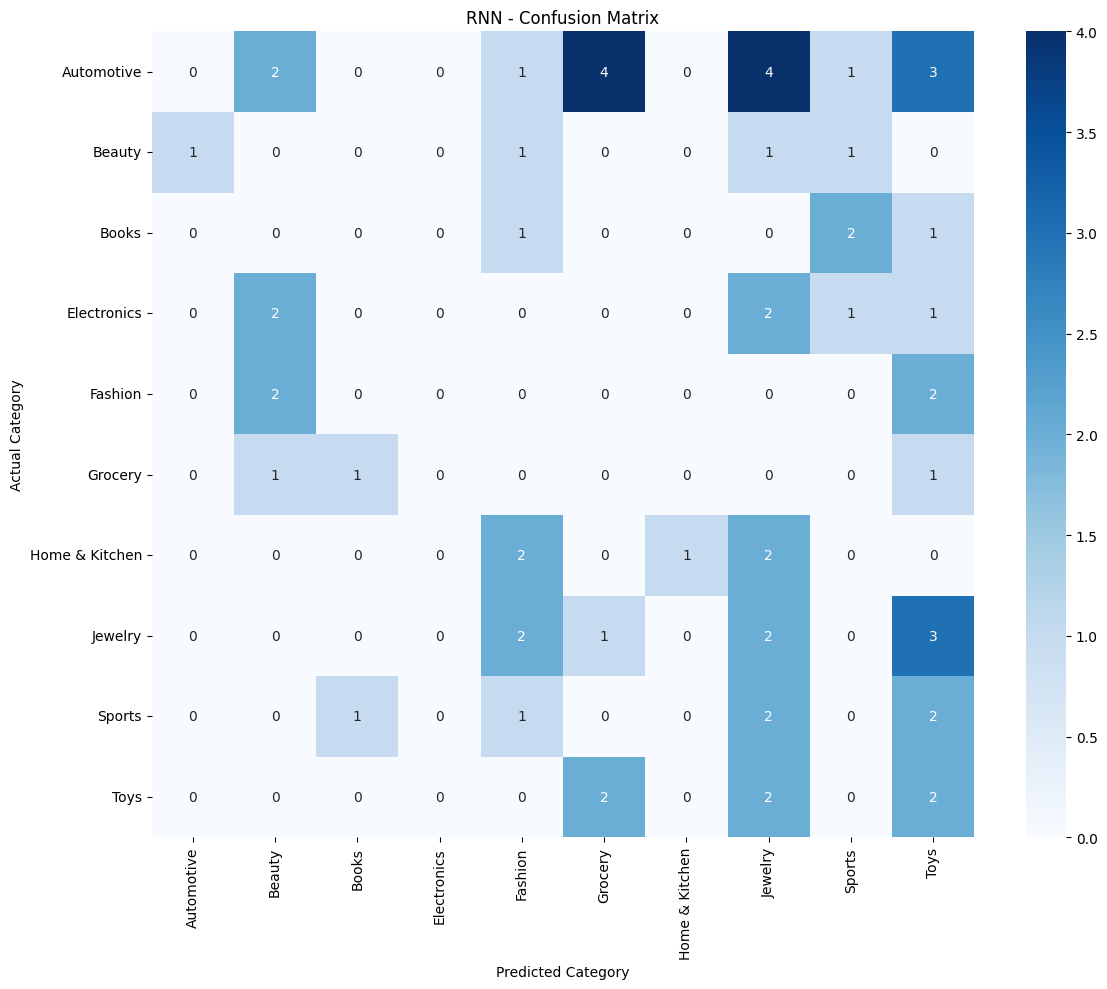

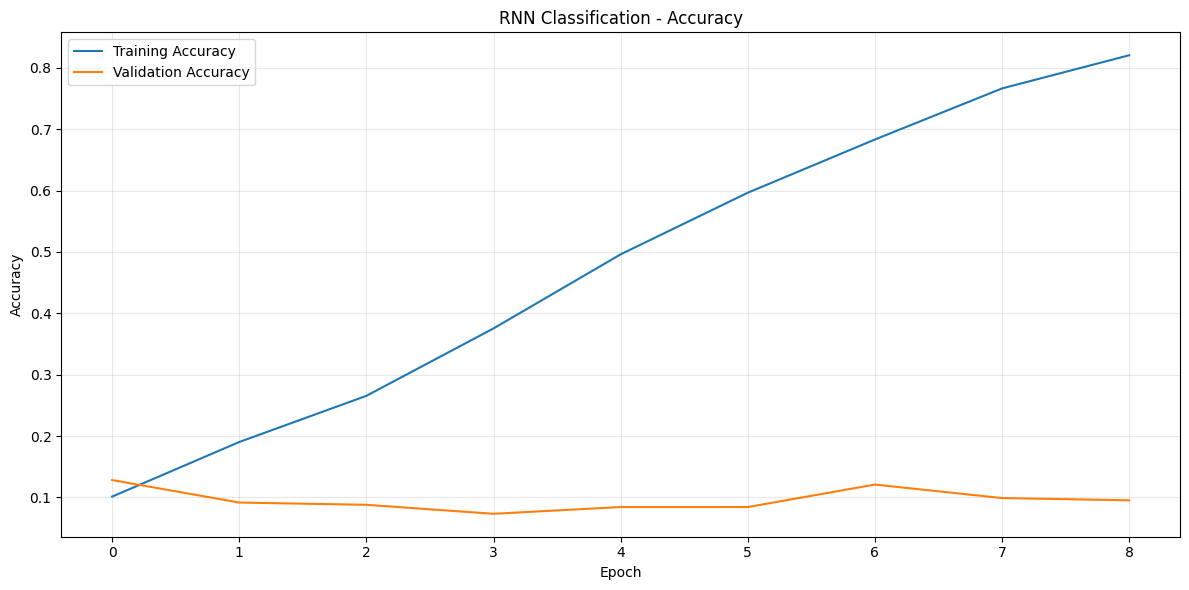

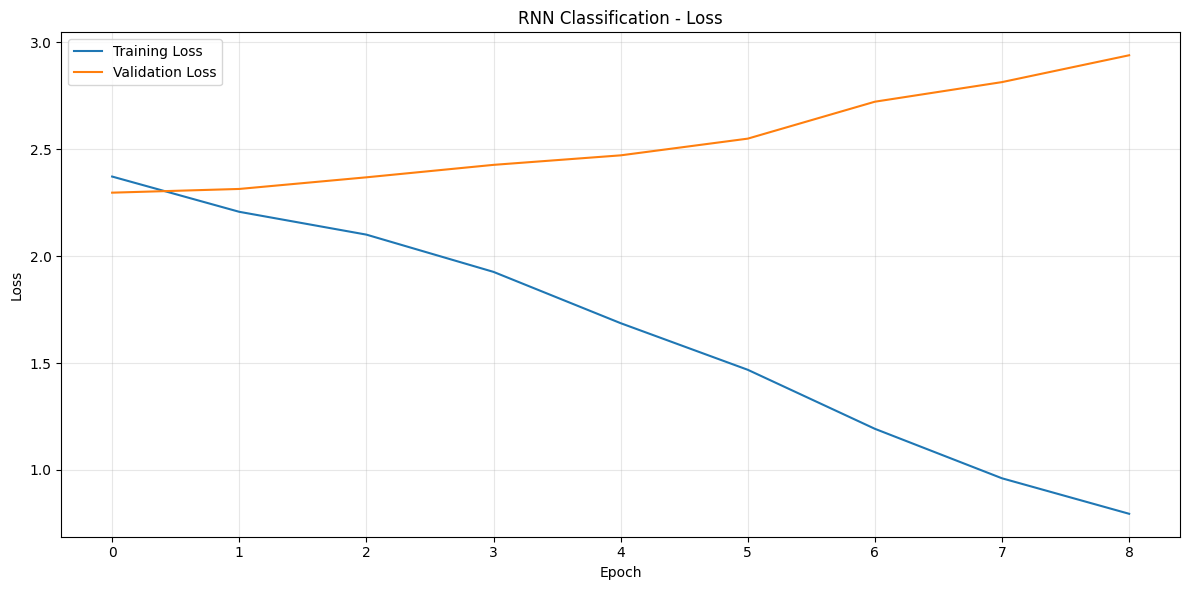



RNN REGRESSION MODEL


Model: "RNN_Regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 10, 128)        │       740,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 761,281 (2.90 MB)

 Trainable params: 761,281 (2.90 MB)

 Non-trainable params: 0 (0.00 B)



TRAINING RNN REGRESSOR
Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - loss: 6709820.6071 - mae: 1663.1735
Epoch 1: val_loss improved from None to 6341964.00000, saving model to /content/rnn_results/models/rnn_regressor_best.keras

Epoch 1: finished saving model to /content/rnn_results/models/rnn_regressor_best.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 362ms/step - loss: 6895762.0000 - mae: 1673.6992 - val_loss: 6341964.0000 - val_mae: 1667.6522 - learning_rate: 0.0010
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - loss: 6684529.6786 - mae: 1655.5325
Epoch 2: val_loss improved from 6341964.00000 to 6311651.00000, saving model to /content/rnn_results/models/rnn_regressor_best.keras

Epoch 2: finished saving model to /content/rnn_results/models/rnn_regressor_best.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 239ms/step - loss: 6867851.5000 - mae: 1665.3131 - val_loss: 6311651.0000 - val_mae: 1658.5316 - learning_rate: 0.0010
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - loss: 6653

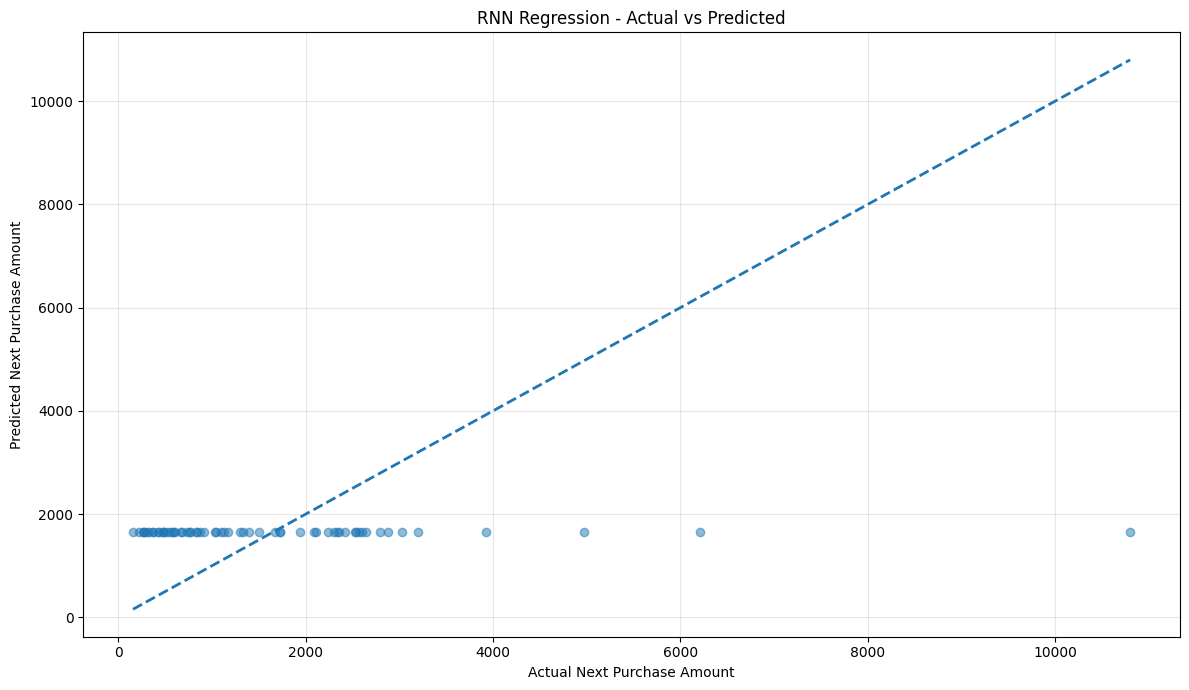

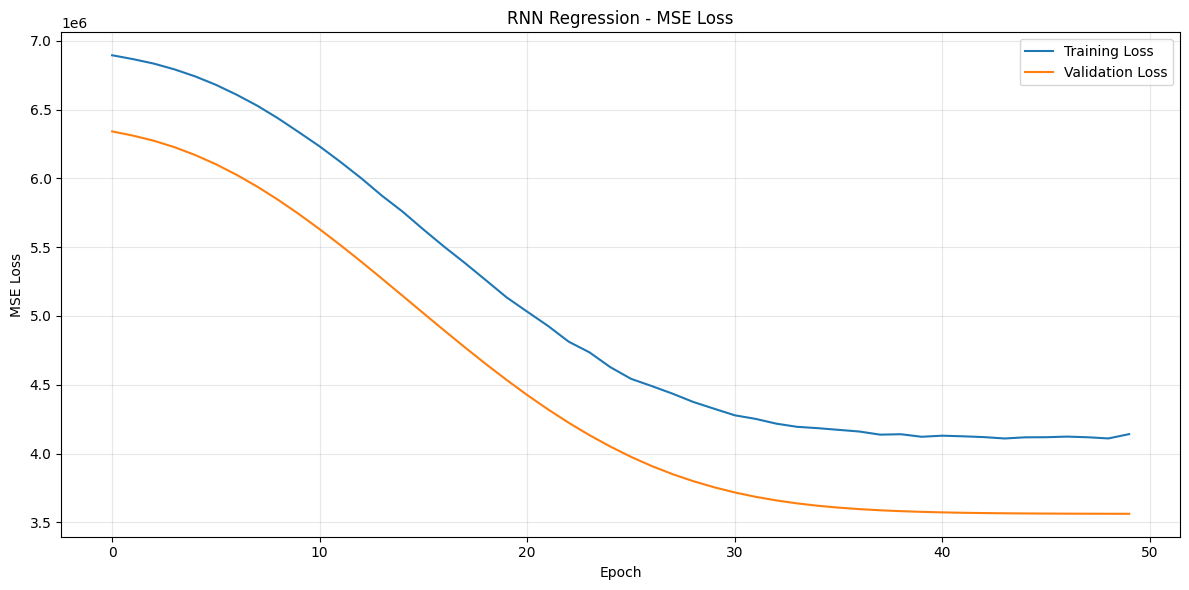

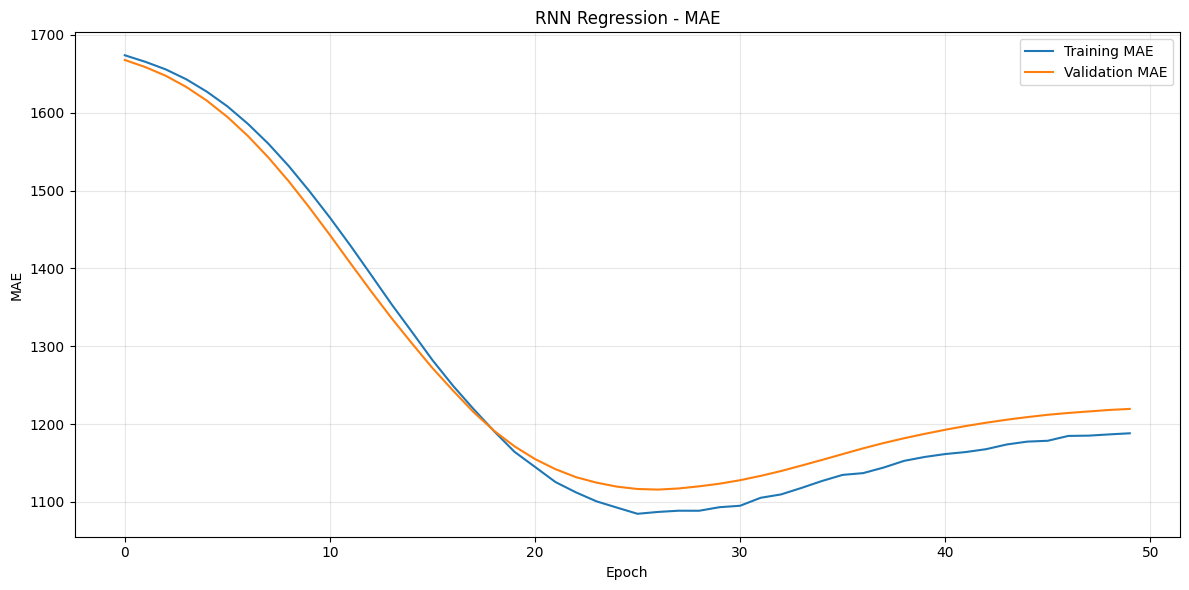



FINAL RNN ARCHITECTURE

Input
│
├── Sequence Length = 10
│
├── Features per Event = 5656
│
▼
SimpleRNN
│  Units = 128
│  Activation = tanh
│  return_sequences = True
│
▼
Dropout
│  Rate = 0.3
│
▼
SimpleRNN
│  Units = 64
│  Activation = tanh
│  return_sequences = False
│
▼
Dense
│  Units = 128
│  Activation = ReLU
│
▼
Dropout
│  Rate = 0.3
│
├───────────────────────────────┐
│                               │
▼                               ▼
Classification                 Regression
│                               │
Dense(10,           Dense(1,
Softmax)                       Linear)
│                               │
▼                               ▼
Next Purchase Category         Next Purchase Amount



OUTPUT FILES

Graphs:
 - /content/rnn_results/graphs/rnn_actual_vs_predicted.png
 - /content/rnn_results/graphs/rnn_classification_accuracy.png
 - /content/rnn_results/graphs/rnn_classification_loss.png
 - /content/rnn_results/graphs/rnn_confusion_matrix.png
 - /content/rnn_results/gra

In [87]:
# ============================================================
# 37_RNN_Shopping_Prediction.py
# ============================================================
#
# SHOPPING PREDICTION SYSTEM
#
# Deep Learning Model:
#   RNN - Recurrent Neural Network
#
# Tasks:
#   1. Next Purchase Category Prediction
#   2. Next Purchase Amount Prediction
#
# Input:
#   Previous 10 shopping events of each user
#
# Outputs:
#   Classification -> next_purchase_category
#   Regression     -> next_purchase_amount
#
# Includes:
#   - Architecture diagrams
#   - Data flow diagrams
#   - Feature preprocessing
#   - Sequence generation
#   - RNN classification
#   - RNN regression
#   - Training graphs
#   - Validation graphs
#   - Confusion matrix
#   - Actual vs predicted
#   - Classification metrics
#   - Regression metrics
#   - Model saving
#   - Prediction saving
#
# ============================================================


# ============================================================
# 1. INSTALL DEPENDENCIES
# ============================================================

import sys
import subprocess
import importlib


def install_if_missing(package_name, import_name=None):

    if import_name is None:
        import_name = package_name

    try:
        importlib.import_module(import_name)

    except ImportError:

        print(f"Installing {package_name}...")

        subprocess.check_call(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "-q",
                package_name
            ]
        )


install_if_missing("tensorflow", "tensorflow")
install_if_missing("pandas", "pandas")
install_if_missing("numpy", "numpy")
install_if_missing("scikit-learn", "sklearn")
install_if_missing("matplotlib", "matplotlib")
install_if_missing("seaborn", "seaborn")
install_if_missing("joblib", "joblib")


# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    LabelEncoder
)

from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix,
    classification_report,
    log_loss,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    explained_variance_score,
    median_absolute_error
)

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Input,
    SimpleRNN,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)


warnings.filterwarnings("ignore")


# ============================================================
# 3. RANDOM SEEDS
# ============================================================

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)


# ============================================================
# 4. PATH CONFIGURATION
# ============================================================

BASE_DIR = Path("/content")

DATA_DIR = BASE_DIR / "feature_data"

TRAIN_FILE = DATA_DIR / "train.csv"
VALIDATION_FILE = DATA_DIR / "validation.csv"
TEST_FILE = DATA_DIR / "test.csv"
FEATURE_FILE = DATA_DIR / "shopping_features.csv"


OUTPUT_DIR = BASE_DIR / "rnn_results"

GRAPH_DIR = OUTPUT_DIR / "graphs"

MODEL_DIR = OUTPUT_DIR / "models"

PREDICTION_DIR = OUTPUT_DIR / "predictions"

METRIC_DIR = OUTPUT_DIR / "metrics"


for directory in [
    OUTPUT_DIR,
    GRAPH_DIR,
    MODEL_DIR,
    PREDICTION_DIR,
    METRIC_DIR
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


print("=" * 80)
print("RNN SHOPPING PREDICTION SYSTEM")
print("=" * 80)

print("\nTensorFlow version:", tf.__version__)

print("\nData directory:")
print(DATA_DIR)

print("\nOutput directory:")
print(OUTPUT_DIR)


# ============================================================
# 5. PROJECT PARAMETERS
# ============================================================

SEQUENCE_LENGTH = 10

BATCH_SIZE = 256

EPOCHS = 50

LEARNING_RATE = 0.001

RNN_UNITS_1 = 128

RNN_UNITS_2 = 64

DROPOUT_RATE = 0.30


CLASSIFICATION_TARGET = "next_purchase_category"

REGRESSION_TARGET = "next_purchase_amount"


# ============================================================
# 6. PRINT MODEL ARCHITECTURE DIAGRAM
# ============================================================

def print_architecture():

    print("\n")
    print("=" * 80)
    print("RNN MODEL ARCHITECTURE")
    print("=" * 80)

    print(
        """
        ┌───────────────────────────────────────────────┐
        │           INPUT SEQUENCE                      │
        │                                               │
        │  Previous 10 Shopping Events                  │
        │  Shape: (10, number_of_features)              │
        └──────────────────────┬────────────────────────┘
                               │
                               ▼
        ┌───────────────────────────────────────────────┐
        │                SIMPLE RNN                      │
        │                                               │
        │  Units = 128                                  │
        │  Activation = tanh                            │
        │  return_sequences = True                      │
        └──────────────────────┬────────────────────────┘
                               │
                               ▼
        ┌───────────────────────────────────────────────┐
        │                  DROPOUT                       │
        │                  30%                           │
        └──────────────────────┬────────────────────────┘
                               │
                               ▼
        ┌───────────────────────────────────────────────┐
        │                SIMPLE RNN                      │
        │                                               │
        │  Units = 64                                   │
        │  Activation = tanh                            │
        │  return_sequences = False                     │
        └──────────────────────┬────────────────────────┘
                               │
                               ▼
        ┌───────────────────────────────────────────────┐
        │                  DENSE                         │
        │                                               │
        │  Units = 128                                  │
        │  Activation = ReLU                            │
        └──────────────────────┬────────────────────────┘
                               │
                               ▼
        ┌───────────────────────────────────────────────┐
        │                 DROPOUT                        │
        │                  30%                           │
        └──────────────────────┬────────────────────────┘
                               │
                  ┌────────────┴────────────┐
                  │                         │
                  ▼                         ▼

        ┌───────────────────┐       ┌───────────────────┐
        │ CLASSIFICATION    │       │ REGRESSION        │
        │                   │       │                   │
        │ Dense             │       │ Dense             │
        │ Softmax           │       │ Linear            │
        │                   │       │                   │
        │ Next Category     │       │ Next Amount       │
        └───────────────────┘       └───────────────────┘
        """
    )


print_architecture()


# ============================================================
# 7. PRINT DATA FLOW DIAGRAM
# ============================================================

def print_data_flow():

    print("\n")
    print("=" * 80)
    print("DATA FLOW DIAGRAM")
    print("=" * 80)

    print(
        """
        ┌─────────────────────────────┐
        │ shopping_events.csv         │
        └──────────────┬──────────────┘
                       │
                       ▼
        ┌─────────────────────────────┐
        │ Load train / validation /   │
        │ test datasets               │
        └──────────────┬──────────────┘
                       │
                       ▼
        ┌─────────────────────────────┐
        │ Clean columns               │
        │ Handle missing values       │
        │ Remove target leakage       │
        └──────────────┬──────────────┘
                       │
                       ▼
        ┌─────────────────────────────┐
        │ Numerical preprocessing     │
        │ Median Imputation           │
        │ StandardScaler              │
        └──────────────┬──────────────┘
                       │
                       ▼
        ┌─────────────────────────────┐
        │ Categorical preprocessing   │
        │ Most Frequent Imputation    │
        │ One-Hot Encoding            │
        └──────────────┬──────────────┘
                       │
                       ▼
        ┌─────────────────────────────┐
        │ Sort by User + Timestamp    │
        └──────────────┬──────────────┘
                       │
                       ▼
        ┌─────────────────────────────┐
        │ Sliding Window              │
        │                             │
        │ Event 1                     │
        │ Event 2                     │
        │ ...                         │
        │ Event 10                    │
        │        ↓                    │
        │ Predict Event 11            │
        └──────────────┬──────────────┘
                       │
                       ▼
        ┌─────────────────────────────┐
        │ RNN                         │
        └──────────────┬──────────────┘
                       │
              ┌────────┴─────────┐
              ▼                  ▼
        Category              Amount
        Prediction            Prediction
              │                  │
              ▼                  ▼
        Classification       Regression
        Metrics              Metrics
              │                  │
              └────────┬─────────┘
                       ▼
        ┌─────────────────────────────┐
        │ Graphs + Models + Results   │
        └─────────────────────────────┘
        """
    )


print_data_flow()


# ============================================================
# 8. VERIFY DATA FILES
# ============================================================

print("\n")
print("=" * 80)
print("CHECKING DATA FILES")
print("=" * 80)


for file_path in [
    TRAIN_FILE,
    VALIDATION_FILE,
    TEST_FILE
]:

    print(
        f"{file_path} -> "
        f"{'FOUND' if file_path.exists() else 'NOT FOUND'}"
    )


if not TRAIN_FILE.exists():

    raise FileNotFoundError(
        f"\nTraining file not found:\n{TRAIN_FILE}\n"
        f"\nExpected structure:\n"
        f"/content/feature_data/train.csv"
    )


if not VALIDATION_FILE.exists():

    raise FileNotFoundError(
        f"\nValidation file not found:\n{VALIDATION_FILE}"
    )


if not TEST_FILE.exists():

    raise FileNotFoundError(
        f"\nTest file not found:\n{TEST_FILE}"
    )


# ============================================================
# 9. LOAD DATA
# ============================================================

print("\n")
print("=" * 80)
print("LOADING DATA")
print("=" * 80)


train_df = pd.read_csv(TRAIN_FILE)

validation_df = pd.read_csv(VALIDATION_FILE)

test_df = pd.read_csv(TEST_FILE)


print("\nTrain shape:")
print(train_df.shape)

print("\nValidation shape:")
print(validation_df.shape)

print("\nTest shape:")
print(test_df.shape)


# ============================================================
# 10. BASIC INFORMATION
# ============================================================

print("\n")
print("=" * 80)
print("DATASET INFORMATION")
print("=" * 80)

print("\nTrain columns:")

for column in train_df.columns:

    print(" -", column)


print("\nClassification target exists:")

print(
    CLASSIFICATION_TARGET in train_df.columns
)


print("\nRegression target exists:")

print(
    REGRESSION_TARGET in train_df.columns
)


# ============================================================
# 11. IDENTIFY IMPORTANT COLUMNS
# ============================================================

def find_column(df, candidates):

    for candidate in candidates:

        if candidate in df.columns:

            return candidate

    return None


USER_COLUMN = find_column(
    train_df,
    [
        "user_id",
        "User_ID",
        "userid",
        "customer_id",
        "customerId"
    ]
)


TIME_COLUMN = find_column(
    train_df,
    [
        "timestamp",
        "event_timestamp",
        "datetime",
        "date",
        "event_time",
        "created_at"
    ]
)


PRODUCT_COLUMN = find_column(
    train_df,
    [
        "product_id",
        "Product_ID",
        "product",
        "item_id"
    ]
)


CATEGORY_COLUMN = find_column(
    train_df,
    [
        "category",
        "product_category",
        "Category"
    ]
)


ACTION_COLUMN = find_column(
    train_df,
    [
        "action",
        "event_type",
        "event",
        "activity"
    ]
)


PRICE_COLUMN = find_column(
    train_df,
    [
        "price",
        "amount",
        "purchase_amount",
        "product_price"
    ]
)


print("\nDetected columns:")

print("User      :", USER_COLUMN)

print("Time      :", TIME_COLUMN)

print("Product   :", PRODUCT_COLUMN)

print("Category  :", CATEGORY_COLUMN)

print("Action    :", ACTION_COLUMN)

print("Price     :", PRICE_COLUMN)


# ============================================================
# 12. COPY DATASETS
# ============================================================

train = train_df.copy()

validation = validation_df.copy()

test = test_df.copy()


# ============================================================
# 13. SORT DATA BY USER AND TIME
# ============================================================

if TIME_COLUMN is not None:

    train[TIME_COLUMN] = pd.to_datetime(
        train[TIME_COLUMN],
        errors="coerce"
    )

    validation[TIME_COLUMN] = pd.to_datetime(
        validation[TIME_COLUMN],
        errors="coerce"
    )

    test[TIME_COLUMN] = pd.to_datetime(
        test[TIME_COLUMN],
        errors="coerce"
    )


if USER_COLUMN is not None and TIME_COLUMN is not None:

    train = train.sort_values(
        [USER_COLUMN, TIME_COLUMN]
    ).reset_index(drop=True)

    validation = validation.sort_values(
        [USER_COLUMN, TIME_COLUMN]
    ).reset_index(drop=True)

    test = test.sort_values(
        [USER_COLUMN, TIME_COLUMN]
    ).reset_index(drop=True)


# ============================================================
# 14. REMOVE LEAKAGE COLUMNS
# ============================================================

def identify_drop_columns(df):

    columns_to_drop = []

    for column in df.columns:

        column_lower = column.lower()

        # Target columns
        if column in [
            CLASSIFICATION_TARGET,
            REGRESSION_TARGET
        ]:

            columns_to_drop.append(column)

            continue

        # Future-related columns
        future_keywords = [
            "future",
            "next_purchase",
            "target_",
            "future_"
        ]

        if any(
            keyword in column_lower
            for keyword in future_keywords
        ):

            columns_to_drop.append(column)

            continue

        # IDs that should not be treated as numerical signals
        if column_lower in [
            "event_id",
            "transaction_id"
        ]:

            columns_to_drop.append(column)

            continue

    return list(
        dict.fromkeys(columns_to_drop)
    )


DROP_COLUMNS = identify_drop_columns(train)


print("\nColumns removed from model features:")

for column in DROP_COLUMNS:

    print(" -", column)


# ============================================================
# 15. BUILD FEATURE MATRICES
# ============================================================

X_train_df = train.drop(
    columns=DROP_COLUMNS,
    errors="ignore"
).copy()


X_validation_df = validation.drop(
    columns=DROP_COLUMNS,
    errors="ignore"
).copy()


X_test_df = test.drop(
    columns=DROP_COLUMNS,
    errors="ignore"
).copy()


# ============================================================
# 16. REMOVE TIME COLUMN FROM MODEL FEATURES
# ============================================================

if TIME_COLUMN is not None:

    for df in [
        X_train_df,
        X_validation_df,
        X_test_df
    ]:

        if TIME_COLUMN in df.columns:

            df.drop(
                columns=[TIME_COLUMN],
                inplace=True
            )


# ============================================================
# 17. REMOVE USER ID FROM MODEL FEATURES
# ============================================================

if USER_COLUMN is not None:

    for df in [
        X_train_df,
        X_validation_df,
        X_test_df
    ]:

        if USER_COLUMN in df.columns:

            df.drop(
                columns=[USER_COLUMN],
                inplace=True
            )


# ============================================================
# 18. REMOVE OTHER RAW IDENTIFIERS
# ============================================================

IDENTIFIER_COLUMNS = [

    "event_id",
    "transaction_id",
    "session_id"
]


for df in [
    X_train_df,
    X_validation_df,
    X_test_df
]:

    for column in IDENTIFIER_COLUMNS:

        if column in df.columns:

            df.drop(
                columns=[column],
                inplace=True
            )


# ============================================================
# 19. ALIGN DATAFRAME COLUMNS
# ============================================================

common_columns = [

    column
    for column in X_train_df.columns

    if column in X_validation_df.columns
    and column in X_test_df.columns
]


X_train_df = X_train_df[
    common_columns
].copy()


X_validation_df = X_validation_df[
    common_columns
].copy()


X_test_df = X_test_df[
    common_columns
].copy()


# ============================================================
# 20. IDENTIFY NUMERIC / CATEGORICAL FEATURES
# ============================================================

numeric_columns = X_train_df.select_dtypes(
    include=["number"]
).columns.tolist()


categorical_columns = X_train_df.select_dtypes(
    exclude=["number"]
).columns.tolist()


print("\n")
print("=" * 80)
print("FEATURE INFORMATION")
print("=" * 80)

print("\nNumber of numerical features:")

print(len(numeric_columns))


print("\nNumber of categorical features:")

print(len(categorical_columns))


print("\nNumerical features:")

print(numeric_columns[:30])


print("\nCategorical features:")

print(categorical_columns[:30])


# ============================================================
# 21. PREPROCESSOR
# ============================================================

numeric_pipeline = None

categorical_pipeline = None


if len(numeric_columns) > 0:

    numeric_pipeline = SimpleImputer(
        strategy="median"
    )


if len(categorical_columns) > 0:

    categorical_pipeline = SimpleImputer(
        strategy="most_frequent"
    )


# ============================================================
# 22. MANUAL PREPROCESSING
# ============================================================

# Numerical features

if len(numeric_columns) > 0:

    train_numeric = numeric_pipeline.fit_transform(
        X_train_df[numeric_columns]
    )

    validation_numeric = numeric_pipeline.transform(
        X_validation_df[numeric_columns]
    )

    test_numeric = numeric_pipeline.transform(
        X_test_df[numeric_columns]
    )

    scaler = StandardScaler()

    train_numeric = scaler.fit_transform(
        train_numeric
    )

    validation_numeric = scaler.transform(
        validation_numeric
    )

    test_numeric = scaler.transform(
        test_numeric
    )

else:

    train_numeric = np.empty(
        (len(X_train_df), 0)
    )

    validation_numeric = np.empty(
        (len(X_validation_df), 0)
    )

    test_numeric = np.empty(
        (len(X_test_df), 0)
    )

    scaler = None


# ============================================================
# 23. CATEGORICAL FEATURES
# ============================================================

if len(categorical_columns) > 0:

    categorical_imputer = SimpleImputer(
        strategy="most_frequent"
    )


    train_cat = categorical_imputer.fit_transform(
        X_train_df[categorical_columns]
    )


    validation_cat = categorical_imputer.transform(
        X_validation_df[categorical_columns]
    )


    test_cat = categorical_imputer.transform(
        X_test_df[categorical_columns]
    )


    encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )


    train_cat = encoder.fit_transform(
        train_cat
    )


    validation_cat = encoder.transform(
        validation_cat
    )


    test_cat = encoder.transform(
        test_cat
    )


else:

    train_cat = np.empty(
        (len(X_train_df), 0)
    )

    validation_cat = np.empty(
        (len(X_validation_df), 0)
    )

    test_cat = np.empty(
        (len(X_test_df), 0)
    )

    categorical_imputer = None

    encoder = None


# ============================================================
# 24. COMBINE FEATURES
# ============================================================

X_train_processed = np.hstack(
    [
        train_numeric,
        train_cat
    ]
).astype(np.float32)


X_validation_processed = np.hstack(
    [
        validation_numeric,
        validation_cat
    ]
).astype(np.float32)


X_test_processed = np.hstack(
    [
        test_numeric,
        test_cat
    ]
).astype(np.float32)


print("\nProcessed feature shape:")

print(
    X_train_processed.shape
)


NUM_FEATURES = X_train_processed.shape[1]


print("\nTotal model features:")

print(NUM_FEATURES)


# ============================================================
# 25. SAVE PREPROCESSORS
# ============================================================

if scaler is not None:

    joblib.dump(
        scaler,
        MODEL_DIR / "rnn_scaler.pkl"
    )


if numeric_pipeline is not None:

    joblib.dump(
        numeric_pipeline,
        MODEL_DIR / "rnn_numeric_imputer.pkl"
    )


if categorical_imputer is not None:

    joblib.dump(
        categorical_imputer,
        MODEL_DIR / "rnn_categorical_imputer.pkl"
    )


if encoder is not None:

    joblib.dump(
        encoder,
        MODEL_DIR / "rnn_onehot_encoder.pkl"
    )


# ============================================================
# 26. SEQUENCE CREATION FUNCTION
# ============================================================

def create_sequences(
    processed_features,
    original_df,
    target_column,
    sequence_length,
    user_column
):

    """
    Creates chronological sequences.

    Example:

    Event 1
    Event 2
    ...
    Event 10
       ↓
    Predict Event 11
    """

    sequences = []

    targets = []

    metadata = []

    if user_column is None:

        user_groups = [
            (
                "ALL_USERS",
                original_df.index.tolist()
            )
        ]

    else:

        user_groups = original_df.groupby(
            user_column,
            sort=False
        ).groups.items()


    for user_id, indices in user_groups:

        indices = list(indices)

        if len(indices) <= sequence_length:

            continue


        for position in range(
            sequence_length,
            len(indices)
        ):

            previous_indices = indices[
                position - sequence_length:
                position
            ]


            target_index = indices[
                position
            ]


            sequence = processed_features[
                previous_indices
            ]


            target_value = original_df.loc[
                target_index,
                target_column
            ]


            sequences.append(
                sequence
            )


            targets.append(
                target_value
            )


            metadata.append(
                {
                    "user_id": user_id,
                    "target_index": target_index
                }
            )


    if len(sequences) == 0:

        raise ValueError(
            "No sequences were created. "
            "Check user column and sequence length."
        )


    return (
        np.asarray(sequences),
        np.asarray(targets),
        pd.DataFrame(metadata)
    )


# ============================================================
# 27. CREATE CLASSIFICATION SEQUENCES
# ============================================================

print("\n")
print("=" * 80)
print("CREATING CLASSIFICATION SEQUENCES")
print("=" * 80)


X_train_cls, y_train_cls_raw, train_cls_meta = create_sequences(
    X_train_processed,
    train,
    CLASSIFICATION_TARGET,
    SEQUENCE_LENGTH,
    USER_COLUMN
)


X_validation_cls, y_validation_cls_raw, validation_cls_meta = create_sequences(
    X_validation_processed,
    validation,
    CLASSIFICATION_TARGET,
    SEQUENCE_LENGTH,
    USER_COLUMN
)


X_test_cls, y_test_cls_raw, test_cls_meta = create_sequences(
    X_test_processed,
    test,
    CLASSIFICATION_TARGET,
    SEQUENCE_LENGTH,
    USER_COLUMN
)


print("\nTraining sequences:")

print(X_train_cls.shape)


print("\nValidation sequences:")

print(X_validation_cls.shape)


print("\nTest sequences:")

print(X_test_cls.shape)


# ============================================================
# 28. CLASS LABEL ENCODING
# ============================================================

label_encoder = LabelEncoder()


all_class_values = pd.concat(
    [
        pd.Series(y_train_cls_raw),
        pd.Series(y_validation_cls_raw),
        pd.Series(y_test_cls_raw)
    ]
).astype(str)


label_encoder.fit(
    all_class_values
)


y_train_cls = label_encoder.transform(
    y_train_cls_raw.astype(str)
)


y_validation_cls = label_encoder.transform(
    y_validation_cls_raw.astype(str)
)


y_test_cls = label_encoder.transform(
    y_test_cls_raw.astype(str)
)


NUM_CLASSES = len(
    label_encoder.classes_
)


print("\n")
print("Number of classes:")

print(NUM_CLASSES)


print("\nClasses:")

for index, class_name in enumerate(
    label_encoder.classes_
):

    print(
        index,
        "->",
        class_name
    )


joblib.dump(
    label_encoder,
    MODEL_DIR / "rnn_label_encoder.pkl"
)


# ============================================================
# 29. CREATE REGRESSION SEQUENCES
# ============================================================

print("\n")
print("=" * 80)
print("CREATING REGRESSION SEQUENCES")
print("=" * 80)


X_train_reg, y_train_reg, train_reg_meta = create_sequences(
    X_train_processed,
    train,
    REGRESSION_TARGET,
    SEQUENCE_LENGTH,
    USER_COLUMN
)


X_validation_reg, y_validation_reg, validation_reg_meta = create_sequences(
    X_validation_processed,
    validation,
    REGRESSION_TARGET,
    SEQUENCE_LENGTH,
    USER_COLUMN
)


X_test_reg, y_test_reg, test_reg_meta = create_sequences(
    X_test_processed,
    test,
    REGRESSION_TARGET,
    SEQUENCE_LENGTH,
    USER_COLUMN
)


y_train_reg = pd.to_numeric(
    y_train_reg,
    errors="coerce"
)


y_validation_reg = pd.to_numeric(
    y_validation_reg,
    errors="coerce"
)


y_test_reg = pd.to_numeric(
    y_test_reg,
    errors="coerce"
)


# Remove invalid regression targets

train_valid = np.isfinite(
    y_train_reg
)

validation_valid = np.isfinite(
    y_validation_reg
)

test_valid = np.isfinite(
    y_test_reg
)


X_train_reg = X_train_reg[
    train_valid
]

y_train_reg = y_train_reg[
    train_valid
]


X_validation_reg = X_validation_reg[
    validation_valid
]

y_validation_reg = y_validation_reg[
    validation_valid
]


X_test_reg = X_test_reg[
    test_valid
]

y_test_reg = y_test_reg[
    test_valid
]


print("\nTraining sequences:")

print(X_train_reg.shape)


print("\nValidation sequences:")

print(X_validation_reg.shape)


print("\nTest sequences:")

print(X_test_reg.shape)


# ============================================================
# 30. BUILD RNN CLASSIFIER
# ============================================================

def build_rnn_classifier(
    sequence_length,
    num_features,
    num_classes
):

    model = Sequential(
        [
            Input(
                shape=(
                    sequence_length,
                    num_features
                )
            ),

            SimpleRNN(
                RNN_UNITS_1,
                activation="tanh",
                return_sequences=True
            ),

            Dropout(
                DROPOUT_RATE
            ),

            SimpleRNN(
                RNN_UNITS_2,
                activation="tanh",
                return_sequences=False
            ),

            Dense(
                128,
                activation="relu"
            ),

            Dropout(
                DROPOUT_RATE
            ),

            Dense(
                num_classes,
                activation="softmax"
            )
        ],
        name="RNN_Classifier"
    )


    model.compile(
        optimizer=Adam(
            learning_rate=LEARNING_RATE
        ),

        loss="sparse_categorical_crossentropy",

        metrics=[
            "accuracy"
        ]
    )


    return model


rnn_classifier = build_rnn_classifier(
    SEQUENCE_LENGTH,
    NUM_FEATURES,
    NUM_CLASSES
)


print("\n")
print("=" * 80)
print("RNN CLASSIFICATION MODEL")
print("=" * 80)

rnn_classifier.summary()


# ============================================================
# 31. CLASSIFICATION CALLBACKS
# ============================================================

classification_checkpoint = ModelCheckpoint(
    MODEL_DIR / "rnn_classifier_best.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)


classification_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)


classification_lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)


# ============================================================
# 32. TRAIN CLASSIFIER
# ============================================================

print("\n")
print("=" * 80)
print("TRAINING RNN CLASSIFIER")
print("=" * 80)


classifier_history = rnn_classifier.fit(

    X_train_cls,

    y_train_cls,

    validation_data=(
        X_validation_cls,
        y_validation_cls
    ),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    callbacks=[
        classification_checkpoint,
        classification_early_stopping,
        classification_lr_scheduler
    ],

    verbose=1
)


# ============================================================
# 33. CLASSIFICATION PREDICTIONS
# ============================================================

print("\n")
print("=" * 80)
print("CLASSIFICATION PREDICTIONS")
print("=" * 80)


classification_probabilities = (
    rnn_classifier.predict(
        X_test_cls,
        batch_size=BATCH_SIZE,
        verbose=1
    )
)


classification_predictions = np.argmax(
    classification_probabilities,
    axis=1
)


# ============================================================
# 34. CLASSIFICATION METRICS
# ============================================================

classification_accuracy = accuracy_score(
    y_test_cls,
    classification_predictions
)


classification_balanced_accuracy = balanced_accuracy_score(
    y_test_cls,
    classification_predictions
)


classification_precision = precision_score(
    y_test_cls,
    classification_predictions,
    average="weighted",
    zero_division=0
)


classification_recall = recall_score(
    y_test_cls,
    classification_predictions,
    average="weighted",
    zero_division=0
)


classification_f1 = f1_score(
    y_test_cls,
    classification_predictions,
    average="weighted",
    zero_division=0
)


classification_mcc = matthews_corrcoef(
    y_test_cls,
    classification_predictions
)


classification_kappa = cohen_kappa_score(
    y_test_cls,
    classification_predictions
)


classification_log_loss = log_loss(
    y_test_cls,
    classification_probabilities,
    labels=np.arange(NUM_CLASSES)
)


try:

    classification_roc_auc = roc_auc_score(
        y_test_cls,
        classification_probabilities,
        multi_class="ovr",
        average="weighted"
    )

except Exception:

    classification_roc_auc = np.nan


print("\n")
print("=" * 80)
print("RNN CLASSIFICATION RESULTS")
print("=" * 80)


print(
    f"\nAccuracy              : "
    f"{classification_accuracy:.4f}"
)


print(
    f"Balanced Accuracy     : "
    f"{classification_balanced_accuracy:.4f}"
)


print(
    f"Weighted Precision    : "
    f"{classification_precision:.4f}"
)


print(
    f"Weighted Recall       : "
    f"{classification_recall:.4f}"
)


print(
    f"Weighted F1           : "
    f"{classification_f1:.4f}"
)


print(
    f"MCC                   : "
    f"{classification_mcc:.4f}"
)


print(
    f"Cohen Kappa           : "
    f"{classification_kappa:.4f}"
)


print(
    f"ROC-AUC               : "
    f"{classification_roc_auc:.4f}"
)


print(
    f"Log Loss              : "
    f"{classification_log_loss:.4f}"
)


# ============================================================
# 35. CLASSIFICATION REPORT
# ============================================================

print("\n")
print("=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)


classification_report_text = classification_report(

    y_test_cls,

    classification_predictions,

    target_names=label_encoder.classes_,

    zero_division=0
)


print(
    classification_report_text
)


with open(
    METRIC_DIR / "classification_report.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write(
        classification_report_text
    )


# ============================================================
# 36. CONFUSION MATRIX GRAPH
# ============================================================

cm = confusion_matrix(
    y_test_cls,
    classification_predictions
)


plt.figure(
    figsize=(12, 10)
)


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)


plt.title(
    "RNN - Confusion Matrix"
)


plt.xlabel(
    "Predicted Category"
)


plt.ylabel(
    "Actual Category"
)


plt.tight_layout()


plt.savefig(
    GRAPH_DIR / "rnn_confusion_matrix.png",
    dpi=300
)


plt.show()


# ============================================================
# 37. TRAINING ACCURACY GRAPH
# ============================================================

plt.figure(
    figsize=(12, 6)
)


plt.plot(
    classifier_history.history[
        "accuracy"
    ],
    label="Training Accuracy"
)


plt.plot(
    classifier_history.history[
        "val_accuracy"
    ],
    label="Validation Accuracy"
)


plt.title(
    "RNN Classification - Accuracy"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Accuracy"
)


plt.legend()


plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.savefig(
    GRAPH_DIR / "rnn_classification_accuracy.png",
    dpi=300
)


plt.show()


# ============================================================
# 38. TRAINING LOSS GRAPH
# ============================================================

plt.figure(
    figsize=(12, 6)
)


plt.plot(
    classifier_history.history[
        "loss"
    ],
    label="Training Loss"
)


plt.plot(
    classifier_history.history[
        "val_loss"
    ],
    label="Validation Loss"
)


plt.title(
    "RNN Classification - Loss"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Loss"
)


plt.legend()


plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.savefig(
    GRAPH_DIR / "rnn_classification_loss.png",
    dpi=300
)


plt.show()


# ============================================================
# 39. SAVE CLASSIFICATION PREDICTIONS
# ============================================================

classification_prediction_df = pd.DataFrame(
    {
        "actual_category": label_encoder.inverse_transform(
            y_test_cls
        ),

        "predicted_category": label_encoder.inverse_transform(
            classification_predictions
        ),

        "prediction_confidence": np.max(
            classification_probabilities,
            axis=1
        )
    }
)


classification_prediction_df.to_csv(
    PREDICTION_DIR / "rnn_classification_predictions.csv",
    index=False
)


# ============================================================
# 40. BUILD RNN REGRESSOR
# ============================================================

def build_rnn_regressor(
    sequence_length,
    num_features
):

    model = Sequential(
        [
            Input(
                shape=(
                    sequence_length,
                    num_features
                )
            ),

            SimpleRNN(
                RNN_UNITS_1,
                activation="tanh",
                return_sequences=True
            ),

            Dropout(
                DROPOUT_RATE
            ),

            SimpleRNN(
                RNN_UNITS_2,
                activation="tanh",
                return_sequences=False
            ),

            Dense(
                128,
                activation="relu"
            ),

            Dropout(
                DROPOUT_RATE
            ),

            Dense(
                1,
                activation="linear"
            )
        ],
        name="RNN_Regressor"
    )


    model.compile(

        optimizer=Adam(
            learning_rate=LEARNING_RATE
        ),

        loss="mse",

        metrics=[
            "mae"
        ]
    )


    return model


rnn_regressor = build_rnn_regressor(
    SEQUENCE_LENGTH,
    NUM_FEATURES
)


print("\n")
print("=" * 80)
print("RNN REGRESSION MODEL")
print("=" * 80)

rnn_regressor.summary()


# ============================================================
# 41. REGRESSION CALLBACKS
# ============================================================

regression_checkpoint = ModelCheckpoint(
    MODEL_DIR / "rnn_regressor_best.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)


regression_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)


regression_lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)


# ============================================================
# 42. TRAIN REGRESSOR
# ============================================================

print("\n")
print("=" * 80)
print("TRAINING RNN REGRESSOR")
print("=" * 80)


regressor_history = rnn_regressor.fit(

    X_train_reg,

    y_train_reg,

    validation_data=(
        X_validation_reg,
        y_validation_reg
    ),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    callbacks=[
        regression_checkpoint,
        regression_early_stopping,
        regression_lr_scheduler
    ],

    verbose=1
)


# ============================================================
# 43. REGRESSION PREDICTIONS
# ============================================================

print("\n")
print("=" * 80)
print("REGRESSION PREDICTIONS")
print("=" * 80)


regression_predictions = (
    rnn_regressor.predict(
        X_test_reg,
        batch_size=BATCH_SIZE,
        verbose=1
    )
    .reshape(-1)
)


# ============================================================
# 44. REGRESSION METRICS
# ============================================================

mae = mean_absolute_error(
    y_test_reg,
    regression_predictions
)


mse = mean_squared_error(
    y_test_reg,
    regression_predictions
)


rmse = np.sqrt(
    mse
)


r2 = r2_score(
    y_test_reg,
    regression_predictions
)


explained_variance = explained_variance_score(
    y_test_reg,
    regression_predictions
)


median_ae = median_absolute_error(
    y_test_reg,
    regression_predictions
)


# Safe MAPE

non_zero_mask = (
    np.abs(y_test_reg) > 1e-8
)


if non_zero_mask.sum() > 0:

    mape = np.mean(
        np.abs(
            (
                y_test_reg[
                    non_zero_mask
                ]
                -
                regression_predictions[
                    non_zero_mask
                ]
            )
            /
            y_test_reg[
                non_zero_mask
            ]
        )
    ) * 100

else:

    mape = np.nan


if np.isfinite(mape):

    accuracy_like = max(
        0,
        100 - mape
    )

else:

    accuracy_like = np.nan


print("\n")
print("=" * 80)
print("RNN REGRESSION RESULTS")
print("=" * 80)


print(
    f"\nMAE                   : "
    f"{mae:.4f}"
)


print(
    f"MSE                   : "
    f"{mse:.4f}"
)


print(
    f"RMSE                  : "
    f"{rmse:.4f}"
)


print(
    f"R²                    : "
    f"{r2:.4f}"
)


print(
    f"Explained Variance    : "
    f"{explained_variance:.4f}"
)


print(
    f"Median Absolute Error : "
    f"{median_ae:.4f}"
)


print(
    f"MAPE                  : "
    f"{mape:.4f}%"
)


print(
    f"Accuracy-like Score   : "
    f"{accuracy_like:.4f}%"
)


# ============================================================
# 45. ACTUAL VS PREDICTED GRAPH
# ============================================================

plt.figure(
    figsize=(12, 7)
)


# Limit plotted points for readability

plot_count = min(
    1000,
    len(y_test_reg)
)


plt.scatter(

    y_test_reg[
        :plot_count
    ],

    regression_predictions[
        :plot_count
    ],

    alpha=0.5
)


minimum_value = min(
    y_test_reg[
        :plot_count
    ].min(),

    regression_predictions[
        :plot_count
    ].min()
)


maximum_value = max(
    y_test_reg[
        :plot_count
    ].max(),

    regression_predictions[
        :plot_count
    ].max()
)


plt.plot(
    [
        minimum_value,
        maximum_value
    ],

    [
        minimum_value,
        maximum_value
    ],

    linestyle="--",
    linewidth=2
)


plt.title(
    "RNN Regression - Actual vs Predicted"
)


plt.xlabel(
    "Actual Next Purchase Amount"
)


plt.ylabel(
    "Predicted Next Purchase Amount"
)


plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.savefig(
    GRAPH_DIR / "rnn_actual_vs_predicted.png",
    dpi=300
)


plt.show()


# ============================================================
# 46. REGRESSION LOSS GRAPH
# ============================================================

plt.figure(
    figsize=(12, 6)
)


plt.plot(
    regressor_history.history[
        "loss"
    ],
    label="Training Loss"
)


plt.plot(
    regressor_history.history[
        "val_loss"
    ],
    label="Validation Loss"
)


plt.title(
    "RNN Regression - MSE Loss"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "MSE Loss"
)


plt.legend()


plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.savefig(
    GRAPH_DIR / "rnn_regression_loss.png",
    dpi=300
)


plt.show()


# ============================================================
# 47. REGRESSION MAE GRAPH
# ============================================================

plt.figure(
    figsize=(12, 6)
)


plt.plot(
    regressor_history.history[
        "mae"
    ],
    label="Training MAE"
)


plt.plot(
    regressor_history.history[
        "val_mae"
    ],
    label="Validation MAE"
)


plt.title(
    "RNN Regression - MAE"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "MAE"
)


plt.legend()


plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.savefig(
    GRAPH_DIR / "rnn_regression_mae.png",
    dpi=300
)


plt.show()


# ============================================================
# 48. SAVE REGRESSION PREDICTIONS
# ============================================================

regression_prediction_df = pd.DataFrame(
    {
        "actual_next_purchase_amount":
            y_test_reg,

        "predicted_next_purchase_amount":
            regression_predictions,

        "absolute_error":
            np.abs(
                y_test_reg
                -
                regression_predictions
            )
    }
)


regression_prediction_df.to_csv(
    PREDICTION_DIR / "rnn_regression_predictions.csv",
    index=False
)


# ============================================================
# 49. SAVE CLASSIFICATION METRICS
# ============================================================

classification_metrics = pd.DataFrame(
    [
        {
            "Model": "RNN",

            "Accuracy":
                classification_accuracy,

            "Balanced_Accuracy":
                classification_balanced_accuracy,

            "Precision":
                classification_precision,

            "Recall":
                classification_recall,

            "F1":
                classification_f1,

            "MCC":
                classification_mcc,

            "Cohen_Kappa":
                classification_kappa,

            "ROC_AUC":
                classification_roc_auc,

            "Log_Loss":
                classification_log_loss
        }
    ]
)


classification_metrics.to_csv(
    METRIC_DIR / "rnn_classification_metrics.csv",
    index=False
)


# ============================================================
# 50. SAVE REGRESSION METRICS
# ============================================================

regression_metrics = pd.DataFrame(
    [
        {
            "Model": "RNN",

            "MAE":
                mae,

            "MSE":
                mse,

            "RMSE":
                rmse,

            "R2":
                r2,

            "Explained_Variance":
                explained_variance,

            "Median_Absolute_Error":
                median_ae,

            "MAPE":
                mape,

            "Accuracy_like_Percent":
                accuracy_like
        }
    ]
)


regression_metrics.to_csv(
    METRIC_DIR / "rnn_regression_metrics.csv",
    index=False
)


# ============================================================
# 51. SAVE MODEL ARCHITECTURE
# ============================================================

with open(
    OUTPUT_DIR / "rnn_architecture.txt",
    "w",
    encoding="utf-8"
) as file:

    rnn_classifier.summary(
        print_fn=file.write
    )

    file.write(
        "\n\n"
    )

    rnn_regressor.summary(
        print_fn=file.write
    )


# ============================================================
# 52. SAVE FINAL MODELS
# ============================================================

rnn_classifier.save(
    MODEL_DIR / "rnn_classifier_final.keras"
)


rnn_regressor.save(
    MODEL_DIR / "rnn_regressor_final.keras"
)


# ============================================================
# 53. CREATE MODEL COMPARISON SUMMARY
# ============================================================

comparison = pd.DataFrame(
    [
        {
            "Model": "RNN",

            "Classification_Accuracy":
                classification_accuracy,

            "Classification_F1":
                classification_f1,

            "Classification_MCC":
                classification_mcc,

            "Classification_Kappa":
                classification_kappa,

            "Regression_MAE":
                mae,

            "Regression_RMSE":
                rmse,

            "Regression_R2":
                r2,

            "Regression_MAPE":
                mape
        }
    ]
)


comparison.to_csv(
    OUTPUT_DIR / "rnn_model_comparison.csv",
    index=False
)


# ============================================================
# 54. FINAL ARCHITECTURE PRINT
# ============================================================

print("\n")
print("=" * 80)
print("FINAL RNN ARCHITECTURE")
print("=" * 80)


print(
    f"""
Input
│
├── Sequence Length = {SEQUENCE_LENGTH}
│
├── Features per Event = {NUM_FEATURES}
│
▼
SimpleRNN
│  Units = {RNN_UNITS_1}
│  Activation = tanh
│  return_sequences = True
│
▼
Dropout
│  Rate = {DROPOUT_RATE}
│
▼
SimpleRNN
│  Units = {RNN_UNITS_2}
│  Activation = tanh
│  return_sequences = False
│
▼
Dense
│  Units = 128
│  Activation = ReLU
│
▼
Dropout
│  Rate = {DROPOUT_RATE}
│
├───────────────────────────────┐
│                               │
▼                               ▼
Classification                 Regression
│                               │
Dense({NUM_CLASSES},           Dense(1,
Softmax)                       Linear)
│                               │
▼                               ▼
Next Purchase Category         Next Purchase Amount
"""
)


# ============================================================
# 55. OUTPUT FILES
# ============================================================

print("\n")
print("=" * 80)
print("OUTPUT FILES")
print("=" * 80)


print("\nGraphs:")

for file in sorted(
    GRAPH_DIR.glob("*")
):

    print(
        " -",
        file
    )


print("\nModels:")

for file in sorted(
    MODEL_DIR.glob("*")
):

    print(
        " -",
        file
    )


print("\nMetrics:")

for file in sorted(
    METRIC_DIR.glob("*")
):

    print(
        " -",
        file
    )


print("\nPredictions:")

for file in sorted(
    PREDICTION_DIR.glob("*")
):

    print(
        " -",
        file
    )


# ============================================================
# 56. FINAL RESULTS
# ============================================================

print("\n")
print("=" * 80)
print("FINAL RNN RESULTS")
print("=" * 80)


print(
    f"""
CLASSIFICATION

Accuracy          : {classification_accuracy:.4f}
Balanced Accuracy : {classification_balanced_accuracy:.4f}
Precision         : {classification_precision:.4f}
Recall            : {classification_recall:.4f}
F1 Score          : {classification_f1:.4f}
MCC               : {classification_mcc:.4f}
Cohen Kappa       : {classification_kappa:.4f}
ROC-AUC           : {classification_roc_auc:.4f}
Log Loss          : {classification_log_loss:.4f}


REGRESSION

MAE               : {mae:.4f}
MSE               : {mse:.4f}
RMSE              : {rmse:.4f}
R²                : {r2:.4f}
Explained Var.    : {explained_variance:.4f}
Median AE         : {median_ae:.4f}
MAPE              : {mape:.4f}%
Accuracy-like     : {accuracy_like:.4f}%
"""
)


print("\n")
print("=" * 80)
print("RNN TRAINING COMPLETED SUCCESSFULLY")
print("=" * 80)

print(
    "\nAll results saved inside:"
)

print(
    OUTPUT_DIR
)

#LSTM+Transformer



LSTM + TRANSFORMER SHOPPING PREDICTION SYSTEM
TensorFlow: 2.20.0


LSTM ARCHITECTURE

        Previous 10 Shopping Events
                    │
                    ▼
        ┌──────────────────────────────┐
        │ Input                        │
        │ (10 × Features)              │
        └──────────────┬───────────────┘
                       │
                       ▼
        ┌──────────────────────────────┐
        │ LSTM                         │
        │                              │
        │ Units = 128                  │
        │ return_sequences = True      │
        └──────────────┬───────────────┘
                       │
                       ▼
        ┌──────────────────────────────┐
        │ Dropout                      │
        │ 30%                          │
        └──────────────┬───────────────┘
                       │
                       ▼
        ┌──────────────────────────────┐
        │ LSTM                         │
        │                 

Model: "LSTM_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 10, 5656)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 10, 128)        │     2,961,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,020,938 (11.52 MB)

 Trainable params: 3,020,938 (11.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1028 - loss: 2.3038
Epoch 1: val_loss improved from None to 2.28840, saving model to /content/lstm_transformer_results/models/lstm_classifier_best.keras

Epoch 1: finished saving model to /content/lstm_transformer_results/models/lstm_classifier_best.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.1041 - loss: 2.3046 - val_accuracy: 0.1429 - val_loss: 2.2884 - learning_rate: 0.0010
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1574 - loss: 2.2840
Epoch 2: val_loss did not improve from 2.28840
14/14 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.1447 - loss: 2.2871 - val_accuracy: 0.0952 - val_loss: 2.2887 - learning_rate: 0.0010
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.1789 - loss: 2.2666
Epoch 3: val_loss improved from 2.28840 to 2.28830, saving model to /content/lstm_transformer_results/models/lstm_classifier_best.keras

Epoch 3: finished saving model to /content/lstm_tr

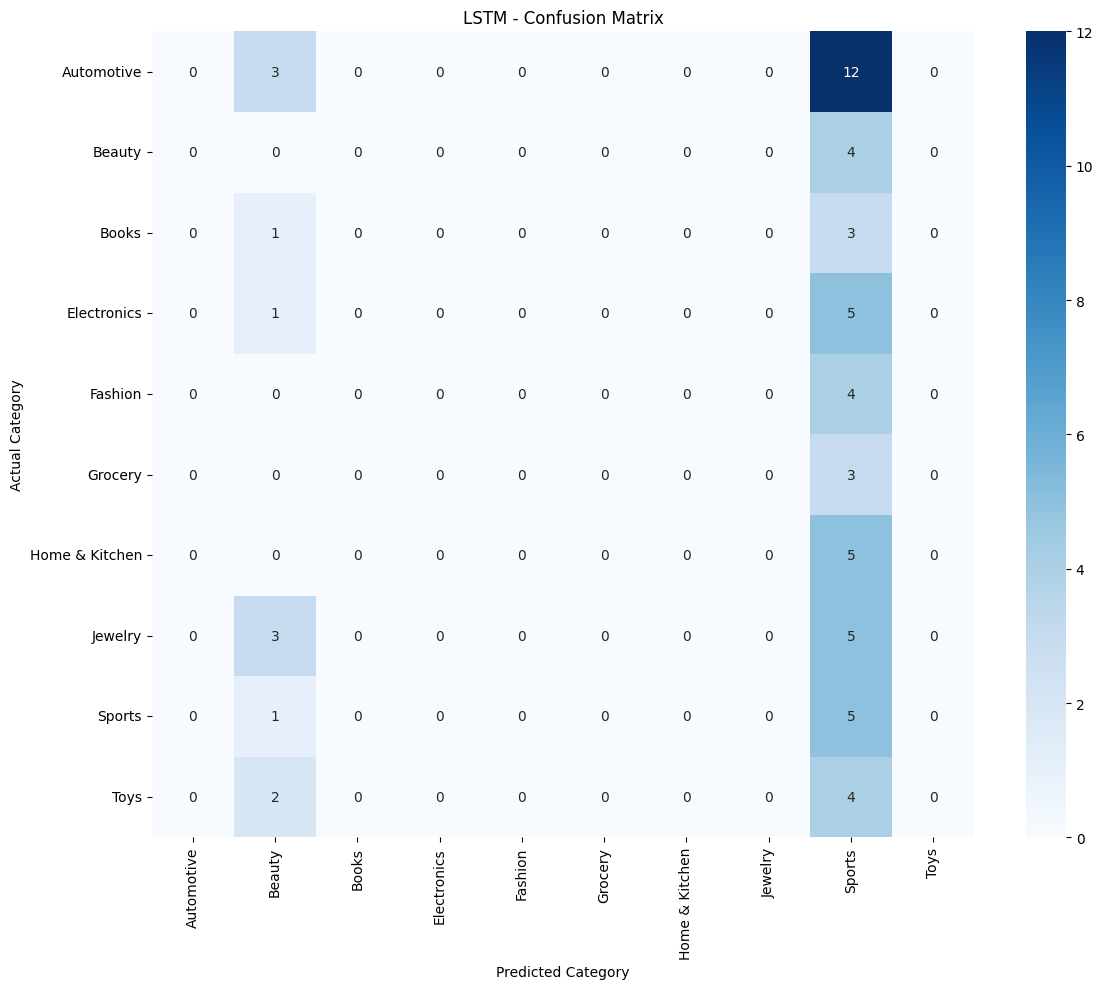

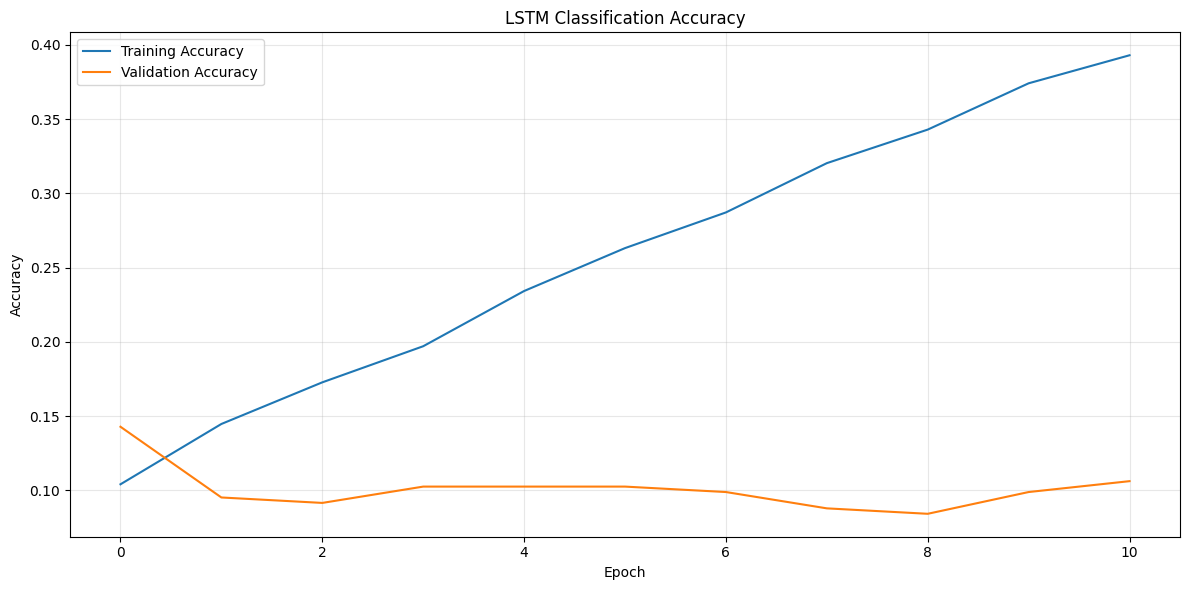

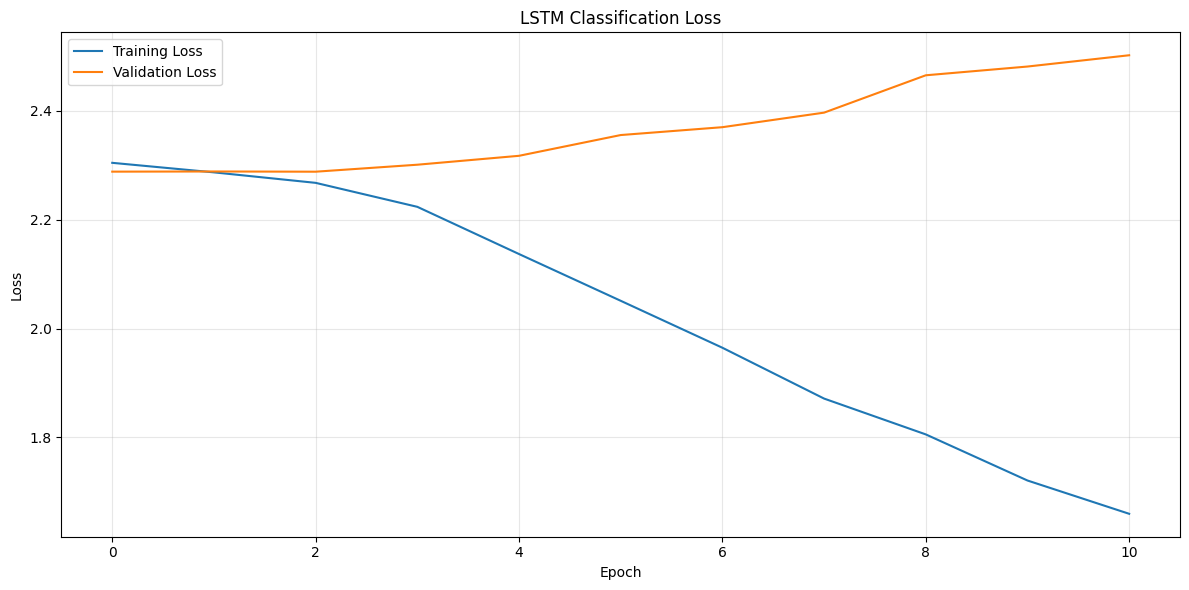



LSTM REGRESSOR


Model: "LSTM_Regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 10, 5656)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 10, 128)        │     2,961,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,019,777 (11.52 MB)

 Trainable params: 3,019,777 (11.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 754ms/step - loss: 6710761.2143 - mae: 1663.4389
Epoch 1: val_loss improved from None to 6349575.00000, saving model to /content/lstm_transformer_results/models/lstm_regressor_best.keras

Epoch 1: finished saving model to /content/lstm_transformer_results/models/lstm_regressor_best.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 17s 855ms/step - loss: 6898852.0000 - mae: 1674.6013 - val_loss: 6349575.0000 - val_mae: 1669.9237 - learning_rate: 0.0010
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 635ms/step - loss: 6690586.5000 - mae: 1657.3668
Epoch 2: val_loss improved from 6349575.00000 to 6308992.00000, saving model to /content/lstm_transformer_results/models/lstm_regressor_best.keras

Epoch 2: finished saving model to /content/lstm_transformer_results/models/lstm_regressor_best.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 19s 709ms/step - loss: 6871397.0000 - mae: 1666.3705 - val_loss: 6308992.0000 - val_mae: 1657.7294 - learning_rate: 0.0010
Epoch 3/50
14/14 ━━━━━━━━━━━━━━

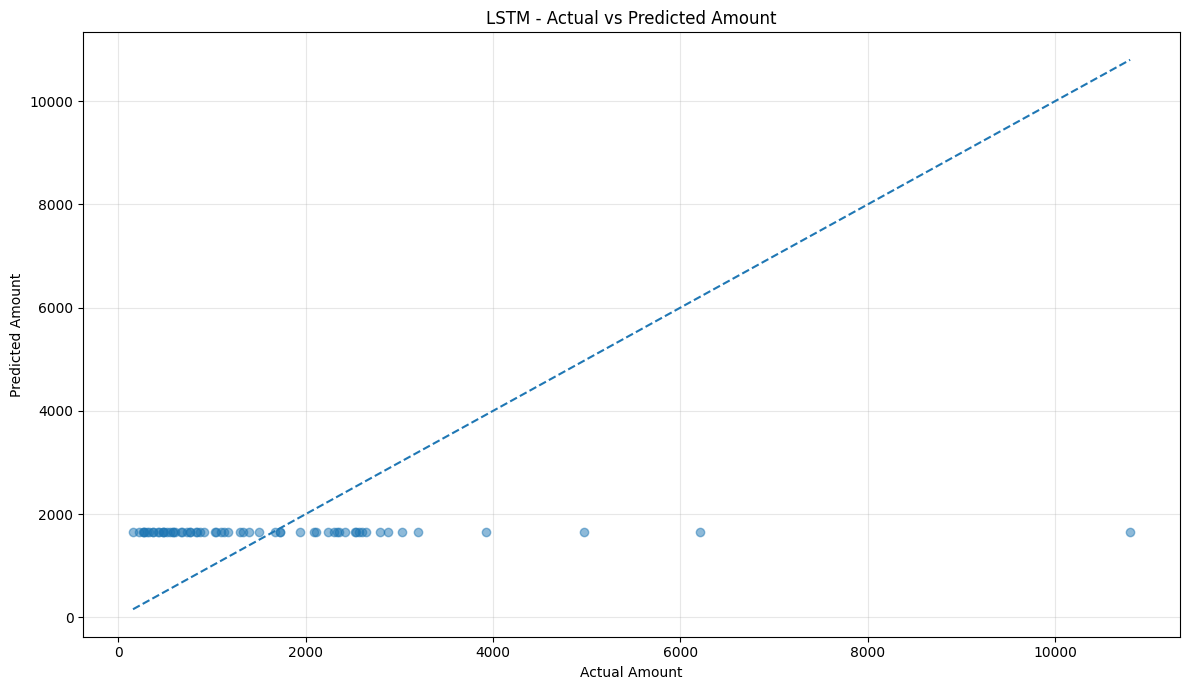

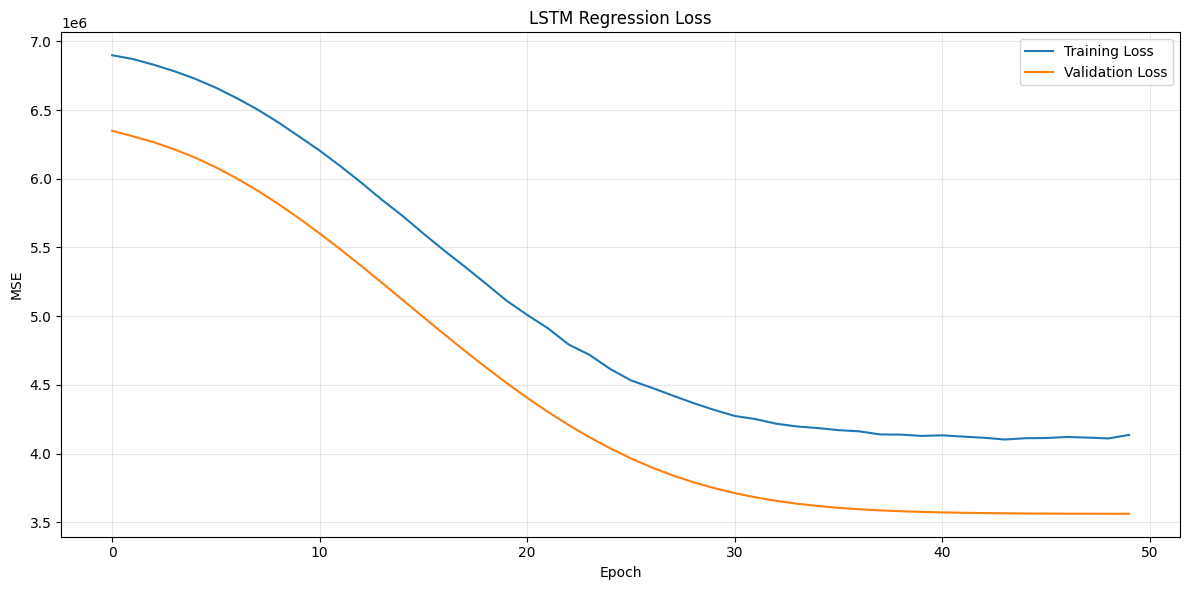



TRANSFORMER CLASSIFIER


Model: "Transformer_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 10, 5656)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10, 128)        │       724,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_embedding            │ (None, 10, 128)        │         1,280 │
│ (PositionalEmbedding)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 10, 128)        │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 10, 128)        │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,008,138 (3.85 MB)

 Trainable params: 1,008,138 (3.85 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0969 - loss: 2.4165
Epoch 1: val_loss improved from None to 2.31693, saving model to /content/lstm_transformer_results/models/transformer_classifier_best.keras

Epoch 1: finished saving model to /content/lstm_transformer_results/models/transformer_classifier_best.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.1004 - loss: 2.3752 - val_accuracy: 0.1099 - val_loss: 2.3169 - learning_rate: 0.0010
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1128 - loss: 2.3044
Epoch 2: val_loss improved from 2.31693 to 2.29652, saving model to /content/lstm_transformer_results/models/transformer_classifier_best.keras

Epoch 2: finished saving model to /content/lstm_transformer_results/models/transformer_classifier_best.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.1076 - loss: 2.3061 - val_accuracy: 0.0916 - val_loss: 2.2965 - learning_rate: 0.0010
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - ac

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step


Transformer CLASSIFICATION RESULTS
Accuracy           : 0.0984
Balanced Accuracy  : 0.1083
Precision          : 0.0326
Recall             : 0.0984
F1                 : 0.0439
MCC                : 0.0103
Cohen Kappa        : 0.0080
ROC-AUC            : 0.5093
Log Loss           : 2.3106


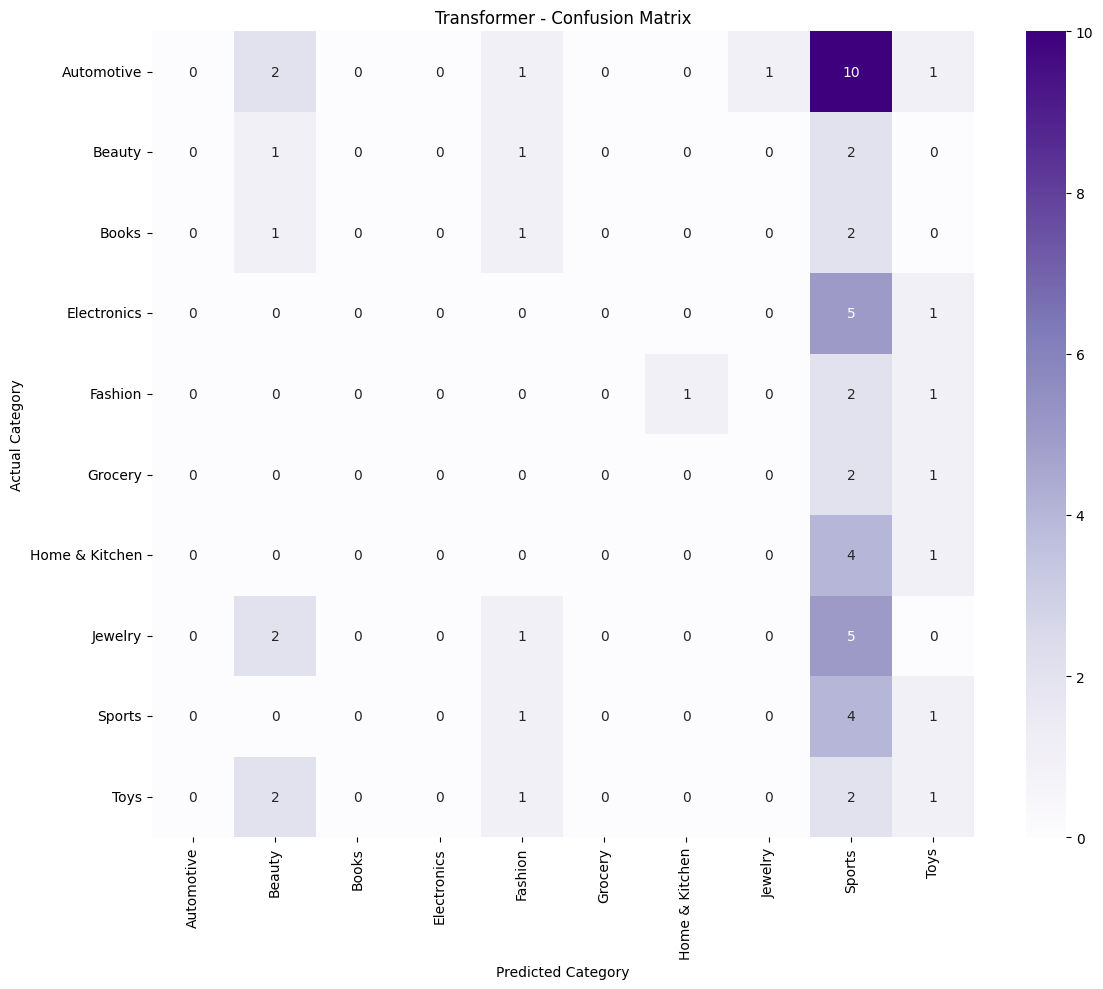

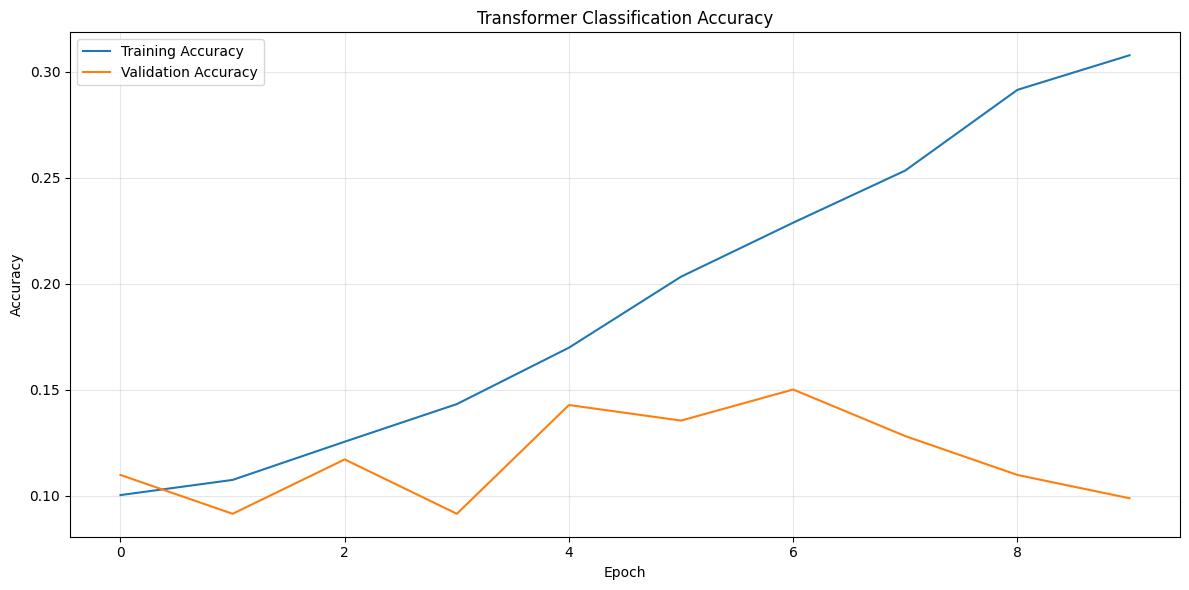

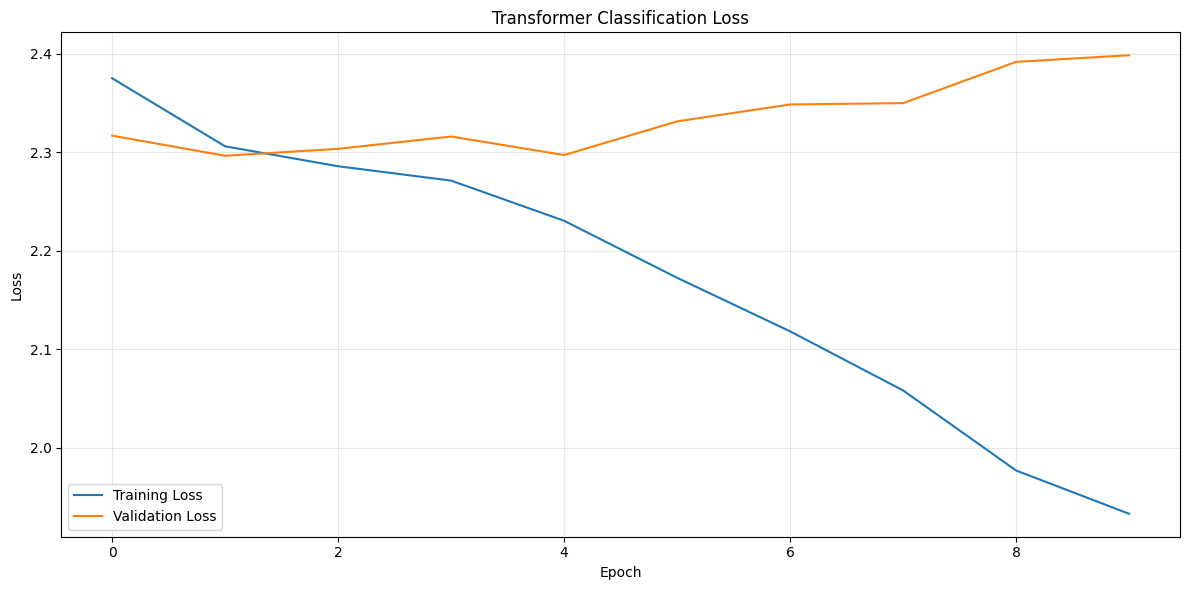



TRANSFORMER REGRESSOR


Model: "Transformer_Regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 10, 5656)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10, 128)        │       724,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_embedding_1          │ (None, 10, 128)        │         1,280 │
│ (PositionalEmbedding)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 10, 128)        │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 10, 128)        │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,006,977 (3.84 MB)

 Trainable params: 1,006,977 (3.84 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 6694029.1071 - mae: 1658.4497
Epoch 1: val_loss improved from None to 6293520.00000, saving model to /content/lstm_transformer_results/models/transformer_regressor_best.keras

Epoch 1: finished saving model to /content/lstm_transformer_results/models/transformer_regressor_best.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - loss: 6869630.5000 - mae: 1665.8284 - val_loss: 6293520.0000 - val_mae: 1653.0553 - learning_rate: 0.0010
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 6639348.4286 - mae: 1641.9118
Epoch 2: val_loss improved from 6293520.00000 to 6235859.50000, saving model to /content/lstm_transformer_results/models/transformer_regressor_best.keras

Epoch 2: finished saving model to /content/lstm_transformer_results/models/transformer_regressor_best.keras
14/14 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - loss: 6817056.0000 - mae: 1650.0420 - val_loss: 6235859.5000 - val_mae: 1635.5220 - learning_rate: 0.0010
Epoch 3/50
14/1

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 615ms/step


Transformer REGRESSION RESULTS
MAE                : 1229.7014
MSE                : 3142484.2170
RMSE               : 1772.7053
R²                 : -0.1064
Explained Variance : -0.1040
Median AE          : 1051.3295
MAPE               : 161.6176%


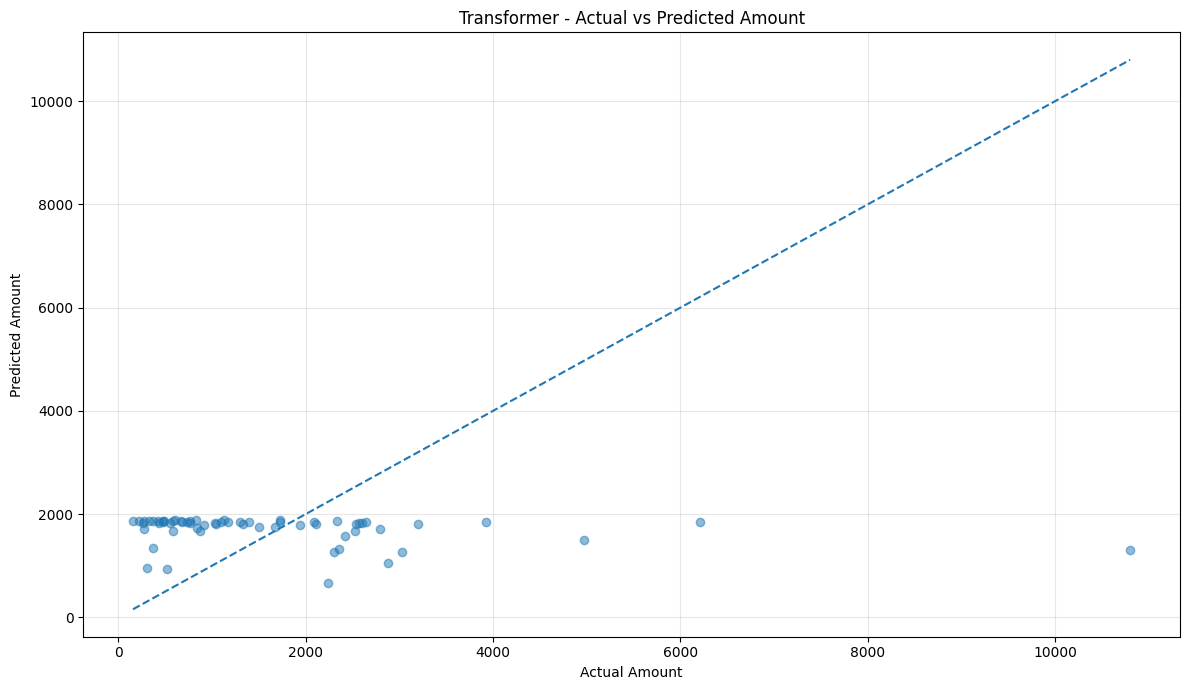

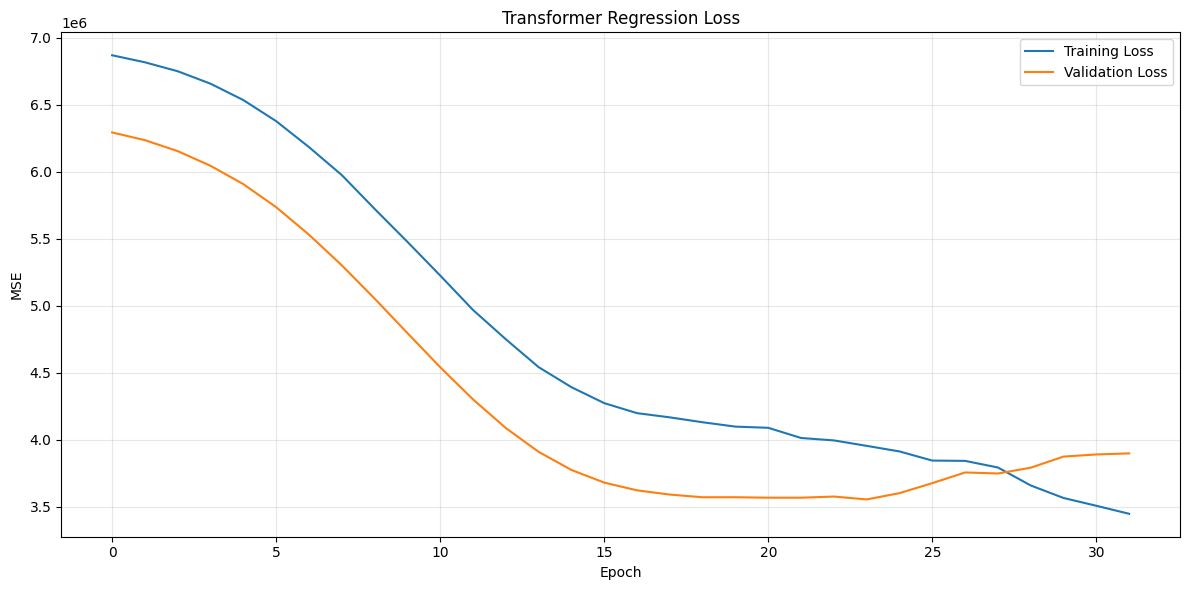

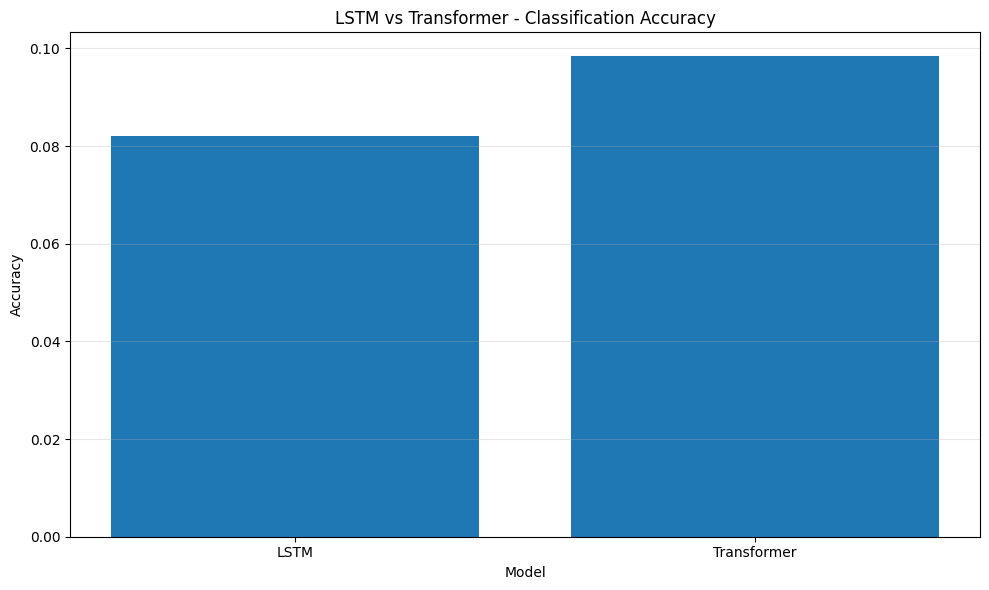

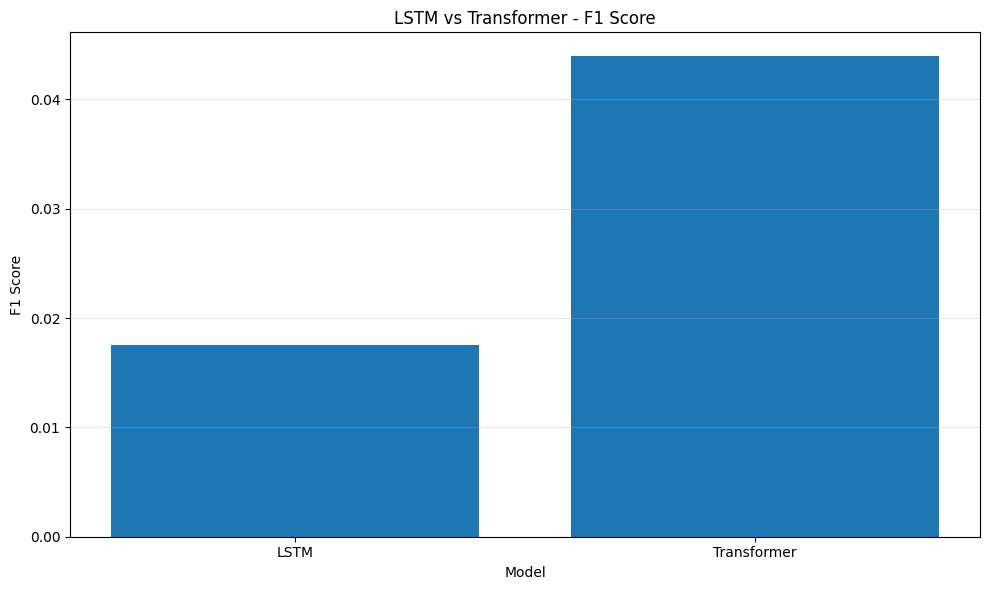

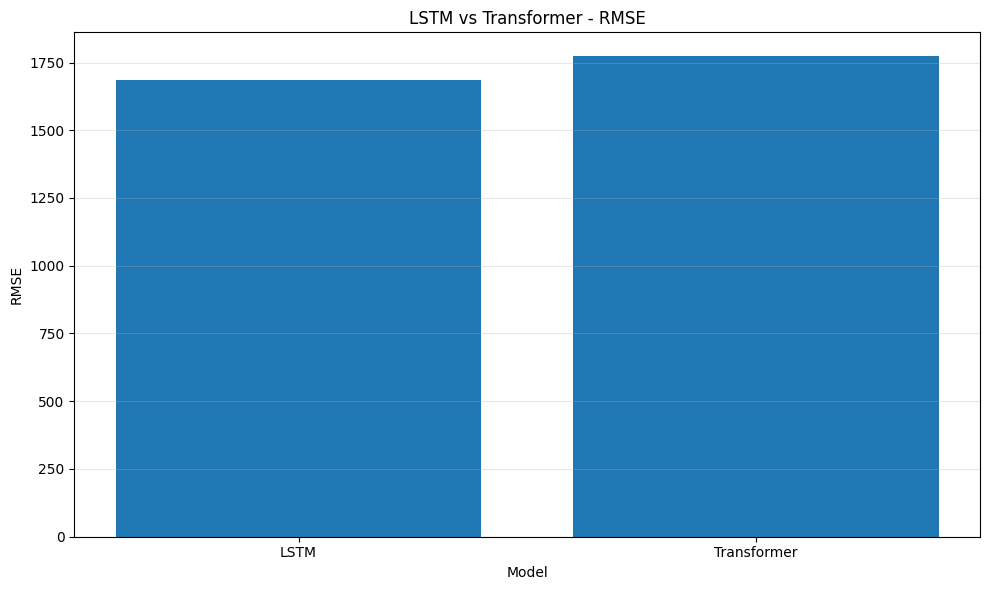

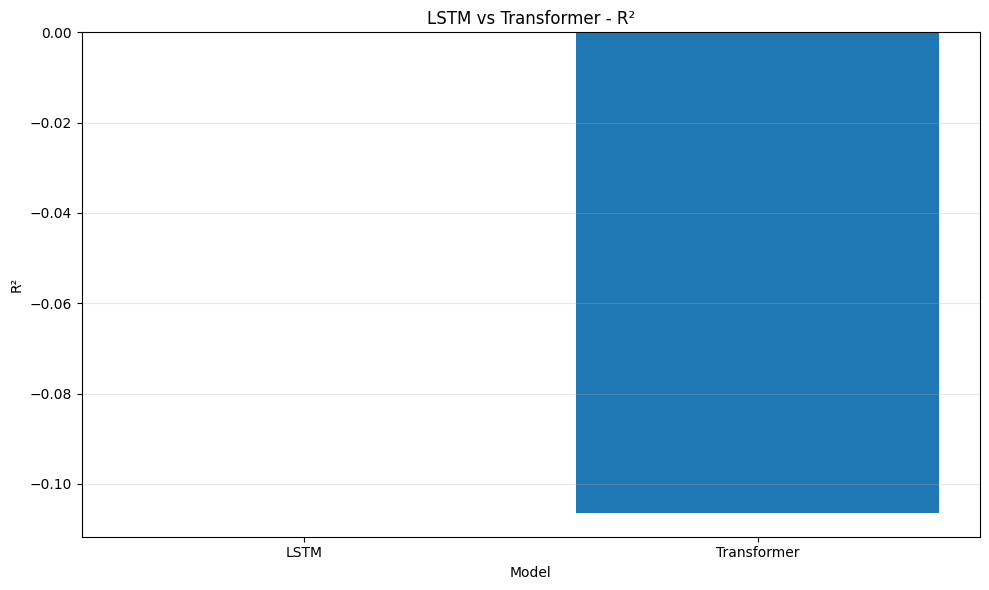



MODEL COMPARISON

Classification:
      Model  Accuracy  Balanced_Accuracy  Precision  Recall   F1   MCC  Cohen_Kappa  ROC_AUC  Log_Loss
       LSTM      0.08               0.08       0.01    0.08 0.02 -0.02        -0.01     0.49      2.36
Transformer      0.10               0.11       0.03    0.10 0.04  0.01         0.01     0.51      2.31

Regression:
      Model      MAE          MSE     RMSE    R2  Explained_Variance  Median_Absolute_Error   MAPE
       LSTM 1,134.13 2,840,640.12 1,685.42 -0.00               -0.00                 957.32 147.99
Transformer 1,229.70 3,142,484.22 1,772.71 -0.11               -0.10               1,051.33 161.62


FINAL ARCHITECTURE SUMMARY

LSTM

Input
  ↓
LSTM(128, return_sequences=True)
  ↓
Dropout(0.30)
  ↓
LSTM(64)
  ↓
Dense(128, ReLU)
  ↓
Dropout(0.30)
  ↓
 ┌───────────────────┬───────────────────┐
 ↓                   ↓
Softmax             Linear
 ↓                   ↓
Category            Amount


TRANSFORMER

Input
  ↓
Dense(128)
  ↓
Positiona

In [92]:
# ============================================================
# 38_39_LSTM_Transformer_Shopping_Prediction.py
# ============================================================
#
# SHOPPING PREDICTION SYSTEM
#
# MODELS:
#   1. LSTM
#   2. Transformer
#
# TASKS:
#   Classification:
#       next_purchase_category
#
#   Regression:
#       next_purchase_amount
#
# INPUT:
#   Previous 10 shopping events per user
#
# OUTPUT:
#   Next purchase category
#   Next purchase amount
#
# ============================================================


# ============================================================
# 1. INSTALL DEPENDENCIES
# ============================================================

import sys
import subprocess
import importlib


def install_if_missing(package, import_name=None):

    if import_name is None:
        import_name = package

    try:
        importlib.import_module(import_name)

    except ImportError:

        print(f"Installing {package}...")

        subprocess.check_call(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "-q",
                package
            ]
        )


install_if_missing("tensorflow", "tensorflow")
install_if_missing("pandas", "pandas")
install_if_missing("numpy", "numpy")
install_if_missing("scikit-learn", "sklearn")
install_if_missing("matplotlib", "matplotlib")
install_if_missing("seaborn", "seaborn")
install_if_missing("joblib", "joblib")


# ============================================================
# 2. IMPORTS
# ============================================================

import os
import random
import warnings

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

import tensorflow as tf

from tensorflow.keras import Model

from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Dropout,
    LayerNormalization,
    MultiHeadAttention,
    GlobalAveragePooling1D,
    Embedding
)

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    LabelEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix,
    classification_report,
    log_loss,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    explained_variance_score,
    median_absolute_error
)


warnings.filterwarnings("ignore")


# ============================================================
# 3. RANDOM SEED
# ============================================================

SEED = 42

np.random.seed(SEED)

random.seed(SEED)

tf.random.set_seed(SEED)


# ============================================================
# 4. PATHS
# ============================================================

BASE_DIR = Path("/content")

DATA_DIR = BASE_DIR / "feature_data"

TRAIN_FILE = DATA_DIR / "train.csv"

VALIDATION_FILE = DATA_DIR / "validation.csv"

TEST_FILE = DATA_DIR / "test.csv"


OUTPUT_DIR = BASE_DIR / "lstm_transformer_results"

GRAPH_DIR = OUTPUT_DIR / "graphs"

MODEL_DIR = OUTPUT_DIR / "models"

METRIC_DIR = OUTPUT_DIR / "metrics"

PREDICTION_DIR = OUTPUT_DIR / "predictions"


for directory in [

    OUTPUT_DIR,
    GRAPH_DIR,
    MODEL_DIR,
    METRIC_DIR,
    PREDICTION_DIR

]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# ============================================================
# 5. PARAMETERS
# ============================================================

SEQUENCE_LENGTH = 10

EPOCHS = 50

BATCH_SIZE = 256

LEARNING_RATE = 0.01

DROPOUT_RATE = 0.30


# LSTM

LSTM_UNITS_1 = 128

LSTM_UNITS_2 = 64


# Transformer

D_MODEL = 128

NUM_HEADS = 4

FF_DIM = 256

TRANSFORMER_LAYERS = 2


CLASSIFICATION_TARGET = (
    "next_purchase_category"
)

REGRESSION_TARGET = (
    "next_purchase_amount"
)


# ============================================================
# 6. HEADER
# ============================================================

print("\n")

print("=" * 90)

print(
    "LSTM + TRANSFORMER SHOPPING PREDICTION SYSTEM"
)

print("=" * 90)

print(
    "TensorFlow:",
    tf.__version__
)


# ============================================================
# 7. LSTM ARCHITECTURE DIAGRAM
# ============================================================

def print_lstm_architecture():

    print("\n")

    print("=" * 90)

    print("LSTM ARCHITECTURE")

    print("=" * 90)

    print(
        """
        Previous 10 Shopping Events
                    │
                    ▼
        ┌──────────────────────────────┐
        │ Input                        │
        │ (10 × Features)              │
        └──────────────┬───────────────┘
                       │
                       ▼
        ┌──────────────────────────────┐
        │ LSTM                         │
        │                              │
        │ Units = 128                  │
        │ return_sequences = True      │
        └──────────────┬───────────────┘
                       │
                       ▼
        ┌──────────────────────────────┐
        │ Dropout                      │
        │ 30%                          │
        └──────────────┬───────────────┘
                       │
                       ▼
        ┌──────────────────────────────┐
        │ LSTM                         │
        │                              │
        │ Units = 64                   │
        │ return_sequences = False     │
        └──────────────┬───────────────┘
                       │
                       ▼
        ┌──────────────────────────────┐
        │ Dense                        │
        │ 128 Units                    │
        │ ReLU                         │
        └──────────────┬───────────────┘
                       │
                       ▼
        ┌──────────────────────────────┐
        │ Dropout 30%                  │
        └──────────────┬───────────────┘
                       │
                 ┌─────┴─────┐
                 │           │
                 ▼           ▼
              Softmax      Linear
                 │           │
                 ▼           ▼
           Category        Amount
        """
    )


print_lstm_architecture()


# ============================================================
# 8. TRANSFORMER ARCHITECTURE DIAGRAM
# ============================================================

def print_transformer_architecture():

    print("\n")

    print("=" * 90)

    print("TRANSFORMER ARCHITECTURE")

    print("=" * 90)

    print(
        """
        Previous 10 Shopping Events
                    │
                    ▼
        ┌──────────────────────────────┐
        │ Input Projection             │
        │ Features → d_model           │
        │ d_model = 128                │
        └──────────────┬───────────────┘
                       │
                       ▼
        ┌──────────────────────────────┐
        │ Positional Embedding         │
        │ Sequence Position Information │
        └──────────────┬───────────────┘
                       │
                       ▼
        ┌──────────────────────────────┐
        │ Multi-Head Self Attention    │
        │                              │
        │ Heads = 4                    │
        └──────────────┬───────────────┘
                       │
                       ▼
        ┌──────────────────────────────┐
        │ Add + Layer Normalization    │
        └──────────────┬───────────────┘
                       │
                       ▼
        ┌──────────────────────────────┐
        │ Feed Forward Network         │
        │                              │
        │ 128 → 256 → 128              │
        └──────────────┬───────────────┘
                       │
                       ▼
        ┌──────────────────────────────┐
        │ Add + Layer Normalization    │
        └──────────────┬───────────────┘
                       │
                       ▼
        ┌──────────────────────────────┐
        │ Global Average Pooling       │
        └──────────────┬───────────────┘
                       │
                       ▼
        ┌──────────────────────────────┐
        │ Dense 128 + ReLU             │
        └──────────────┬───────────────┘
                       │
                 ┌─────┴─────┐
                 │           │
                 ▼           ▼
              Softmax      Linear
                 │           │
                 ▼           ▼
             Category      Amount
        """
    )


print_transformer_architecture()


# ============================================================
# 9. DATA FLOW DIAGRAM
# ============================================================

def print_data_flow():

    print("\n")

    print("=" * 90)

    print("DATA FLOW")

    print("=" * 90)

    print(
        """
        ┌──────────────────────────────┐
        │ Shopping Event Dataset       │
        └──────────────┬───────────────┘
                       │
                       ▼
        ┌──────────────────────────────┐
        │ Train / Validation / Test    │
        └──────────────┬───────────────┘
                       │
                       ▼
        ┌──────────────────────────────┐
        │ Cleaning + Preprocessing     │
        │                              │
        │ Numerical → Scaling          │
        │ Categorical → One Hot        │
        └──────────────┬───────────────┘
                       │
                       ▼
        ┌──────────────────────────────┐
        │ Sort by User + Time          │
        └──────────────┬───────────────┘
                       │
                       ▼
        ┌──────────────────────────────┐
        │ Sliding Window               │
        │                              │
        │ Event 1                      │
        │ Event 2                      │
        │ ...                          │
        │ Event 10                     │
        │      ↓                       │
        │ Predict Event 11             │
        └──────────────┬───────────────┘
                       │
             ┌─────────┴──────────┐
             │                    │
             ▼                    ▼
        ┌───────────┐       ┌────────────┐
        │   LSTM    │       │ Transformer│
        └─────┬─────┘       └──────┬─────┘
              │                    │
              └──────────┬─────────┘
                         │
                  ┌──────┴──────┐
                  ▼             ▼
              Category        Amount
                  │             │
                  ▼             ▼
            Classification   Regression
                  │             │
                  ▼             ▼
               Metrics       Metrics
                  │             │
                  └──────┬──────┘
                         ▼
              Graphs + Models
        """
    )


print_data_flow()


# ============================================================
# 10. CHECK FILES
# ============================================================

print("\n")

print("=" * 90)

print("CHECKING DATA FILES")

print("=" * 90)


for file in [

    TRAIN_FILE,
    VALIDATION_FILE,
    TEST_FILE

]:

    print(
        file,
        "->",
        "FOUND" if file.exists()
        else "NOT FOUND"
    )


if not TRAIN_FILE.exists():

    raise FileNotFoundError(
        TRAIN_FILE
    )


if not VALIDATION_FILE.exists():

    raise FileNotFoundError(
        VALIDATION_FILE
    )


if not TEST_FILE.exists():

    raise FileNotFoundError(
        TEST_FILE
    )


# ============================================================
# 11. LOAD DATA
# ============================================================

train = pd.read_csv(
    TRAIN_FILE
)

validation = pd.read_csv(
    VALIDATION_FILE
)

test = pd.read_csv(
    TEST_FILE
)


print("\n")

print("Train:", train.shape)

print("Validation:", validation.shape)

print("Test:", test.shape)


# ============================================================
# 12. FIND IMPORTANT COLUMNS
# ============================================================

def find_column(df, candidates):

    for column in candidates:

        if column in df.columns:

            return column

    return None


USER_COLUMN = find_column(
    train,
    [
        "user_id",
        "User_ID",
        "userid",
        "customer_id",
        "customerId"
    ]
)


TIME_COLUMN = find_column(
    train,
    [
        "timestamp",
        "event_timestamp",
        "datetime",
        "date",
        "event_time",
        "created_at"
    ]
)


print("\nDetected user column:")

print(USER_COLUMN)


print("\nDetected time column:")

print(TIME_COLUMN)


# ============================================================
# 13. SORT DATA
# ============================================================

if TIME_COLUMN is not None:

    train[TIME_COLUMN] = pd.to_datetime(
        train[TIME_COLUMN],
        errors="coerce"
    )

    validation[TIME_COLUMN] = pd.to_datetime(
        validation[TIME_COLUMN],
        errors="coerce"
    )

    test[TIME_COLUMN] = pd.to_datetime(
        test[TIME_COLUMN],
        errors="coerce"
    )


if USER_COLUMN is not None and TIME_COLUMN is not None:

    train = train.sort_values(
        [
            USER_COLUMN,
            TIME_COLUMN
        ]
    ).reset_index(drop=True)


    validation = validation.sort_values(
        [
            USER_COLUMN,
            TIME_COLUMN
        ]
    ).reset_index(drop=True)


    test = test.sort_values(
        [
            USER_COLUMN,
            TIME_COLUMN
        ]
    ).reset_index(drop=True)


# ============================================================
# 14. REMOVE LEAKAGE
# ============================================================

def get_drop_columns(df):

    drops = []

    for column in df.columns:

        lower = column.lower()

        if column in [

            CLASSIFICATION_TARGET,
            REGRESSION_TARGET

        ]:

            drops.append(column)

            continue


        leakage_words = [

            "future",
            "next_purchase",
            "target_",
            "future_"

        ]


        if any(
            word in lower
            for word in leakage_words
        ):

            drops.append(column)

            continue


        if lower in [

            "event_id",
            "transaction_id"

        ]:

            drops.append(column)


    return list(
        dict.fromkeys(drops)
    )


DROP_COLUMNS = get_drop_columns(
    train
)


print("\nDropped columns:")

for column in DROP_COLUMNS:

    print(
        " -",
        column
    )


# ============================================================
# 15. PREPARE FEATURE DATAFRAMES
# ============================================================

X_train_df = train.drop(
    columns=DROP_COLUMNS,
    errors="ignore"
).copy()


X_validation_df = validation.drop(
    columns=DROP_COLUMNS,
    errors="ignore"
).copy()


X_test_df = test.drop(
    columns=DROP_COLUMNS,
    errors="ignore"
).copy()


# Remove time from features

if TIME_COLUMN is not None:

    for dataframe in [

        X_train_df,
        X_validation_df,
        X_test_df

    ]:

        if TIME_COLUMN in dataframe.columns:

            dataframe.drop(
                columns=[
                    TIME_COLUMN
                ],
                inplace=True
            )


# Remove user ID

if USER_COLUMN is not None:

    for dataframe in [

        X_train_df,
        X_validation_df,
        X_test_df

    ]:

        if USER_COLUMN in dataframe.columns:

            dataframe.drop(
                columns=[
                    USER_COLUMN
                ],
                inplace=True
            )


# ============================================================
# 16. ALIGN COLUMNS
# ============================================================

common_columns = [

    column

    for column in X_train_df.columns

    if column in X_validation_df.columns
    and column in X_test_df.columns

]


X_train_df = X_train_df[
    common_columns
]


X_validation_df = X_validation_df[
    common_columns
]


X_test_df = X_test_df[
    common_columns
]


# ============================================================
# 17. NUMERIC / CATEGORICAL FEATURES
# ============================================================

numeric_columns = (
    X_train_df
    .select_dtypes(
        include=["number"]
    )
    .columns
    .tolist()
)


categorical_columns = (
    X_train_df
    .select_dtypes(
        exclude=["number"]
    )
    .columns
    .tolist()
)


print("\nNumerical features:")

print(
    len(numeric_columns)
)


print("\nCategorical features:")

print(
    len(categorical_columns)
)


# ============================================================
# 18. NUMERICAL PREPROCESSING
# ============================================================

if len(numeric_columns) > 0:

    numeric_imputer = SimpleImputer(
        strategy="median"
    )


    train_numeric = (
        numeric_imputer
        .fit_transform(
            X_train_df[
                numeric_columns
            ]
        )
    )


    validation_numeric = (
        numeric_imputer
        .transform(
            X_validation_df[
                numeric_columns
            ]
        )
    )


    test_numeric = (
        numeric_imputer
        .transform(
            X_test_df[
                numeric_columns
            ]
        )
    )


    scaler = StandardScaler()


    train_numeric = scaler.fit_transform(
        train_numeric
    )


    validation_numeric = scaler.transform(
        validation_numeric
    )


    test_numeric = scaler.transform(
        test_numeric
    )


else:

    train_numeric = np.empty(
        (len(train), 0)
    )

    validation_numeric = np.empty(
        (len(validation), 0)
    )

    test_numeric = np.empty(
        (len(test), 0)
    )

    scaler = None

    numeric_imputer = None


# ============================================================
# 19. CATEGORICAL PREPROCESSING
# ============================================================

if len(categorical_columns) > 0:

    categorical_imputer = SimpleImputer(
        strategy="most_frequent"
    )


    train_cat = (
        categorical_imputer
        .fit_transform(
            X_train_df[
                categorical_columns
            ]
        )
    )


    validation_cat = (
        categorical_imputer
        .transform(
            X_validation_df[
                categorical_columns
            ]
        )
    )


    test_cat = (
        categorical_imputer
        .transform(
            X_test_df[
                categorical_columns
            ]
        )
    )


    encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )


    train_cat = encoder.fit_transform(
        train_cat
    )


    validation_cat = encoder.transform(
        validation_cat
    )


    test_cat = encoder.transform(
        test_cat
    )


else:

    train_cat = np.empty(
        (len(train), 0)
    )

    validation_cat = np.empty(
        (len(validation), 0)
    )

    test_cat = np.empty(
        (len(test), 0)
    )

    categorical_imputer = None

    encoder = None


# ============================================================
# 20. COMBINE FEATURES
# ============================================================

X_train_processed = np.hstack(
    [
        train_numeric,
        train_cat
    ]
).astype(
    np.float32
)


X_validation_processed = np.hstack(
    [
        validation_numeric,
        validation_cat
    ]
).astype(
    np.float32
)


X_test_processed = np.hstack(
    [
        test_numeric,
        test_cat
    ]
).astype(
    np.float32
)


NUM_FEATURES = (
    X_train_processed.shape[1]
)


print("\nProcessed feature shape:")

print(
    X_train_processed.shape
)


print("\nTotal features:")

print(
    NUM_FEATURES
)


# ============================================================
# 21. SAVE PREPROCESSORS
# ============================================================

if scaler is not None:

    joblib.dump(
        scaler,
        MODEL_DIR / "sequence_scaler.pkl"
    )


if numeric_imputer is not None:

    joblib.dump(
        numeric_imputer,
        MODEL_DIR / "numeric_imputer.pkl"
    )


if categorical_imputer is not None:

    joblib.dump(
        categorical_imputer,
        MODEL_DIR / "categorical_imputer.pkl"
    )


if encoder is not None:

    joblib.dump(
        encoder,
        MODEL_DIR / "onehot_encoder.pkl"
    )


# ============================================================
# 22. CREATE SEQUENCES
# ============================================================

def create_sequences(
    processed_features,
    original_df,
    target_column
):

    sequences = []

    targets = []

    metadata = []


    if USER_COLUMN is None:

        groups = [
            (
                "ALL_USERS",
                list(original_df.index)
            )
        ]

    else:

        groups = (
            original_df
            .groupby(
                USER_COLUMN,
                sort=False
            )
            .groups
            .items()
        )


    for user_id, indices in groups:

        indices = list(indices)


        if len(indices) <= SEQUENCE_LENGTH:

            continue


        for position in range(
            SEQUENCE_LENGTH,
            len(indices)
        ):

            previous_indices = indices[
                position - SEQUENCE_LENGTH:
                position
            ]


            target_index = indices[
                position
            ]


            sequence = (
                processed_features[
                    previous_indices
                ]
            )


            target = original_df.loc[
                target_index,
                target_column
            ]


            sequences.append(
                sequence
            )


            targets.append(
                target
            )


            metadata.append(
                {
                    "user_id": user_id,
                    "target_index": target_index
                }
            )


    return (
        np.asarray(
            sequences,
            dtype=np.float32
        ),

        np.asarray(
            targets
        ),

        pd.DataFrame(
            metadata
        )
    )


# ============================================================
# 23. CLASSIFICATION SEQUENCES
# ============================================================

print("\n")

print("=" * 90)

print(
    "CREATING CLASSIFICATION SEQUENCES"
)

print("=" * 90)


X_train_cls, y_train_cls_raw, _ = create_sequences(
    X_train_processed,
    train,
    CLASSIFICATION_TARGET
)


X_validation_cls, y_validation_cls_raw, _ = create_sequences(
    X_validation_processed,
    validation,
    CLASSIFICATION_TARGET
)


X_test_cls, y_test_cls_raw, _ = create_sequences(
    X_test_processed,
    test,
    CLASSIFICATION_TARGET
)


print(
    "Train:",
    X_train_cls.shape
)

print(
    "Validation:",
    X_validation_cls.shape
)

print(
    "Test:",
    X_test_cls.shape
)


# ============================================================
# 24. LABEL ENCODING
# ============================================================

label_encoder = LabelEncoder()


all_labels = pd.concat(
    [
        pd.Series(
            y_train_cls_raw
        ),

        pd.Series(
            y_validation_cls_raw
        ),

        pd.Series(
            y_test_cls_raw
        )
    ]
).astype(str)


label_encoder.fit(
    all_labels
)


y_train_cls = label_encoder.transform(
    y_train_cls_raw.astype(str)
)


y_validation_cls = label_encoder.transform(
    y_validation_cls_raw.astype(str)
)


y_test_cls = label_encoder.transform(
    y_test_cls_raw.astype(str)
)


NUM_CLASSES = len(
    label_encoder.classes_
)


print("\nNumber of classes:")

print(
    NUM_CLASSES
)


print("\nClasses:")

for i, label in enumerate(
    label_encoder.classes_
):

    print(
        i,
        "->",
        label
    )


joblib.dump(
    label_encoder,
    MODEL_DIR / "label_encoder.pkl"
)


# ============================================================
# 25. REGRESSION SEQUENCES
# ============================================================

print("\n")

print("=" * 90)

print(
    "CREATING REGRESSION SEQUENCES"
)

print("=" * 90)


X_train_reg, y_train_reg, _ = create_sequences(
    X_train_processed,
    train,
    REGRESSION_TARGET
)


X_validation_reg, y_validation_reg, _ = create_sequences(
    X_validation_processed,
    validation,
    REGRESSION_TARGET
)


X_test_reg, y_test_reg, _ = create_sequences(
    X_test_processed,
    test,
    REGRESSION_TARGET
)


y_train_reg = pd.to_numeric(
    y_train_reg,
    errors="coerce"
)


y_validation_reg = pd.to_numeric(
    y_validation_reg,
    errors="coerce"
)


y_test_reg = pd.to_numeric(
    y_test_reg,
    errors="coerce"
)


train_mask = np.isfinite(
    y_train_reg
)


validation_mask = np.isfinite(
    y_validation_reg
)


test_mask = np.isfinite(
    y_test_reg
)


X_train_reg = X_train_reg[
    train_mask
]

y_train_reg = y_train_reg[
    train_mask
]


X_validation_reg = X_validation_reg[
    validation_mask
]

y_validation_reg = y_validation_reg[
    validation_mask
]


X_test_reg = X_test_reg[
    test_mask
]

y_test_reg = y_test_reg[
    test_mask
]


print(
    "Train:",
    X_train_reg.shape
)

print(
    "Validation:",
    X_validation_reg.shape
)

print(
    "Test:",
    X_test_reg.shape
)


# ============================================================
# 26. LSTM CLASSIFIER
# ============================================================

def build_lstm_classifier():

    inputs = Input(
        shape=(
            SEQUENCE_LENGTH,
            NUM_FEATURES
        )
    )


    x = LSTM(
        LSTM_UNITS_1,
        return_sequences=True
    )(inputs)


    x = Dropout(
        DROPOUT_RATE
    )(x)


    x = LSTM(
        LSTM_UNITS_2,
        return_sequences=False
    )(x)


    x = Dense(
        128,
        activation="relu"
    )(x)


    x = Dropout(
        DROPOUT_RATE
    )(x)


    outputs = Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)


    model = Model(
        inputs,
        outputs,
        name="LSTM_Classifier"
    )


    model.compile(

        optimizer=Adam(
            learning_rate=LEARNING_RATE
        ),

        loss="sparse_categorical_crossentropy",

        metrics=[
            "accuracy"
        ]
    )


    return model


lstm_classifier = (
    build_lstm_classifier()
)


print("\n")

print("=" * 90)

print("LSTM CLASSIFIER")

print("=" * 90)

lstm_classifier.summary()


# ============================================================
# 27. TRAIN LSTM CLASSIFIER
# ============================================================

lstm_cls_callbacks = [

    ModelCheckpoint(
        MODEL_DIR /
        "lstm_classifier_best.keras",

        monitor="val_loss",

        save_best_only=True,

        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",

        patience=8,

        restore_best_weights=True,

        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",

        factor=0.5,

        patience=3,

        min_lr=1e-6,

        verbose=1
    )
]


lstm_cls_history = (
    lstm_classifier.fit(

        X_train_cls,

        y_train_cls,

        validation_data=(

            X_validation_cls,

            y_validation_cls

        ),

        epochs=EPOCHS,

        batch_size=BATCH_SIZE,

        callbacks=lstm_cls_callbacks,

        verbose=1
    )
)


# ============================================================
# 28. LSTM CLASSIFICATION EVALUATION
# ============================================================

lstm_cls_prob = (
    lstm_classifier.predict(
        X_test_cls,
        batch_size=BATCH_SIZE,
        verbose=1
    )
)


lstm_cls_pred = np.argmax(
    lstm_cls_prob,
    axis=1
)


def classification_metrics(
    y_true,
    y_pred,
    probabilities,
    model_name
):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )


    balanced_accuracy = (
        balanced_accuracy_score(
            y_true,
            y_pred
        )
    )


    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )


    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )


    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )


    mcc = matthews_corrcoef(
        y_true,
        y_pred
    )


    kappa = cohen_kappa_score(
        y_true,
        y_pred
    )


    loss = log_loss(
        y_true,
        probabilities,
        labels=np.arange(
            probabilities.shape[1]
        )
    )


    try:

        roc_auc = roc_auc_score(
            y_true,
            probabilities,
            multi_class="ovr",
            average="weighted"
        )

    except Exception:

        roc_auc = np.nan


    print("\n")

    print("=" * 90)

    print(
        model_name,
        "CLASSIFICATION RESULTS"
    )

    print("=" * 90)


    print(
        f"Accuracy           : {accuracy:.4f}"
    )

    print(
        f"Balanced Accuracy  : {balanced_accuracy:.4f}"
    )

    print(
        f"Precision          : {precision:.4f}"
    )

    print(
        f"Recall             : {recall:.4f}"
    )

    print(
        f"F1                 : {f1:.4f}"
    )

    print(
        f"MCC                : {mcc:.4f}"
    )

    print(
        f"Cohen Kappa        : {kappa:.4f}"
    )

    print(
        f"ROC-AUC            : {roc_auc:.4f}"
    )

    print(
        f"Log Loss           : {loss:.4f}"
    )


    return {

        "Model": model_name,

        "Accuracy": accuracy,

        "Balanced_Accuracy":
            balanced_accuracy,

        "Precision":
            precision,

        "Recall":
            recall,

        "F1":
            f1,

        "MCC":
            mcc,

        "Cohen_Kappa":
            kappa,

        "ROC_AUC":
            roc_auc,

        "Log_Loss":
            loss
    }


lstm_cls_result = classification_metrics(

    y_test_cls,

    lstm_cls_pred,

    lstm_cls_prob,

    "LSTM"
)


# ============================================================
# 29. LSTM CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test_cls,
    lstm_cls_pred
)


plt.figure(
    figsize=(12, 10)
)


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)


plt.title(
    "LSTM - Confusion Matrix"
)


plt.xlabel(
    "Predicted Category"
)


plt.ylabel(
    "Actual Category"
)


plt.tight_layout()


plt.savefig(
    GRAPH_DIR /
    "lstm_confusion_matrix.png",
    dpi=300
)


plt.show()


# ============================================================
# 30. LSTM ACCURACY GRAPH
# ============================================================

plt.figure(
    figsize=(12, 6)
)


plt.plot(
    lstm_cls_history.history[
        "accuracy"
    ],
    label="Training Accuracy"
)


plt.plot(
    lstm_cls_history.history[
        "val_accuracy"
    ],
    label="Validation Accuracy"
)


plt.title(
    "LSTM Classification Accuracy"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Accuracy"
)


plt.legend()


plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.savefig(
    GRAPH_DIR /
    "lstm_classification_accuracy.png",
    dpi=300
)


plt.show()


# ============================================================
# 31. LSTM LOSS GRAPH
# ============================================================

plt.figure(
    figsize=(12, 6)
)


plt.plot(
    lstm_cls_history.history[
        "loss"
    ],
    label="Training Loss"
)


plt.plot(
    lstm_cls_history.history[
        "val_loss"
    ],
    label="Validation Loss"
)


plt.title(
    "LSTM Classification Loss"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Loss"
)


plt.legend()


plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.savefig(
    GRAPH_DIR /
    "lstm_classification_loss.png",
    dpi=300
)


plt.show()


# ============================================================
# 32. LSTM REGRESSOR
# ============================================================

def build_lstm_regressor():

    inputs = Input(
        shape=(
            SEQUENCE_LENGTH,
            NUM_FEATURES
        )
    )


    x = LSTM(
        LSTM_UNITS_1,
        return_sequences=True
    )(inputs)


    x = Dropout(
        DROPOUT_RATE
    )(x)


    x = LSTM(
        LSTM_UNITS_2,
        return_sequences=False
    )(x)


    x = Dense(
        128,
        activation="relu"
    )(x)


    x = Dropout(
        DROPOUT_RATE
    )(x)


    outputs = Dense(
        1,
        activation="linear"
    )(x)


    model = Model(
        inputs,
        outputs,
        name="LSTM_Regressor"
    )


    model.compile(

        optimizer=Adam(
            learning_rate=LEARNING_RATE
        ),

        loss="mse",

        metrics=[
            "mae"
        ]
    )


    return model


lstm_regressor = (
    build_lstm_regressor()
)


print("\n")

print("=" * 90)

print("LSTM REGRESSOR")

print("=" * 90)

lstm_regressor.summary()


# ============================================================
# 33. TRAIN LSTM REGRESSOR
# ============================================================

lstm_reg_callbacks = [

    ModelCheckpoint(
        MODEL_DIR /
        "lstm_regressor_best.keras",

        monitor="val_loss",

        save_best_only=True,

        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",

        patience=8,

        restore_best_weights=True,

        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",

        factor=0.5,

        patience=3,

        min_lr=1e-6,

        verbose=1
    )
]


lstm_reg_history = (
    lstm_regressor.fit(

        X_train_reg,

        y_train_reg,

        validation_data=(

            X_validation_reg,

            y_validation_reg

        ),

        epochs=EPOCHS,

        batch_size=BATCH_SIZE,

        callbacks=lstm_reg_callbacks,

        verbose=1
    )
)


# ============================================================
# 34. REGRESSION METRICS FUNCTION
# ============================================================

def regression_metrics(
    y_true,
    y_pred,
    model_name
):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )


    mse = mean_squared_error(
        y_true,
        y_pred
    )


    rmse = np.sqrt(
        mse
    )


    r2 = r2_score(
        y_true,
        y_pred
    )


    explained_variance = (
        explained_variance_score(
            y_true,
            y_pred
        )
    )


    median_ae = (
        median_absolute_error(
            y_true,
            y_pred
        )
    )


    mask = (
        np.abs(y_true) > 1e-8
    )


    if mask.sum() > 0:

        mape = np.mean(
            np.abs(
                (
                    y_true[mask]
                    -
                    y_pred[mask]
                )
                /
                y_true[mask]
            )
        ) * 100

    else:

        mape = np.nan


    print("\n")

    print("=" * 90)

    print(
        model_name,
        "REGRESSION RESULTS"
    )

    print("=" * 90)


    print(
        f"MAE                : {mae:.4f}"
    )

    print(
        f"MSE                : {mse:.4f}"
    )

    print(
        f"RMSE               : {rmse:.4f}"
    )

    print(
        f"R²                 : {r2:.4f}"
    )

    print(
        f"Explained Variance : {explained_variance:.4f}"
    )

    print(
        f"Median AE          : {median_ae:.4f}"
    )

    print(
        f"MAPE               : {mape:.4f}%"
    )


    return {

        "Model": model_name,

        "MAE": mae,

        "MSE": mse,

        "RMSE": rmse,

        "R2": r2,

        "Explained_Variance":
            explained_variance,

        "Median_Absolute_Error":
            median_ae,

        "MAPE":
            mape
    }


# ============================================================
# 35. LSTM REGRESSION PREDICTION
# ============================================================

lstm_reg_pred = (
    lstm_regressor.predict(
        X_test_reg,
        batch_size=BATCH_SIZE,
        verbose=1
    )
    .reshape(-1)
)


lstm_reg_result = regression_metrics(

    y_test_reg,

    lstm_reg_pred,

    "LSTM"
)


# ============================================================
# 36. LSTM ACTUAL VS PREDICTED
# ============================================================

plot_count = min(
    1000,
    len(y_test_reg)
)


plt.figure(
    figsize=(12, 7)
)


plt.scatter(

    y_test_reg[
        :plot_count
    ],

    lstm_reg_pred[
        :plot_count
    ],

    alpha=0.5
)


min_value = min(

    y_test_reg[
        :plot_count
    ].min(),

    lstm_reg_pred[
        :plot_count
    ].min()

)


max_value = max(

    y_test_reg[
        :plot_count
    ].max(),

    lstm_reg_pred[
        :plot_count
    ].max()

)


plt.plot(

    [
        min_value,
        max_value
    ],

    [
        min_value,
        max_value
    ],

    linestyle="--"
)


plt.title(
    "LSTM - Actual vs Predicted Amount"
)


plt.xlabel(
    "Actual Amount"
)


plt.ylabel(
    "Predicted Amount"
)


plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.savefig(
    GRAPH_DIR /
    "lstm_actual_vs_predicted.png",
    dpi=300
)


plt.show()


# ============================================================
# 37. LSTM REGRESSION LOSS
# ============================================================

plt.figure(
    figsize=(12, 6)
)


plt.plot(
    lstm_reg_history.history[
        "loss"
    ],
    label="Training Loss"
)


plt.plot(
    lstm_reg_history.history[
        "val_loss"
    ],
    label="Validation Loss"
)


plt.title(
    "LSTM Regression Loss"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "MSE"
)


plt.legend()


plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.savefig(
    GRAPH_DIR /
    "lstm_regression_loss.png",
    dpi=300
)


plt.show()


# ============================================================
# 38. TRANSFORMER BLOCK
# ============================================================

class TransformerBlock(tf.keras.layers.Layer):

    def __init__(
        self,
        d_model,
        num_heads,
        ff_dim,
        dropout=0.1
    ):

        super().__init__()


        self.attention = (
            MultiHeadAttention(
                num_heads=num_heads,
                key_dim=d_model // num_heads
            )
        )


        self.ffn = tf.keras.Sequential(
            [
                Dense(
                    ff_dim,
                    activation="relu"
                ),

                Dropout(
                    dropout
                ),

                Dense(
                    d_model
                )
            ]
        )


        self.norm1 = (
            LayerNormalization(
                epsilon=1e-6
            )
        )


        self.norm2 = (
            LayerNormalization(
                epsilon=1e-6
            )
        )


        self.dropout1 = Dropout(
            dropout
        )


        self.dropout2 = Dropout(
            dropout
        )


    def call(
        self,
        inputs,
        training=False
    ):

        attention_output = (
            self.attention(
                inputs,
                inputs,
                training=training
            )
        )


        attention_output = (
            self.dropout1(
                attention_output,
                training=training
            )
        )


        out1 = self.norm1(
            inputs +
            attention_output
        )


        ffn_output = self.ffn(
            out1,
            training=training
        )


        ffn_output = (
            self.dropout2(
                ffn_output,
                training=training
            )
        )


        return self.norm2(
            out1 +
            ffn_output
        )


# ============================================================
# 39. POSITIONAL EMBEDDING
# ============================================================

class PositionalEmbedding(
    tf.keras.layers.Layer
):

    def __init__(
        self,
        sequence_length,
        d_model
    ):

        super().__init__()


        self.position_embedding = (
            Embedding(
                input_dim=sequence_length,
                output_dim=d_model
            )
        )


        self.sequence_length = (
            sequence_length
        )


        self.d_model = d_model


    def call(self, inputs):

        positions = tf.range(
            start=0,
            limit=self.sequence_length,
            delta=1
        )


        embedded_positions = (
            self.position_embedding(
                positions
            )
        )


        return (
            inputs +
            embedded_positions
        )


# ============================================================
# 40. TRANSFORMER CLASSIFIER
# ============================================================

def build_transformer_classifier():

    inputs = Input(
        shape=(
            SEQUENCE_LENGTH,
            NUM_FEATURES
        )
    )


    x = Dense(
        D_MODEL
    )(inputs)


    x = PositionalEmbedding(
        SEQUENCE_LENGTH,
        D_MODEL
    )(x)


    for _ in range(
        TRANSFORMER_LAYERS
    ):

        x = TransformerBlock(
            D_MODEL,
            NUM_HEADS,
            FF_DIM,
            DROPOUT_RATE
        )(x)


    x = GlobalAveragePooling1D()(
        x
    )


    x = Dense(
        128,
        activation="relu"
    )(x)


    x = Dropout(
        DROPOUT_RATE
    )(x)


    outputs = Dense(
        NUM_CLASSES,
        activation="softmax"
    )(x)


    model = Model(
        inputs,
        outputs,
        name="Transformer_Classifier"
    )


    model.compile(

        optimizer=Adam(
            learning_rate=LEARNING_RATE
        ),

        loss="sparse_categorical_crossentropy",

        metrics=[
            "accuracy"
        ]
    )


    return model


transformer_classifier = (
    build_transformer_classifier()
)


print("\n")

print("=" * 90)

print("TRANSFORMER CLASSIFIER")

print("=" * 90)

transformer_classifier.summary()


# ============================================================
# 41. TRAIN TRANSFORMER CLASSIFIER
# ============================================================

transformer_cls_callbacks = [

    ModelCheckpoint(

        MODEL_DIR /
        "transformer_classifier_best.keras",

        monitor="val_loss",

        save_best_only=True,

        verbose=1

    ),

    EarlyStopping(

        monitor="val_loss",

        patience=8,

        restore_best_weights=True,

        verbose=1

    ),

    ReduceLROnPlateau(

        monitor="val_loss",

        factor=0.5,

        patience=3,

        min_lr=1e-6,

        verbose=1

    )
]


transformer_cls_history = (
    transformer_classifier.fit(

        X_train_cls,

        y_train_cls,

        validation_data=(

            X_validation_cls,

            y_validation_cls

        ),

        epochs=EPOCHS,

        batch_size=BATCH_SIZE,

        callbacks=transformer_cls_callbacks,

        verbose=1
    )
)


# ============================================================
# 42. TRANSFORMER CLASSIFICATION EVALUATION
# ============================================================

transformer_cls_prob = (
    transformer_classifier.predict(

        X_test_cls,

        batch_size=BATCH_SIZE,

        verbose=1

    )
)


transformer_cls_pred = np.argmax(
    transformer_cls_prob,
    axis=1
)


transformer_cls_result = (
    classification_metrics(

        y_test_cls,

        transformer_cls_pred,

        transformer_cls_prob,

        "Transformer"

    )
)


# ============================================================
# 43. TRANSFORMER CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(

    y_test_cls,

    transformer_cls_pred

)


plt.figure(
    figsize=(12, 10)
)


sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Purples",

    xticklabels=label_encoder.classes_,

    yticklabels=label_encoder.classes_

)


plt.title(
    "Transformer - Confusion Matrix"
)


plt.xlabel(
    "Predicted Category"
)


plt.ylabel(
    "Actual Category"
)


plt.tight_layout()


plt.savefig(

    GRAPH_DIR /
    "transformer_confusion_matrix.png",

    dpi=300

)


plt.show()


# ============================================================
# 44. TRANSFORMER ACCURACY GRAPH
# ============================================================

plt.figure(
    figsize=(12, 6)
)


plt.plot(

    transformer_cls_history.history[
        "accuracy"
    ],

    label="Training Accuracy"

)


plt.plot(

    transformer_cls_history.history[
        "val_accuracy"
    ],

    label="Validation Accuracy"

)


plt.title(
    "Transformer Classification Accuracy"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Accuracy"
)


plt.legend()


plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.savefig(

    GRAPH_DIR /
    "transformer_classification_accuracy.png",

    dpi=300

)


plt.show()


# ============================================================
# 45. TRANSFORMER LOSS GRAPH
# ============================================================

plt.figure(
    figsize=(12, 6)
)


plt.plot(

    transformer_cls_history.history[
        "loss"
    ],

    label="Training Loss"

)


plt.plot(

    transformer_cls_history.history[
        "val_loss"
    ],

    label="Validation Loss"

)


plt.title(
    "Transformer Classification Loss"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Loss"
)


plt.legend()


plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.savefig(

    GRAPH_DIR /
    "transformer_classification_loss.png",

    dpi=300

)


plt.show()


# ============================================================
# 46. TRANSFORMER REGRESSOR
# ============================================================

def build_transformer_regressor():

    inputs = Input(

        shape=(

            SEQUENCE_LENGTH,

            NUM_FEATURES

        )

    )


    x = Dense(
        D_MODEL
    )(inputs)


    x = PositionalEmbedding(

        SEQUENCE_LENGTH,

        D_MODEL

    )(x)


    for _ in range(
        TRANSFORMER_LAYERS
    ):

        x = TransformerBlock(

            D_MODEL,

            NUM_HEADS,

            FF_DIM,

            DROPOUT_RATE

        )(x)


    x = GlobalAveragePooling1D()(
        x
    )


    x = Dense(
        128,
        activation="relu"
    )(x)


    x = Dropout(
        DROPOUT_RATE
    )(x)


    outputs = Dense(
        1,
        activation="linear"
    )(x)


    model = Model(

        inputs,

        outputs,

        name="Transformer_Regressor"

    )


    model.compile(

        optimizer=Adam(

            learning_rate=LEARNING_RATE

        ),

        loss="mse",

        metrics=[
            "mae"
        ]

    )


    return model


transformer_regressor = (
    build_transformer_regressor()
)


print("\n")

print("=" * 90)

print("TRANSFORMER REGRESSOR")

print("=" * 90)

transformer_regressor.summary()


# ============================================================
# 47. TRAIN TRANSFORMER REGRESSOR
# ============================================================

transformer_reg_callbacks = [

    ModelCheckpoint(

        MODEL_DIR /
        "transformer_regressor_best.keras",

        monitor="val_loss",

        save_best_only=True,

        verbose=1

    ),

    EarlyStopping(

        monitor="val_loss",

        patience=8,

        restore_best_weights=True,

        verbose=1

    ),

    ReduceLROnPlateau(

        monitor="val_loss",

        factor=0.5,

        patience=3,

        min_lr=1e-6,

        verbose=1

    )

]


transformer_reg_history = (
    transformer_regressor.fit(

        X_train_reg,

        y_train_reg,

        validation_data=(

            X_validation_reg,

            y_validation_reg

        ),

        epochs=EPOCHS,

        batch_size=BATCH_SIZE,

        callbacks=transformer_reg_callbacks,

        verbose=1

    )
)


# ============================================================
# 48. TRANSFORMER REGRESSION PREDICTION
# ============================================================

transformer_reg_pred = (

    transformer_regressor.predict(

        X_test_reg,

        batch_size=BATCH_SIZE,

        verbose=1

    )

    .reshape(-1)

)


transformer_reg_result = (
    regression_metrics(

        y_test_reg,

        transformer_reg_pred,

        "Transformer"

    )
)


# ============================================================
# 49. TRANSFORMER ACTUAL VS PREDICTED
# ============================================================

plot_count = min(

    1000,

    len(y_test_reg)

)


plt.figure(
    figsize=(12, 7)
)


plt.scatter(

    y_test_reg[
        :plot_count
    ],

    transformer_reg_pred[
        :plot_count
    ],

    alpha=0.5

)


min_value = min(

    y_test_reg[
        :plot_count
    ].min(),

    transformer_reg_pred[
        :plot_count
    ].min()

)


max_value = max(

    y_test_reg[
        :plot_count
    ].max(),

    transformer_reg_pred[
        :plot_count
    ].max()

)


plt.plot(

    [
        min_value,
        max_value
    ],

    [
        min_value,
        max_value
    ],

    linestyle="--"

)


plt.title(
    "Transformer - Actual vs Predicted Amount"
)


plt.xlabel(
    "Actual Amount"
)


plt.ylabel(
    "Predicted Amount"
)


plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.savefig(

    GRAPH_DIR /
    "transformer_actual_vs_predicted.png",

    dpi=300

)


plt.show()


# ============================================================
# 50. TRANSFORMER REGRESSION LOSS
# ============================================================

plt.figure(
    figsize=(12, 6)
)


plt.plot(

    transformer_reg_history.history[
        "loss"
    ],

    label="Training Loss"

)


plt.plot(

    transformer_reg_history.history[
        "val_loss"
    ],

    label="Validation Loss"

)


plt.title(
    "Transformer Regression Loss"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "MSE"
)


plt.legend()


plt.grid(
    alpha=0.3
)


plt.tight_layout()


plt.savefig(

    GRAPH_DIR /
    "transformer_regression_loss.png",

    dpi=300

)


plt.show()


# ============================================================
# 51. SAVE CLASSIFICATION RESULTS
# ============================================================

classification_results = pd.DataFrame(

    [
        lstm_cls_result,

        transformer_cls_result

    ]

)


classification_results.to_csv(

    METRIC_DIR /
    "lstm_transformer_classification_results.csv",

    index=False

)


# ============================================================
# 52. SAVE REGRESSION RESULTS
# ============================================================

regression_results = pd.DataFrame(

    [
        lstm_reg_result,

        transformer_reg_result

    ]

)


regression_results.to_csv(

    METRIC_DIR /
    "lstm_transformer_regression_results.csv",

    index=False

)


# ============================================================
# 53. CLASSIFICATION COMPARISON GRAPH
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.bar(

    classification_results[
        "Model"
    ],

    classification_results[
        "Accuracy"
    ]

)


plt.title(
    "LSTM vs Transformer - Classification Accuracy"
)


plt.xlabel(
    "Model"
)


plt.ylabel(
    "Accuracy"
)


plt.grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()


plt.savefig(

    GRAPH_DIR /
    "lstm_vs_transformer_accuracy.png",

    dpi=300

)


plt.show()


# ============================================================
# 54. F1 COMPARISON
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.bar(

    classification_results[
        "Model"
    ],

    classification_results[
        "F1"
    ]

)


plt.title(
    "LSTM vs Transformer - F1 Score"
)


plt.xlabel(
    "Model"
)


plt.ylabel(
    "F1 Score"
)


plt.grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()


plt.savefig(

    GRAPH_DIR /
    "lstm_vs_transformer_f1.png",

    dpi=300

)


plt.show()


# ============================================================
# 55. REGRESSION RMSE COMPARISON
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.bar(

    regression_results[
        "Model"
    ],

    regression_results[
        "RMSE"
    ]

)


plt.title(
    "LSTM vs Transformer - RMSE"
)


plt.xlabel(
    "Model"
)


plt.ylabel(
    "RMSE"
)


plt.grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()


plt.savefig(

    GRAPH_DIR /
    "lstm_vs_transformer_rmse.png",

    dpi=300

)


plt.show()


# ============================================================
# 56. REGRESSION R2 COMPARISON
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.bar(

    regression_results[
        "Model"
    ],

    regression_results[
        "R2"
    ]

)


plt.title(
    "LSTM vs Transformer - R²"
)


plt.xlabel(
    "Model"
)


plt.ylabel(
    "R²"
)


plt.grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()


plt.savefig(

    GRAPH_DIR /
    "lstm_vs_transformer_r2.png",

    dpi=300

)


plt.show()


# ============================================================
# 57. SAVE PREDICTIONS
# ============================================================

lstm_classification_predictions = pd.DataFrame(

    {

        "actual_category":
            label_encoder.inverse_transform(
                y_test_cls
            ),

        "predicted_category":
            label_encoder.inverse_transform(
                lstm_cls_pred
            ),

        "confidence":
            np.max(
                lstm_cls_prob,
                axis=1
            )

    }

)


lstm_classification_predictions.to_csv(

    PREDICTION_DIR /
    "lstm_classification_predictions.csv",

    index=False

)


transformer_classification_predictions = pd.DataFrame(

    {

        "actual_category":
            label_encoder.inverse_transform(
                y_test_cls
            ),

        "predicted_category":
            label_encoder.inverse_transform(
                transformer_cls_pred
            ),

        "confidence":
            np.max(
                transformer_cls_prob,
                axis=1
            )

    }

)


transformer_classification_predictions.to_csv(

    PREDICTION_DIR /
    "transformer_classification_predictions.csv",

    index=False

)


lstm_regression_predictions = pd.DataFrame(

    {

        "actual_amount":
            y_test_reg,

        "predicted_amount":
            lstm_reg_pred,

        "absolute_error":
            np.abs(
                y_test_reg -
                lstm_reg_pred
            )

    }

)


lstm_regression_predictions.to_csv(

    PREDICTION_DIR /
    "lstm_regression_predictions.csv",

    index=False

)


transformer_regression_predictions = pd.DataFrame(

    {

        "actual_amount":
            y_test_reg,

        "predicted_amount":
            transformer_reg_pred,

        "absolute_error":
            np.abs(
                y_test_reg -
                transformer_reg_pred
            )

    }

)


transformer_regression_predictions.to_csv(

    PREDICTION_DIR /
    "transformer_regression_predictions.csv",

    index=False

)


# ============================================================
# 58. SAVE MODELS
# ============================================================

lstm_classifier.save(

    MODEL_DIR /
    "lstm_classifier_final.keras"

)


lstm_regressor.save(

    MODEL_DIR /
    "lstm_regressor_final.keras"

)


transformer_classifier.save(

    MODEL_DIR /
    "transformer_classifier_final.keras"

)


transformer_regressor.save(

    MODEL_DIR /
    "transformer_regressor_final.keras"

)


# ============================================================
# 59. PRINT MODEL COMPARISON
# ============================================================

print("\n")

print("=" * 90)

print(
    "MODEL COMPARISON"
)

print("=" * 90)


print("\nClassification:")

print(
    classification_results.to_string(
        index=False
    )
)


print("\nRegression:")

print(
    regression_results.to_string(
        index=False
    )
)


# ============================================================
# 60. FINAL ARCHITECTURE SUMMARY
# ============================================================

print("\n")

print("=" * 90)

print(
    "FINAL ARCHITECTURE SUMMARY"
)

print("=" * 90)


print(
    f"""
LSTM

Input
  ↓
LSTM(128, return_sequences=True)
  ↓
Dropout(0.30)
  ↓
LSTM(64)
  ↓
Dense(128, ReLU)
  ↓
Dropout(0.30)
  ↓
 ┌───────────────────┬───────────────────┐
 ↓                   ↓
Softmax             Linear
 ↓                   ↓
Category            Amount


TRANSFORMER

Input
  ↓
Dense({D_MODEL})
  ↓
Positional Embedding
  ↓
Transformer Block × {TRANSFORMER_LAYERS}
  │
  ├── Multi-Head Attention
  │
  ├── Add + LayerNorm
  │
  ├── Feed Forward
  │
  └── Add + LayerNorm
  ↓
Global Average Pooling
  ↓
Dense(128, ReLU)
  ↓
Dropout(0.30)
  ↓
 ┌───────────────────┬───────────────────┐
 ↓                   ↓
Softmax             Linear
 ↓                   ↓
Category            Amount
"""
)


# ============================================================
# 61. OUTPUT FILES
# ============================================================

print("\n")

print("=" * 90)

print(
    "OUTPUT FILES"
)

print("=" * 90)


print("\nGraphs:")

for file in sorted(
    GRAPH_DIR.glob("*")
):

    print(
        " -",
        file
    )


print("\nModels:")

for file in sorted(
    MODEL_DIR.glob("*")
):

    print(
        " -",
        file
    )


print("\nMetrics:")

for file in sorted(
    METRIC_DIR.glob("*")
):

    print(
        " -",
        file
    )


print("\nPredictions:")

for file in sorted(
    PREDICTION_DIR.glob("*")
):

    print(
        " -",
        file
    )


# ============================================================
# 62. COMPLETED
# ============================================================

print("\n")

print("=" * 90)

print(
    "LSTM + TRANSFORMER TRAINING COMPLETED"
)

print("=" * 90)


print("\nResults saved to:")

print(
    OUTPUT_DIR
)

#PREDICTIONS



TOP-5 NEXT PURCHASE PREDICTIONS USING LSTM
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step

First 20 Top-5 predictions:
actual_category top_1_category  top_1_probability top_2_category  top_2_probability top_3_category  top_3_probability top_4_category  top_4_probability top_5_category  top_5_probability
        Fashion         Sports               0.13         Beauty               0.12        Jewelry               0.12        Fashion               0.10           Toys               0.10
     Automotive         Sports               0.13        Jewelry               0.12         Beauty               0.12        Fashion               0.10           Toys               0.10
     Automotive         Sports               0.13         Beauty               0.13        Jewelry               0.12        Fashion               0.10           Toys               0.10
         Beauty         Sports               0.13         Beauty               0.13        Jewelry               0.12        Fashion           

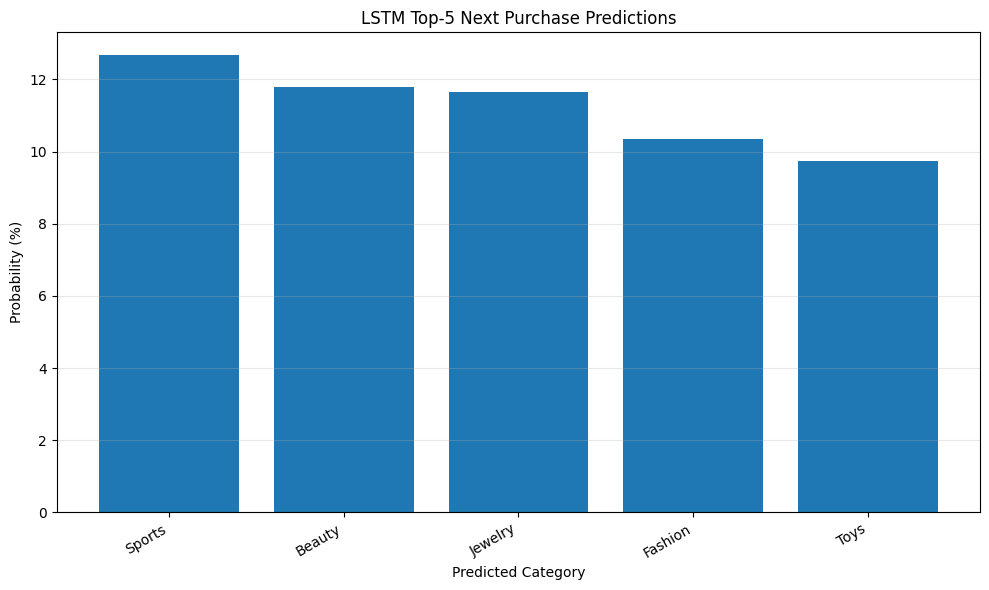



TOP-5 PREDICTION FILE
/content/lstm_transformer_results/predictions/lstm_top5_predictions.csv


In [93]:
# ============================================================
# TOP-5 NEXT PURCHASE PREDICTIONS USING LSTM
# ============================================================

print("\n")
print("=" * 90)
print("TOP-5 NEXT PURCHASE PREDICTIONS USING LSTM")
print("=" * 90)


# ------------------------------------------------------------
# 1. Generate probability predictions
# ------------------------------------------------------------

lstm_top5_probabilities = lstm_classifier.predict(
    X_test_cls,
    batch_size=BATCH_SIZE,
    verbose=1
)


# ------------------------------------------------------------
# 2. Get top-5 class indices
# ------------------------------------------------------------

top_k = min(
    5,
    lstm_top5_probabilities.shape[1]
)


top5_indices = np.argsort(
    lstm_top5_probabilities,
    axis=1
)[:, -top_k:]


# Reverse so highest probability comes first

top5_indices = np.flip(
    top5_indices,
    axis=1
)


# ------------------------------------------------------------
# 3. Create Top-5 prediction dataframe
# ------------------------------------------------------------

top5_results = pd.DataFrame()


# Actual category

top5_results["actual_category"] = (
    label_encoder.inverse_transform(
        y_test_cls
    )
)


for rank in range(top_k):

    class_indices = top5_indices[:, rank]

    probabilities = (
        lstm_top5_probabilities[
            np.arange(
                len(lstm_top5_probabilities)
            ),
            class_indices
        ]
    )


    categories = (
        label_encoder.inverse_transform(
            class_indices
        )
    )


    top5_results[
        f"top_{rank + 1}_category"
    ] = categories


    top5_results[
        f"top_{rank + 1}_probability"
    ] = probabilities


# ------------------------------------------------------------
# 4. Save Top-5 predictions
# ------------------------------------------------------------

top5_file = (
    PREDICTION_DIR /
    "lstm_top5_predictions.csv"
)


top5_results.to_csv(
    top5_file,
    index=False
)


# ------------------------------------------------------------
# 5. Display first 20 predictions
# ------------------------------------------------------------

print("\nFirst 20 Top-5 predictions:")

print(
    top5_results.head(20).to_string(
        index=False
    )
)


# ============================================================
# TOP-5 ACCURACY
# ============================================================

print("\n")
print("=" * 90)
print("TOP-K ACCURACY")
print("=" * 90)


actual_labels = y_test_cls


for k in range(
    1,
    top_k + 1
):

    top_k_predictions = (
        top5_indices[:, :k]
    )


    correct = np.array(
        [
            actual_labels[i]
            in top_k_predictions[i]

            for i in range(
                len(actual_labels)
            )
        ]
    )


    top_k_accuracy = (
        correct.mean()
    )


    print(
        f"Top-{k} Accuracy : "
        f"{top_k_accuracy:.4f} "
        f"({top_k_accuracy * 100:.2f}%)"
    )


# ============================================================
# TOP-5 EXAMPLE FOR ONE USER
# ============================================================

print("\n")
print("=" * 90)
print("EXAMPLE TOP-5 PREDICTION")
print("=" * 90)


example_index = 0


print(
    "\nActual next purchase category:"
)


print(
    top5_results.loc[
        example_index,
        "actual_category"
    ]
)


print("\nLSTM predictions:")


for rank in range(top_k):

    category = top5_results.loc[
        example_index,
        f"top_{rank + 1}_category"
    ]


    probability = top5_results.loc[
        example_index,
        f"top_{rank + 1}_probability"
    ]


    print(
        f"{rank + 1}. "
        f"{category:<30} "
        f"{probability * 100:.2f}%"
    )


# ============================================================
# TOP-5 PROBABILITY GRAPH
# ============================================================

example_probabilities = []

example_categories = []


for rank in range(top_k):

    example_categories.append(
        top5_results.loc[
            example_index,
            f"top_{rank + 1}_category"
        ]
    )


    example_probabilities.append(
        top5_results.loc[
            example_index,
            f"top_{rank + 1}_probability"
        ] * 100
    )


plt.figure(
    figsize=(10, 6)
)


plt.bar(
    example_categories,
    example_probabilities
)


plt.title(
    "LSTM Top-5 Next Purchase Predictions"
)


plt.xlabel(
    "Predicted Category"
)


plt.ylabel(
    "Probability (%)"
)


plt.xticks(
    rotation=30,
    ha="right"
)


plt.grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()


plt.savefig(
    GRAPH_DIR /
    "lstm_top5_prediction_example.png",
    dpi=300
)


plt.show()


# ============================================================
# TOP-5 SUMMARY
# ============================================================

print("\n")
print("=" * 90)
print("TOP-5 PREDICTION FILE")
print("=" * 90)

print(
    top5_file
)